In [1]:
from utils import *
from genData import *
from model.unet_leaky_norm_tanho import UNet
import time 
np.random.seed(111)
torch.manual_seed(111)

det = 'H1L1'
f0 = 500
size = (512, 64)
Tsft = 14400

max_train_levels = [0, 9, 12, 15, 17, 18, 19, 20, 21, 22, 28, 35, 40, 50, 60]


filename = '/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{0}Hz_H1L1_D0-{4}_{1}x{2}_{3}s_4c_traindata_n{5}_seed0_2323.npz'.format(f0, size[0], size[1], Tsft, 35, 400)
targets = np.load(filename, allow_pickle=True)['clean_image']
masks = np.load(filename, allow_pickle=True)['signal_mask']

data = []
mask_data = []
target_data = []
label_data = []
for Sn in max_train_levels:
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)

    data.append(normalize(noise + targets))
    mask_data.append(masks)
    target_data.append(normalize(targets))
    labels = [Sn] * noise.shape[0]  # Extend labels
    label_data.append(labels)
        
data = np.concatenate(data)
mask_data = np.concatenate(mask_data)
target_data = np.concatenate(target_data)
label_data = np.concatenate(label_data)
data = load_signal_datasetv2(data, target_data, mask_data, label_data)
    
    
noise = np.empty((400,) + size + (4,))
for i in range(noise.shape[0]):
    noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise = normalize(noise)
noise_data = load_noise_dataset(noise)

val_loader = make_data_loader([data, noise_data], batch_size=8, shuffle=False)


25-06-13 00:12:14.858 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [1]:
import numpy as np
nSample = 1000
f1min = -1e-10
f1max = 0
f0min = 500
f0max = 500

f0_arr = np.random.uniform(f0min, f0max, nSample)
f1_arr = np.random.uniform(f1min, f1max, nSample)
phi_arr = np.random.uniform(0, 2*np.pi, nSample)
psi_arr = np.random.uniform(0, np.pi, nSample)
cosi_arr = np.random.uniform(-1, 1, nSample)

alpha_arr = np.random.uniform(0, 2*np.pi, nSample)
sinDelta = np.random.uniform(-1 , 1, nSample)
delta_arr = np.arcsin(sinDelta)

params = np.column_stack((f0_arr, f1_arr, phi_arr, psi_arr, cosi_arr, alpha_arr, delta_arr))


In [3]:
for i, (a,b,c,d,e,f,g) in enumerate(params):
    print(a,b,c,d,e,f,g)

500.0 -8.340317191545498e-11 0.7580003349221317 1.6795405368802607 0.7839341106709978 3.2920381185298453 -0.33969910100709977
500.0 -7.331616549632919e-12 5.148579572892633 3.0677476044726433 0.21507610721748627 4.7288619120102515 -1.0566440196277322
500.0 -6.608302347475875e-11 6.038798096194626 1.762745519437077 0.7781805969266089 4.488883062771671 0.12368029373140747
500.0 -2.6110887787601018e-11 2.864661760205425 0.6187735693252684 -0.6764921023387869 1.5817299497938058 -0.7387829205429435
500.0 -6.075474587183603e-11 0.15987885043409303 1.5136645689662742 -0.5423988265283333 4.264738018721101 -0.5865639062847942
500.0 -7.443017859624861e-11 5.88573543260191 0.6618292799425615 -0.07212522576415048 1.6926967534217727 -0.5051007727060839
500.0 -1.5556263172318036e-11 3.367256411136577 2.8715777019712614 -0.39297029793466387 0.4059803245605053 -1.2367984307244666
500.0 -7.490419302201781e-11 5.028915807812178 0.660953355987353 0.20156205801016536 0.01454603364194457 -0.834659104104491

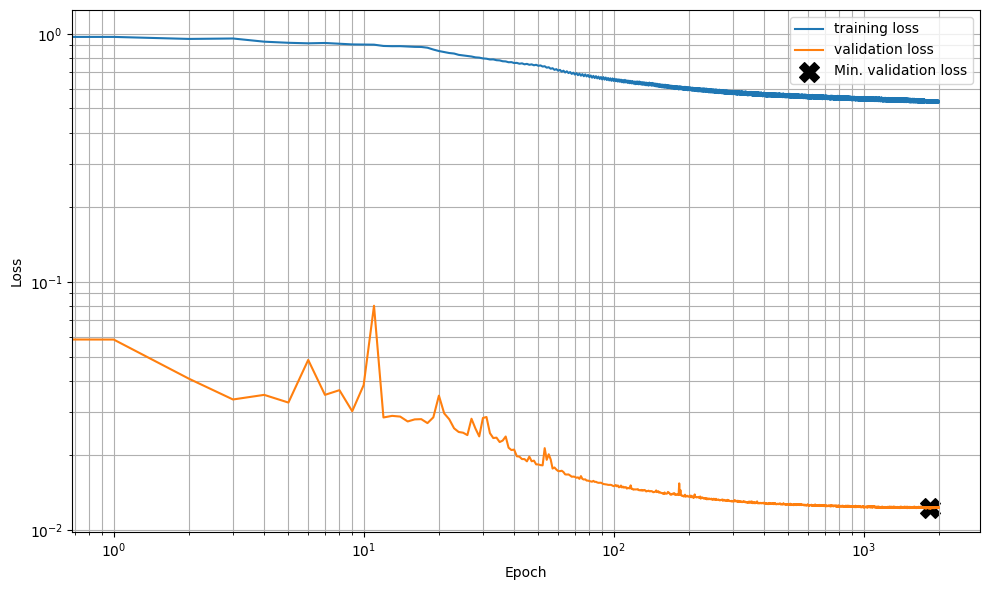

In [2]:
import numpy as np
from model.unet_leaky_norm_tanho_classification import UNet
import matplotlib.pyplot as plt

version = 'H1L1_fast_UNET_weight_alpha1.0beta1.0_500Hz_D22-22_T10_Tsft14400_ndata5_step2_ndata5000_th50_512x64_MSELoss_dropout0'
data = np.load('/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/{}Hz/losses_{}.npy'.format(f0, version), allow_pickle=True)

train_losses = data.item()['train_losses']
val_losses = data.item()['val_losses']
top_val_loss = data.item()['top_val_losses']

train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

plt.figure(figsize=(10, 6))
plt.plot(train_losses[5:]/train_losses[5:].max(), label='training loss')
plt.plot(val_losses/val_losses.max(), label='validation loss')
idx = np.argmin(val_losses-top_val_loss)
plt.scatter(idx, top_val_loss/val_losses.max(), color='k', marker='X', label='Min. validation loss', s=200)

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.minorticks_on()
plt.grid(which='both')
plt.tight_layout()
#plt.savefig('./plots/loss_{}.pdf'.format(version))
#plt.savefig('./plots/loss_{}.png'.format(version))
plt.show()


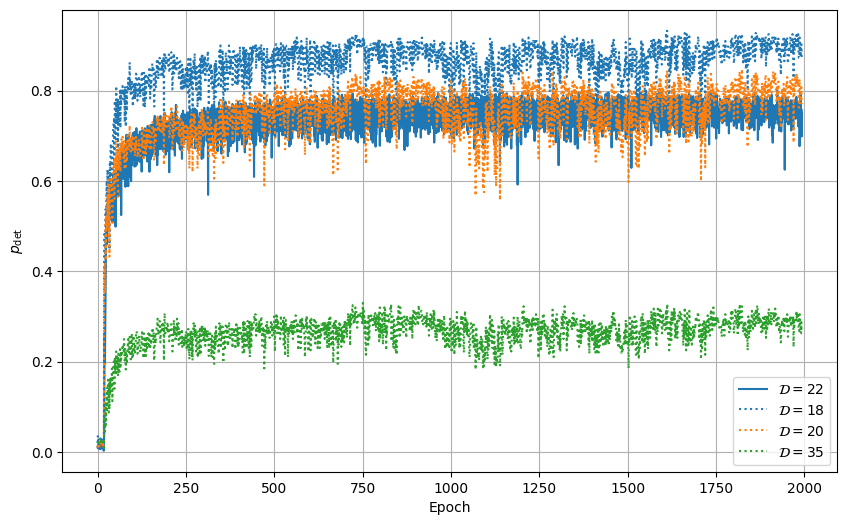

In [3]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
plt.figure(figsize=(10, 6))

for i, key in enumerate([22]):
    plt.plot(train_pdet[key][5:], label=r'$\mathcal{D}=$'+str(key), color=colors[i])

for i, key in enumerate([18, 20, 35]):
    plt.plot(val_pdet[key][5:], ls='dotted', label=r'$\mathcal{D}=$'+str(key), color=colors[i])
    
plt.legend()
plt.xlabel('Epoch')
plt.ylabel(r'$p_\mathrm{det}$')
plt.legend()
plt.grid()
#plt.savefig('./plots/pdet_train_{}.pdf'.format(version))
#plt.savefig('./plots/pdet_train_{}.png'.format(version))

#plt.yscale('log')

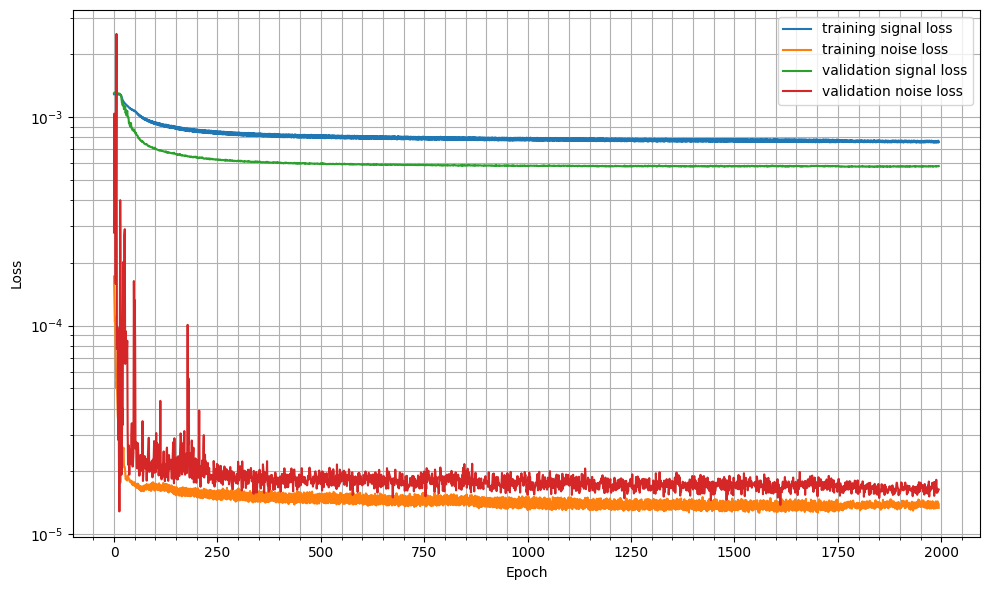

In [4]:
a = data.item()['train_mse_signal']
b = data.item()['train_mse_noise']

plt.figure(figsize=(10, 6))
plt.plot(a[5:], label='training signal loss')
plt.plot(b[5:], label='training noise loss')

# plt.yscale('log')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.minorticks_on()
# plt.grid(which='both')
# plt.tight_layout()
# plt.show()

a = data.item()['val_mse_signal']
b = data.item()['val_mse_noise']

#plt.figure(figsize=(10, 6))
plt.plot(a[5:], label='validation signal loss')
plt.plot(b[5:], label='validation noise loss')

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
#plt.title('Loss Curve')
#plt.ylim(0, 0.55)
plt.minorticks_on()
plt.grid(which='both')
plt.tight_layout()
#plt.savefig('./plots/loss_{}.pdf'.format(version))
#plt.savefig('./plots/loss_{}.png'.format(version))

plt.show()

In [5]:
from model.unet_leaky_norm_tanho import UNet
import matplotlib.pyplot as plt
model = UNet(input_channels=4, output_channels=4).to(device)

best_val_model = torch.load("./trained_model/500Hz/best_val_model_{}.pth".format(version), weights_only=False)
#best_val_model = torch.load('../unet_dyn_fastnoise/trained_model/best_pdet_model_H1L1_D20-35_256x128_7200s_n1000_MSELoss_lnN5256D203510dayn1000Tsft7200.pth', weights_only=False)
model.load_state_dict(best_val_model)

model.eval()  # Set model to evaluation mode
model.to(device)

inputs = [] 
predictions = []
ground_truth = []
masks = []
labels = []
stats = []


with torch.no_grad():  # No gradient computation needed during evaluation
    for test_batch in tqdm(val_loader):
        test_images, test_targets, test_masks, test_labels = test_batch

        # Move data to the specified device
        test_images = test_images.to(device)
        test_targets = test_targets.to(device)
        test_masks = test_masks.to(device)
        test_labels = test_labels.to(device)

        # Forward pass
        outputs = model(test_images)
        #outputs = model(outputs)
        # Collect results
        inputs.append(test_images.cpu().numpy())
        predictions.append(outputs.cpu().numpy())
        ground_truth.append(test_targets.cpu().numpy())
        masks.append(test_masks.cpu().numpy())
        labels.append(test_labels.cpu().numpy())
        #stats.append(stat.cpu().numpy())


inputs = np.concatenate(inputs, axis=0)
predictions = np.concatenate(predictions, axis=0)
ground_truth = np.concatenate(ground_truth, axis=0)
masks = np.concatenate(masks, axis=0)
labels = np.concatenate(labels, axis=0)
#stats = np.concatenate(stats, axis=0)

100%|██████████| 800/800 [00:13<00:00, 58.18it/s]


In [6]:
ref_one = np.ones_like(predictions[0][0,:,:]) 
#ref_one = np.random.rand(256,128)

results_dict = {}

def compute_detection_statistic(images, ref_distribution=None):
    """
    Compute the KL divergence detection statistic for each image.

    Parameters:
        images (torch.Tensor): Input images, shape (batch_size, C, H, W).
        ref_distribution (np.ndarray): Reference distribution Q for KL divergence, 
                                        shape (H, W).

    Returns:
        np.ndarray: KL divergence statistics for each image.
    """
    detection_stats = np.mean(np.abs(images.transpose(0, 2, 3, 1)), axis=(1, 2, 3))
    #detection_stats = np.mean(np.abs(images.transpose(0, 2, 3, 1)), axis=(1, 2))
    return detection_stats

unique_labels = np.unique(labels)  # Find unique labels in the dataset
for label in tqdm(unique_labels):
    indices = np.where(labels == label)[0]
    
    results_dict[label] = compute_detection_statistic(predictions[indices])


100%|██████████| 16/16 [00:01<00:00, 10.48it/s]


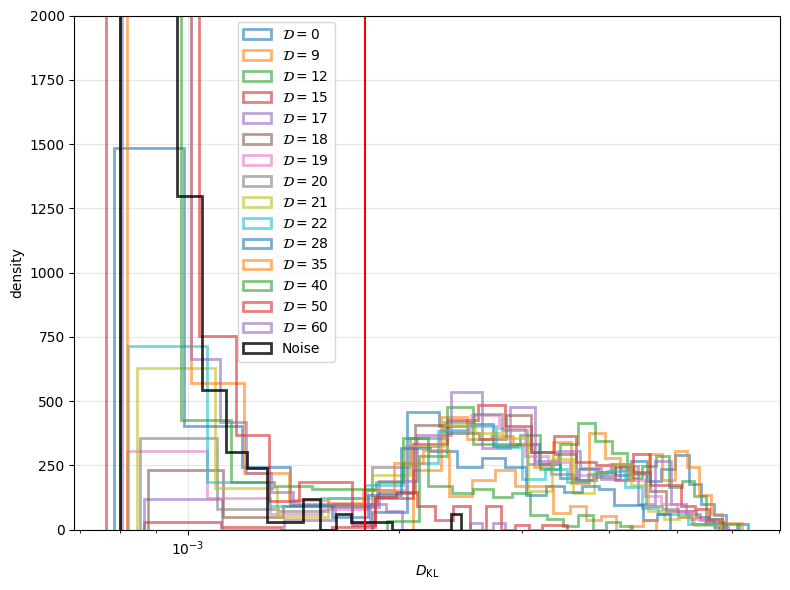

In [7]:
#x_pfa = np.zeros(4)
plt.figure(figsize=(8, 6))
    # Plot histograms
for label, x_values in results_dict.items():
    if label != np.inf:

        plt.hist(x_values, label=r'$\mathcal{D}=$'+str(int(label)), bins=int(np.sqrt(x_values.size)), alpha=0.6, histtype='step', linewidth=2, density=True)
    else:    
        plt.hist(x_values, label="Noise", alpha=0.8, histtype='step', bins=int(np.sqrt(x_values.size)), linewidth=2, color='k', density=True)
        x_pfa = np.percentile(x_values, (1-1./100)*100)
        #plt.hist(mask_dict, label="Mask", alpha=0.8, histtype='step', bins=int(np.sqrt(mask_dict.size)), linewidth=2, density=True, color='r')

plt.vlines(x=x_pfa, ymin=0, ymax=1e5, color='r')
# Add labels and legend
plt.xlabel(r'$D_\mathrm{KL}$')
plt.ylabel('density')
plt.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.3, 1))
plt.grid(alpha=0.3)
plt.ylim(0, 2000)
#plt.xlim(0.0003, 0.002)
plt.xscale('log')

plt.tight_layout()

#plt.savefig('./plots/DKL_{}_channel{}.pdf'.format(version, j))
#plt.savefig('./plots/DKL_{}_channel{}.png'.format(version, j))
plt.show()

In [8]:
from plot import *

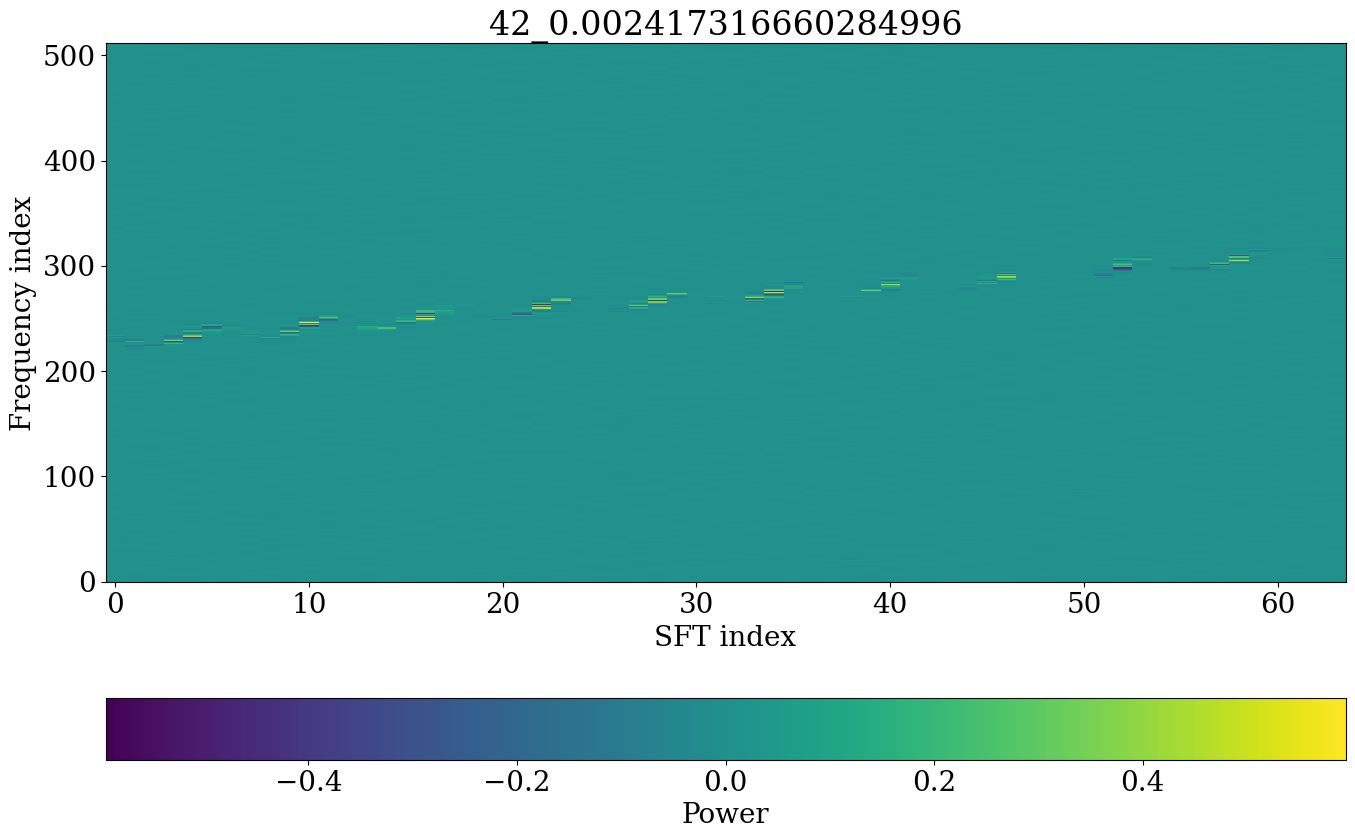

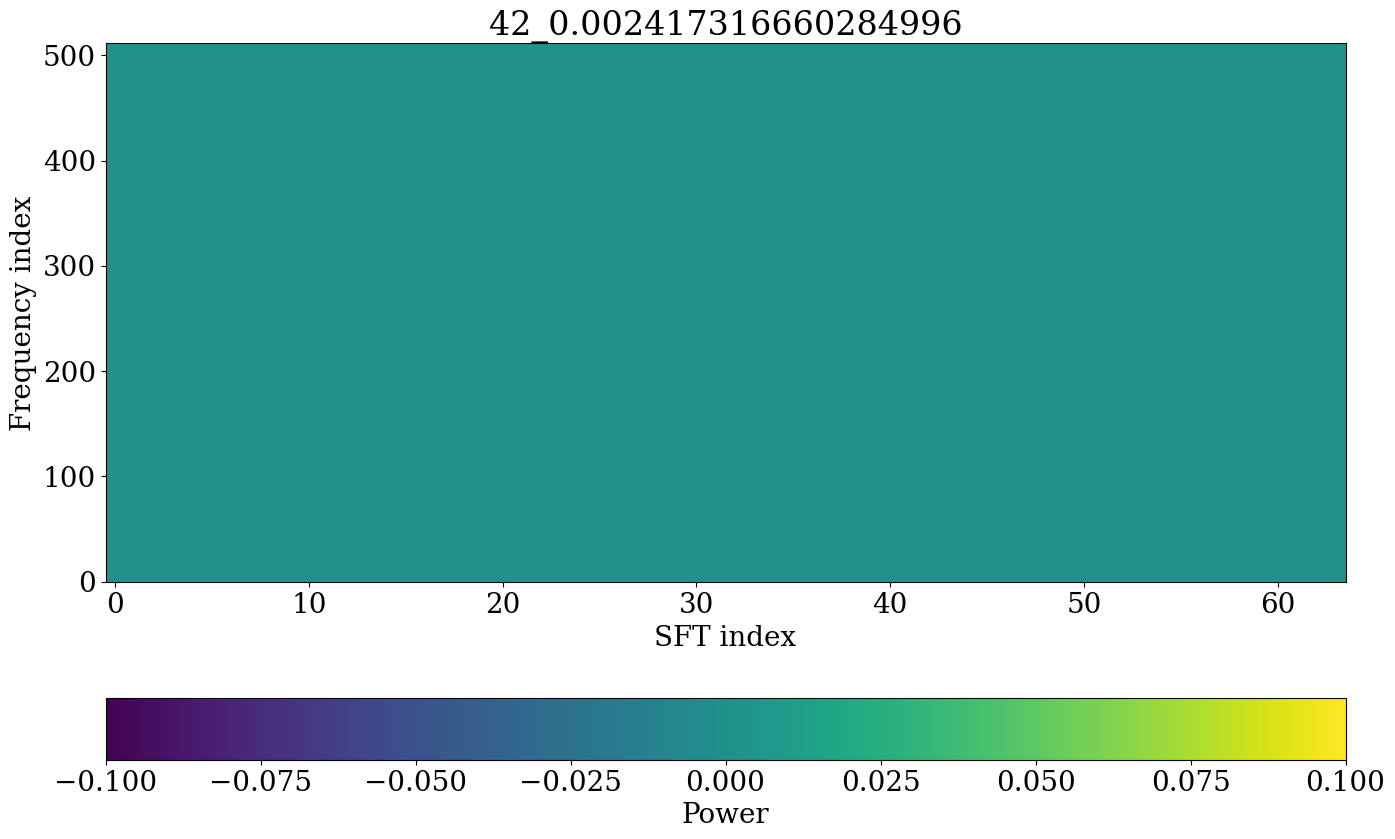

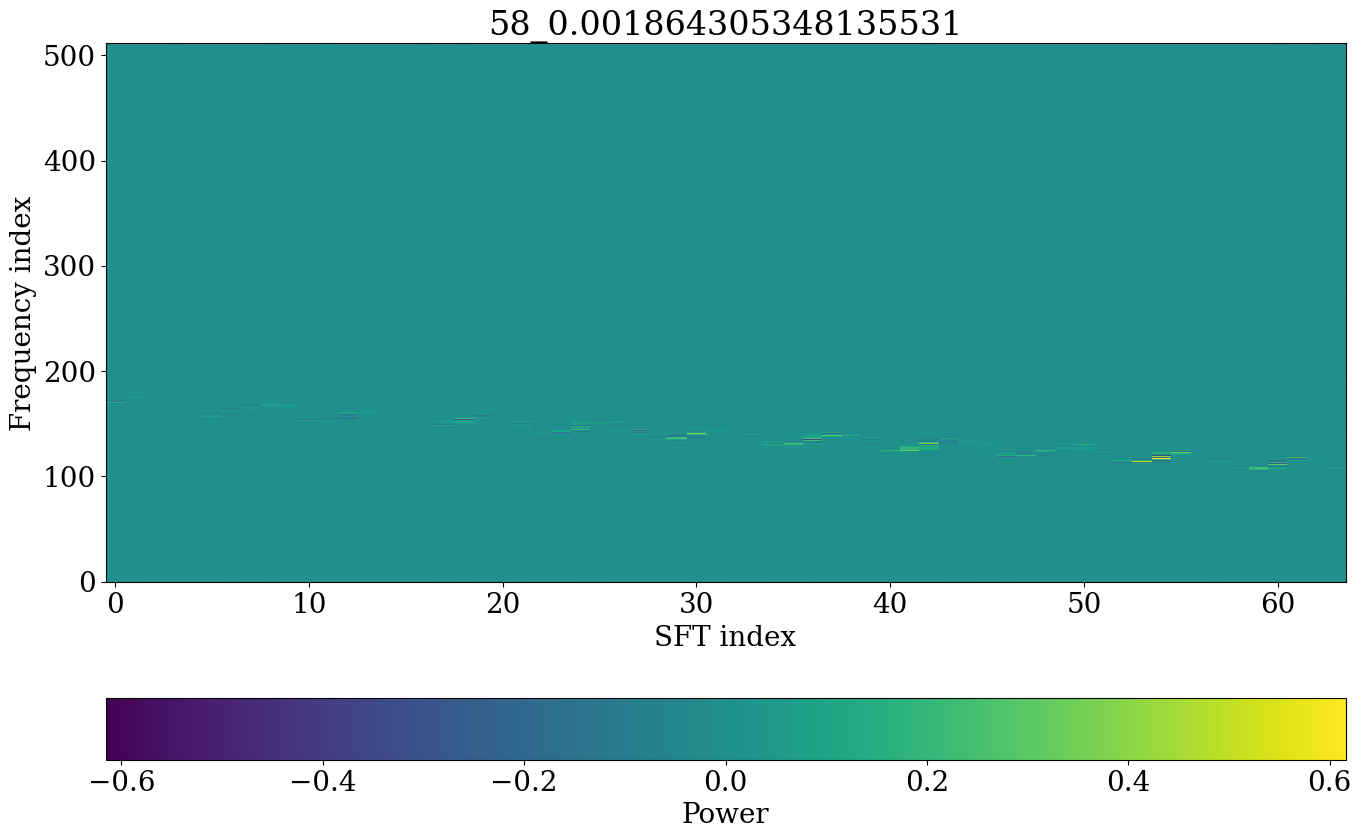

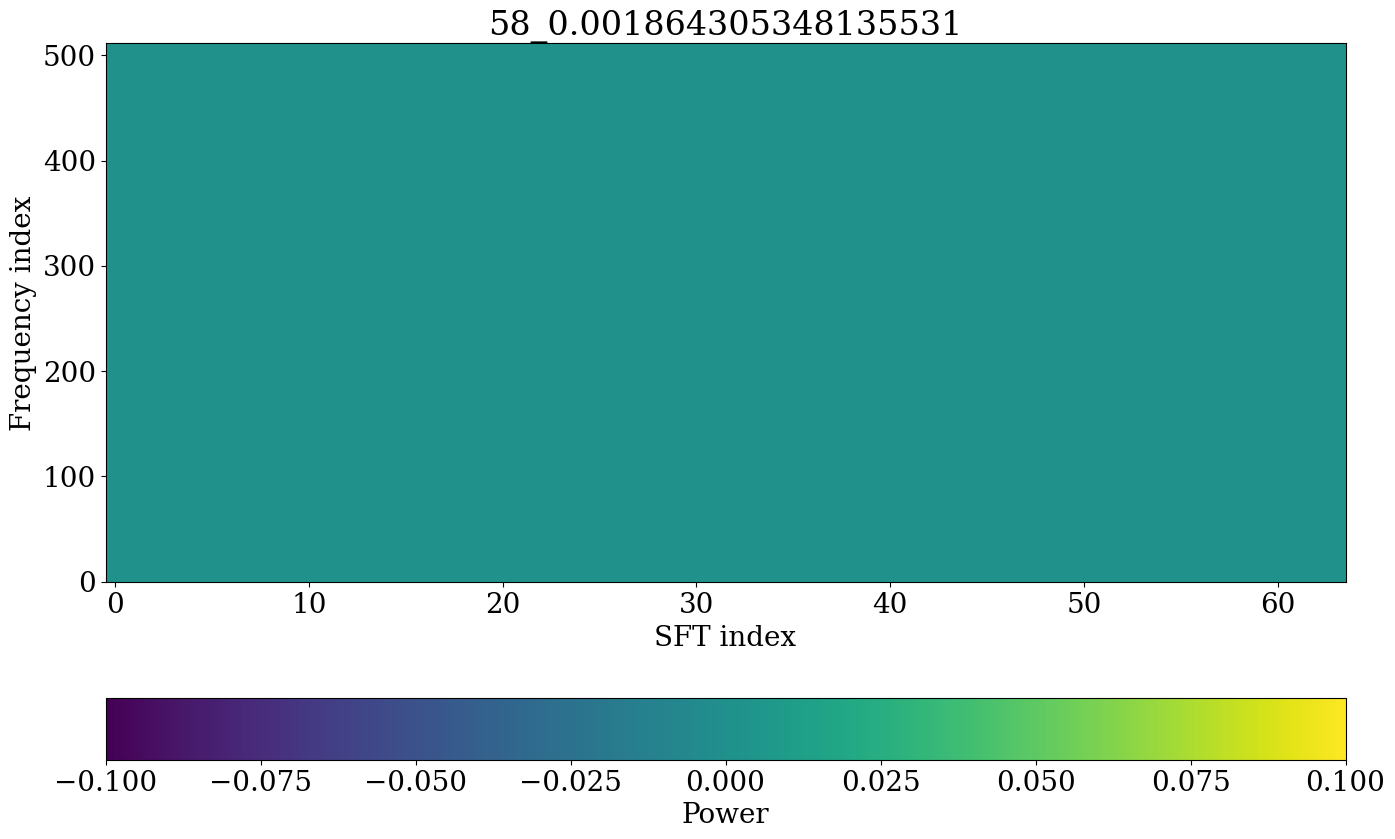

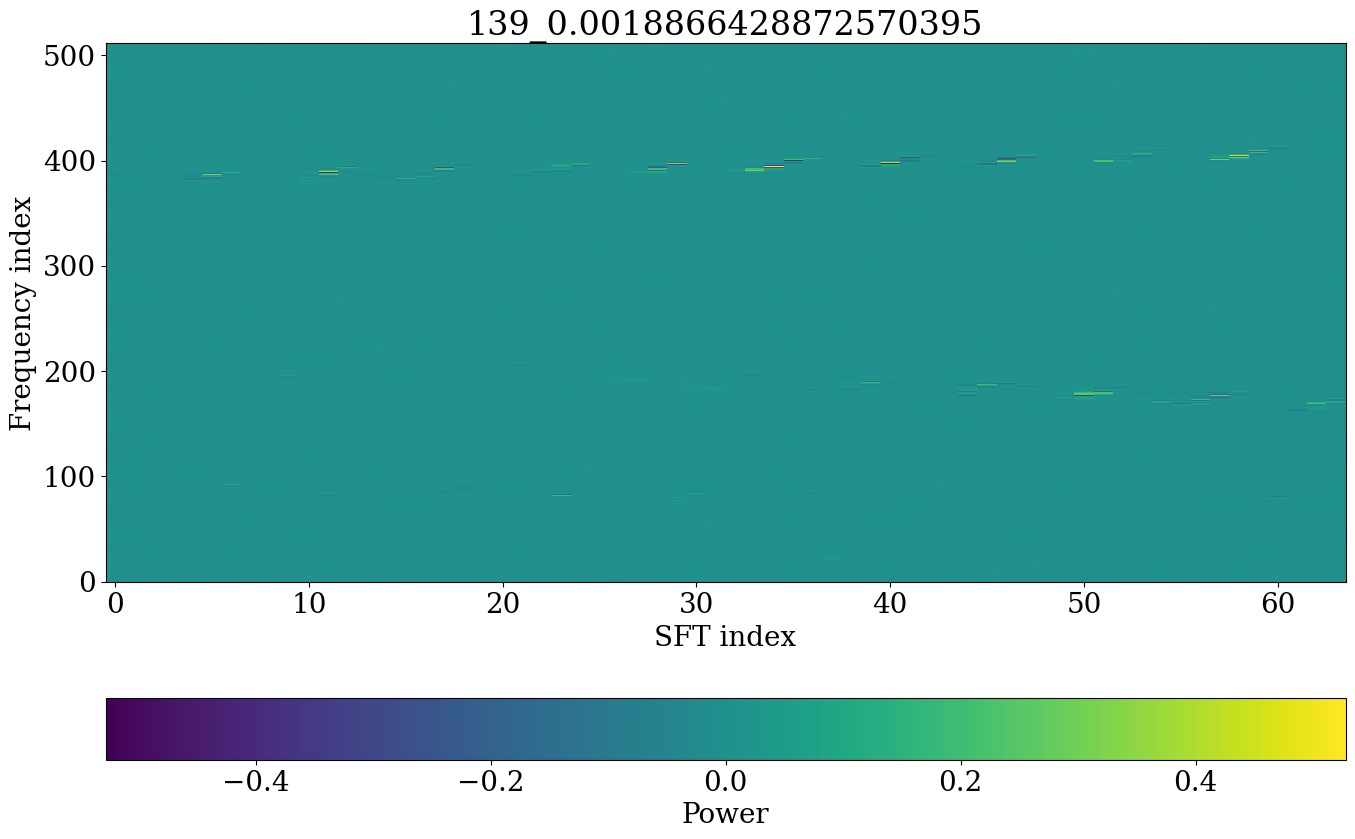

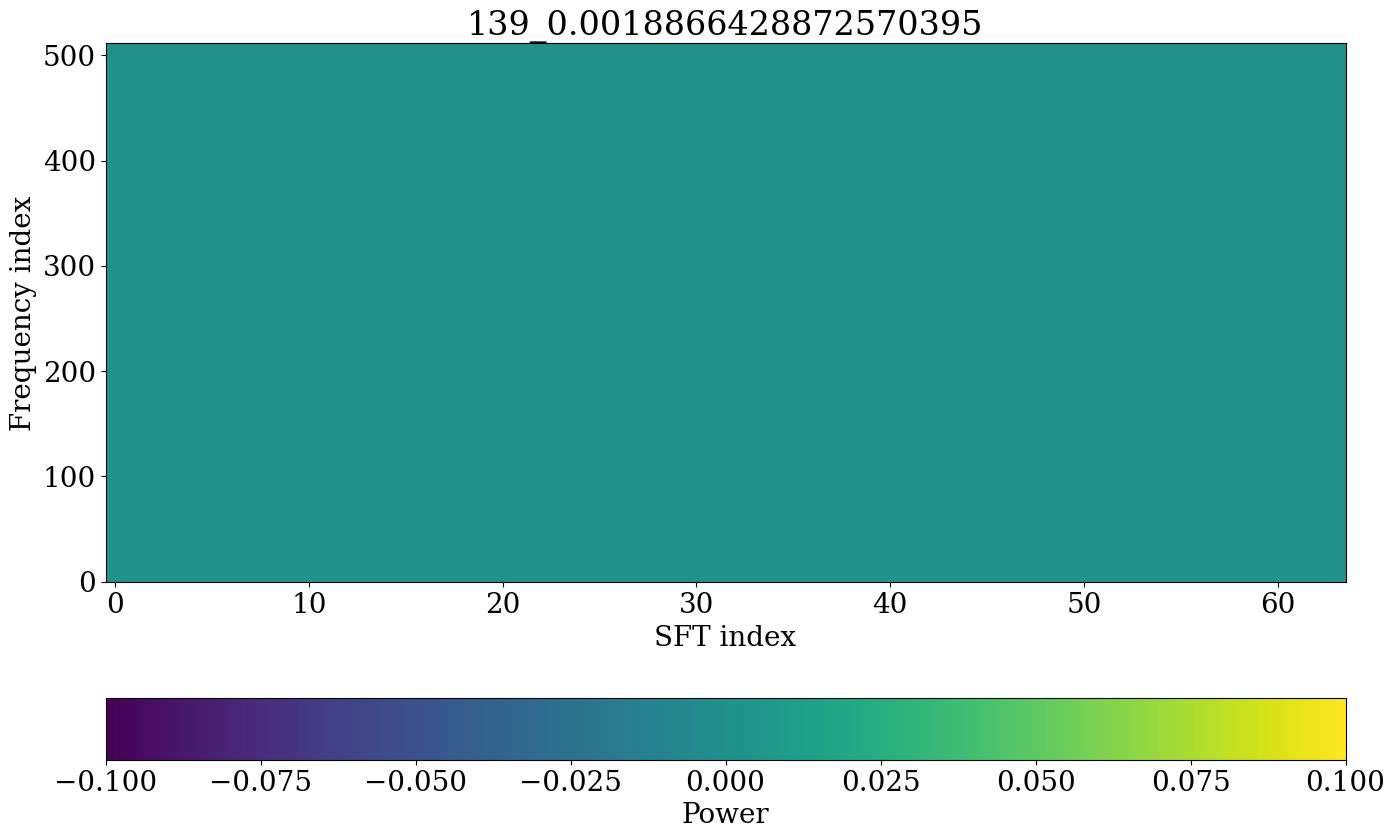

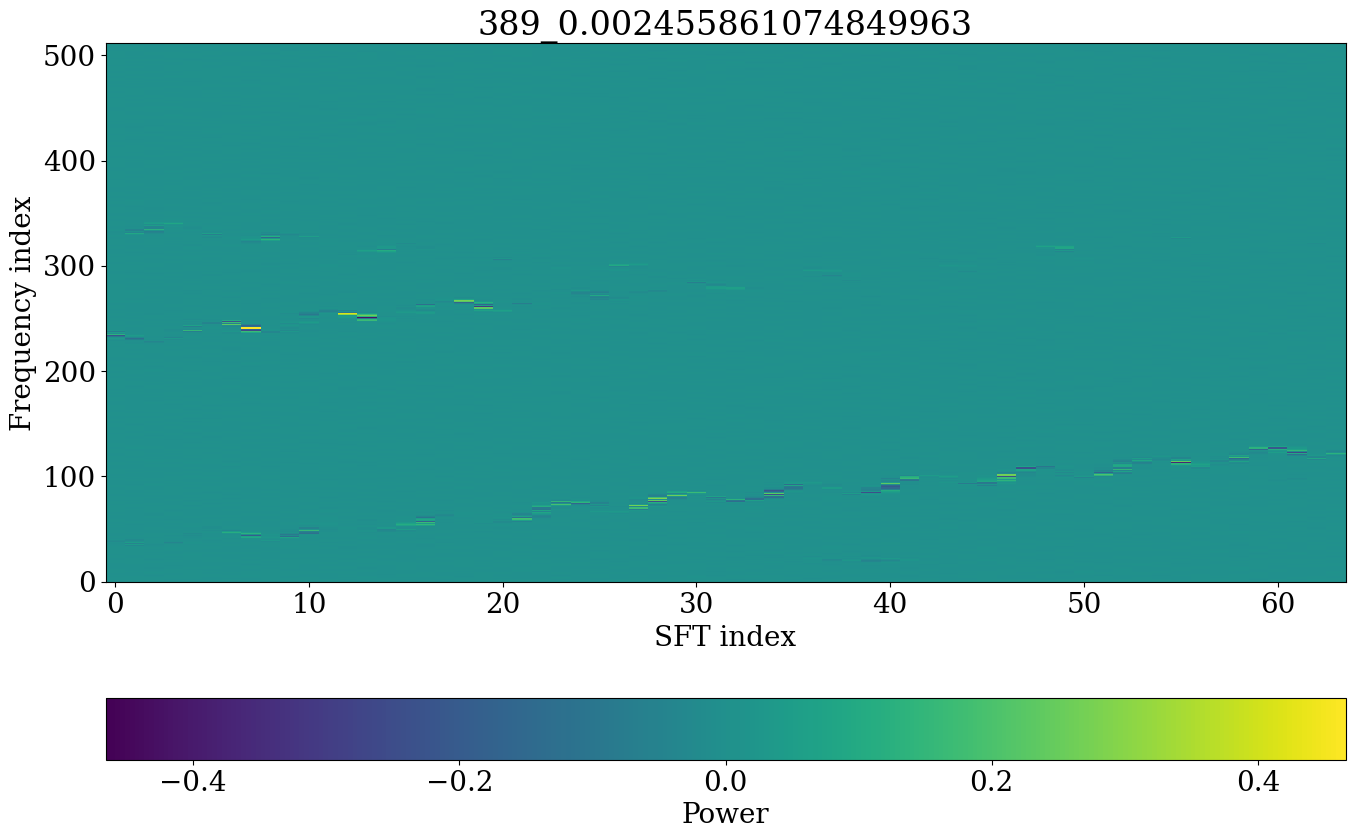

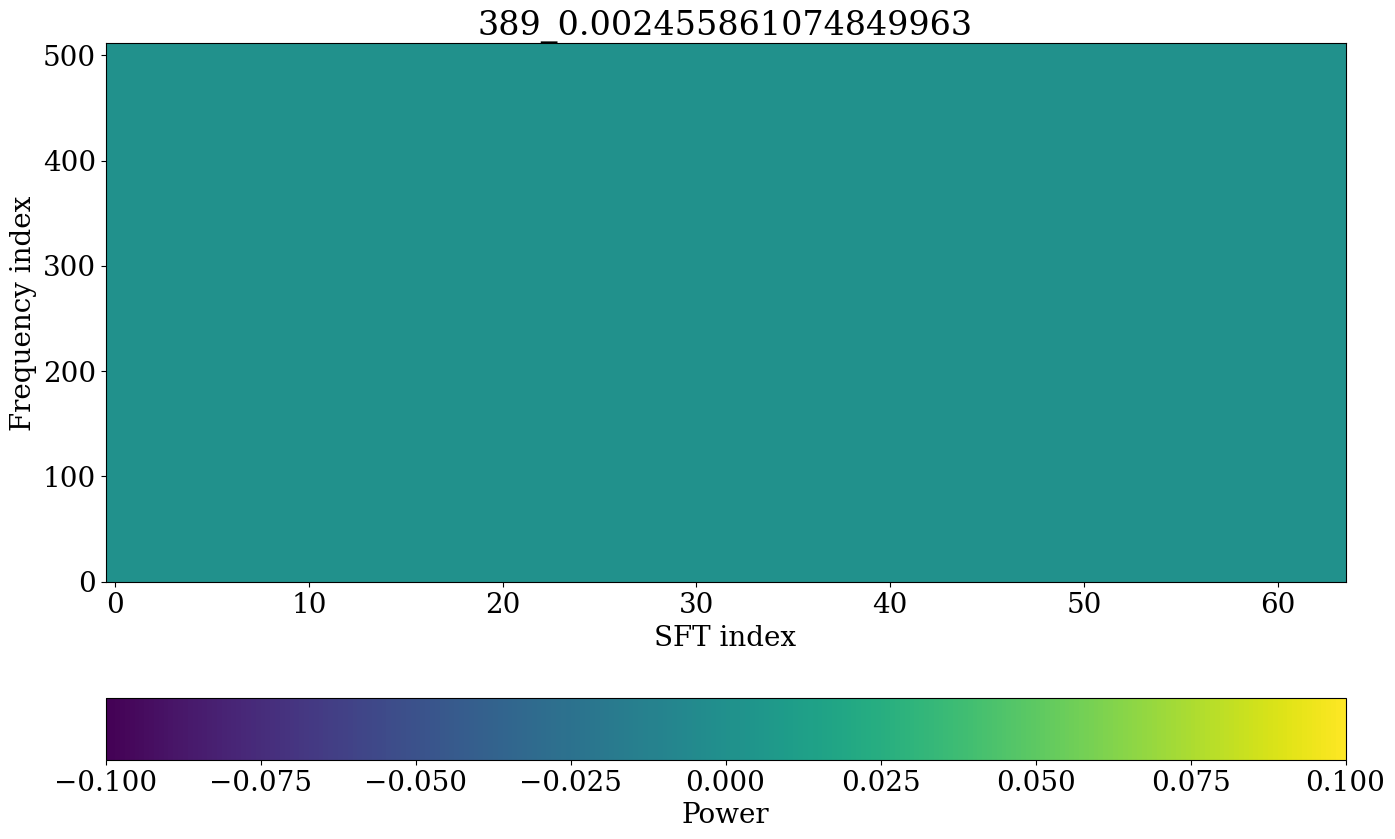

In [9]:
timestamps = np.arange(0, size[1])
frequency = np.arange(0, size[0])

indices = np.where(labels == np.float('inf'))[0]
stat = results_dict[np.float('inf')]
for i, idx in enumerate(indices):
    title = '{}_{}'.format(i, stat[i])
    #fig, ax = plot_spectrograms(title, timestamps, frequency, inputs[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_input_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_input_{}.png'.format(version))
    #fig, ax = plot_spectrograms(title, timestamps, frequency, predictions[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_pred_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_pred_{}.png'.format(version))
    if (stat[i] - x_pfa) > 0:
        fig, ax = plot_spectrograms(title, timestamps, frequency, predictions[idx].transpose(1, 2, 0))
        fig, ax = plot_spectrograms(title, timestamps, frequency, ground_truth[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_target_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_target_{}.png'.format(version))

/gpfs/accounts/kriles_root/kriles0/damoncht/unet_f/plot.py:30: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(16, 10))  # Single subplot


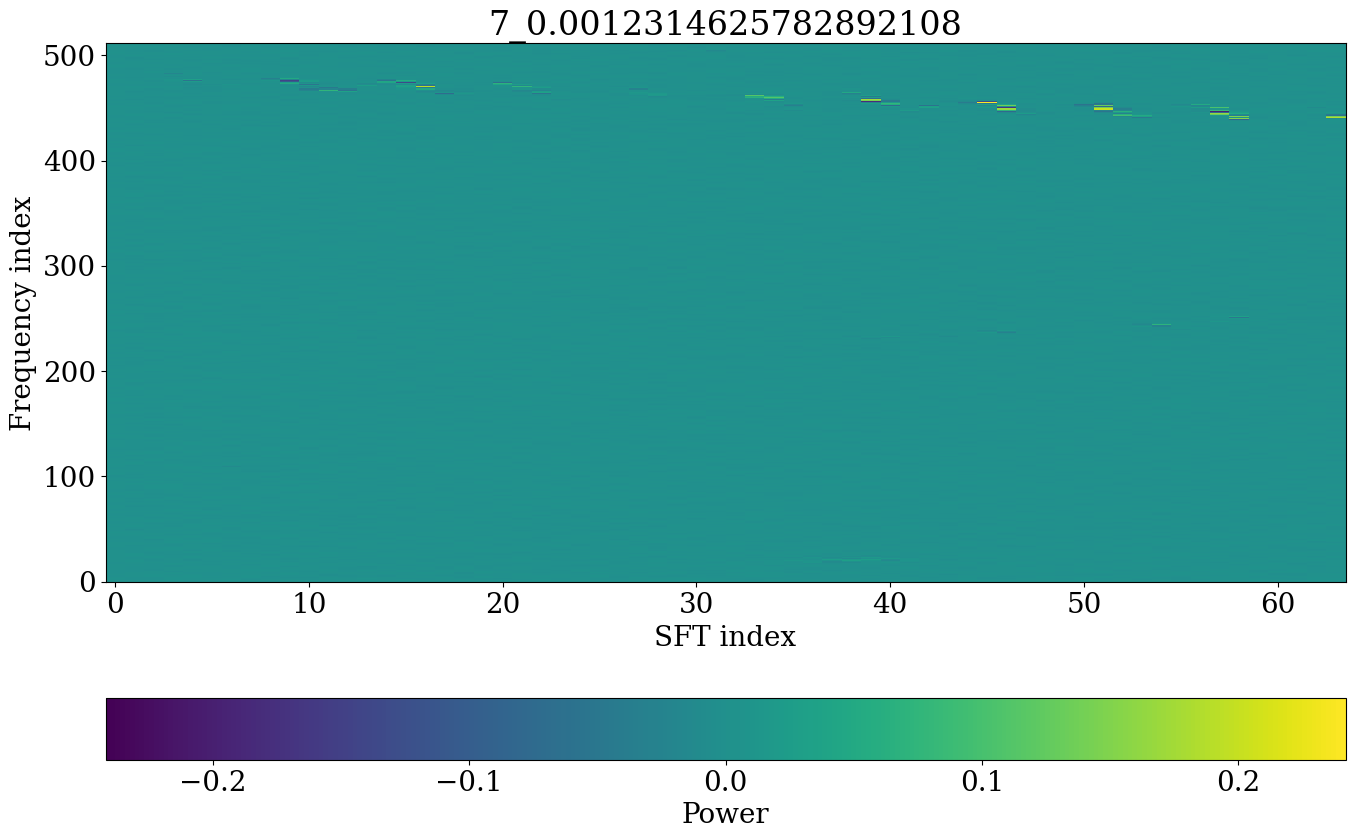

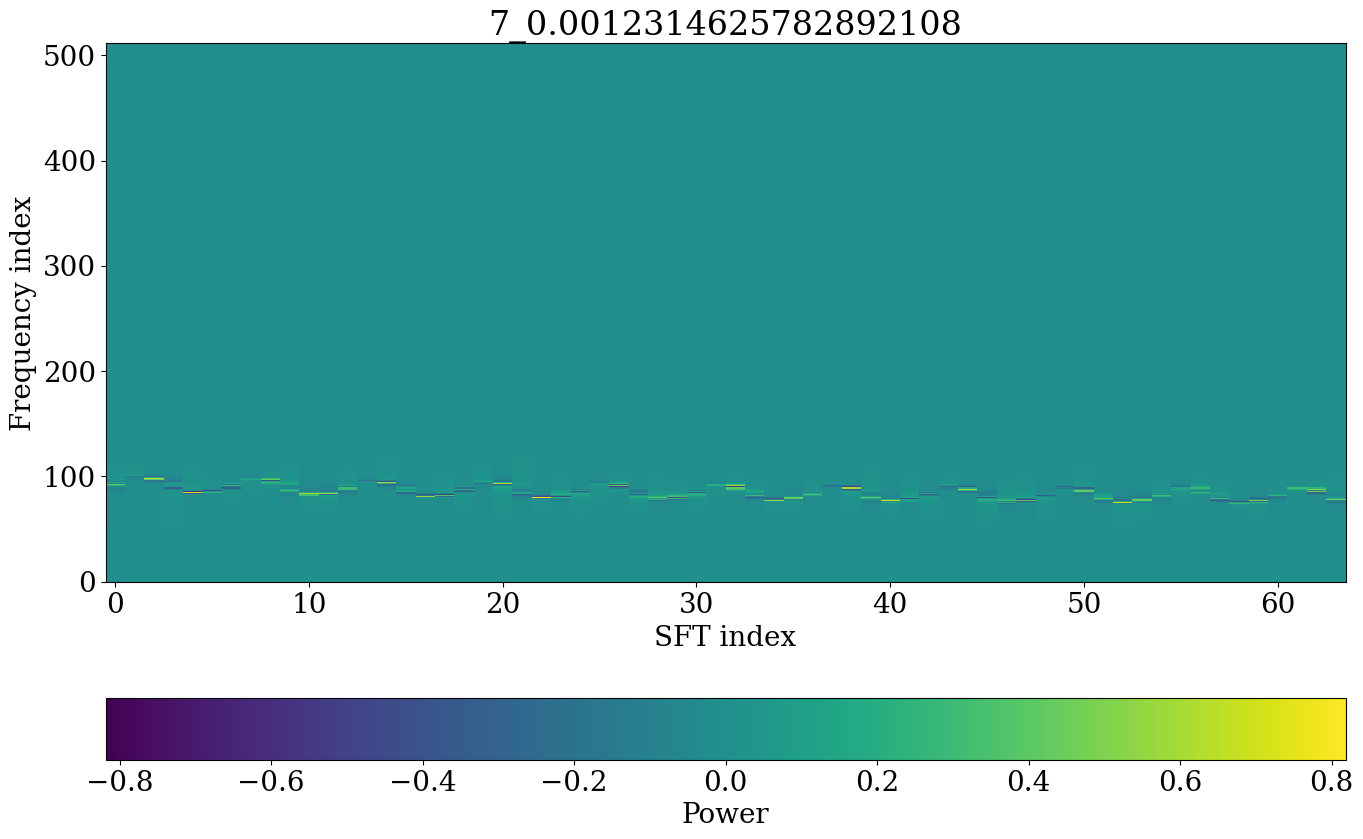

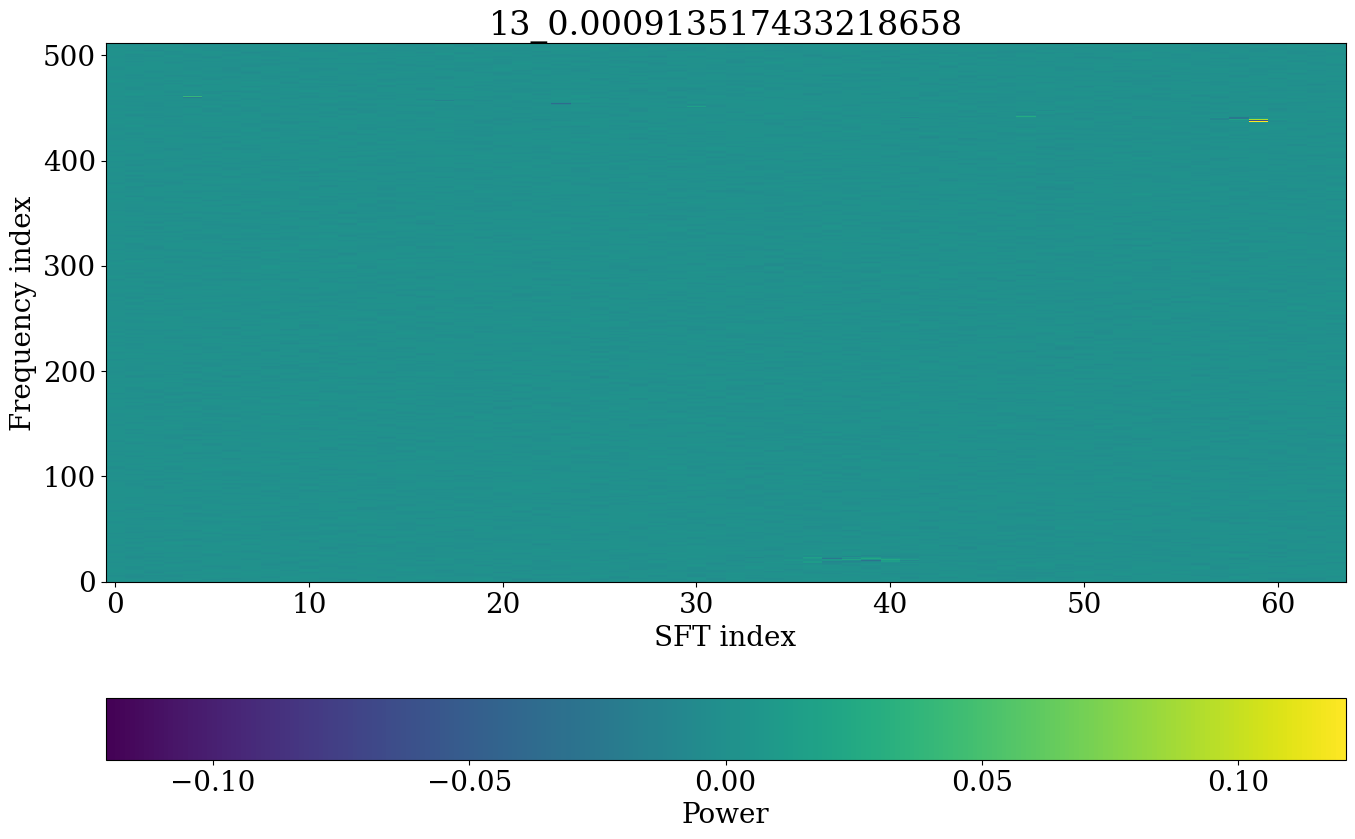

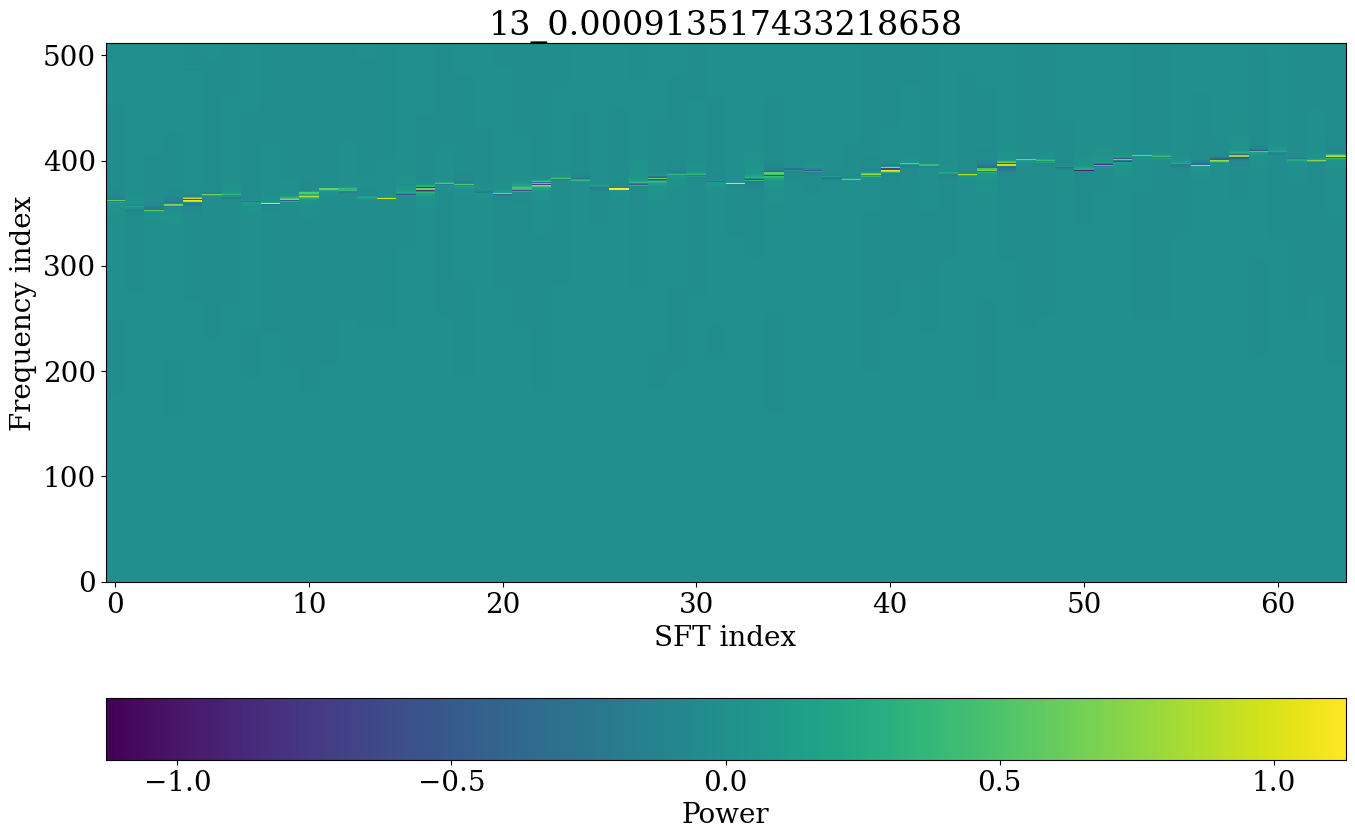

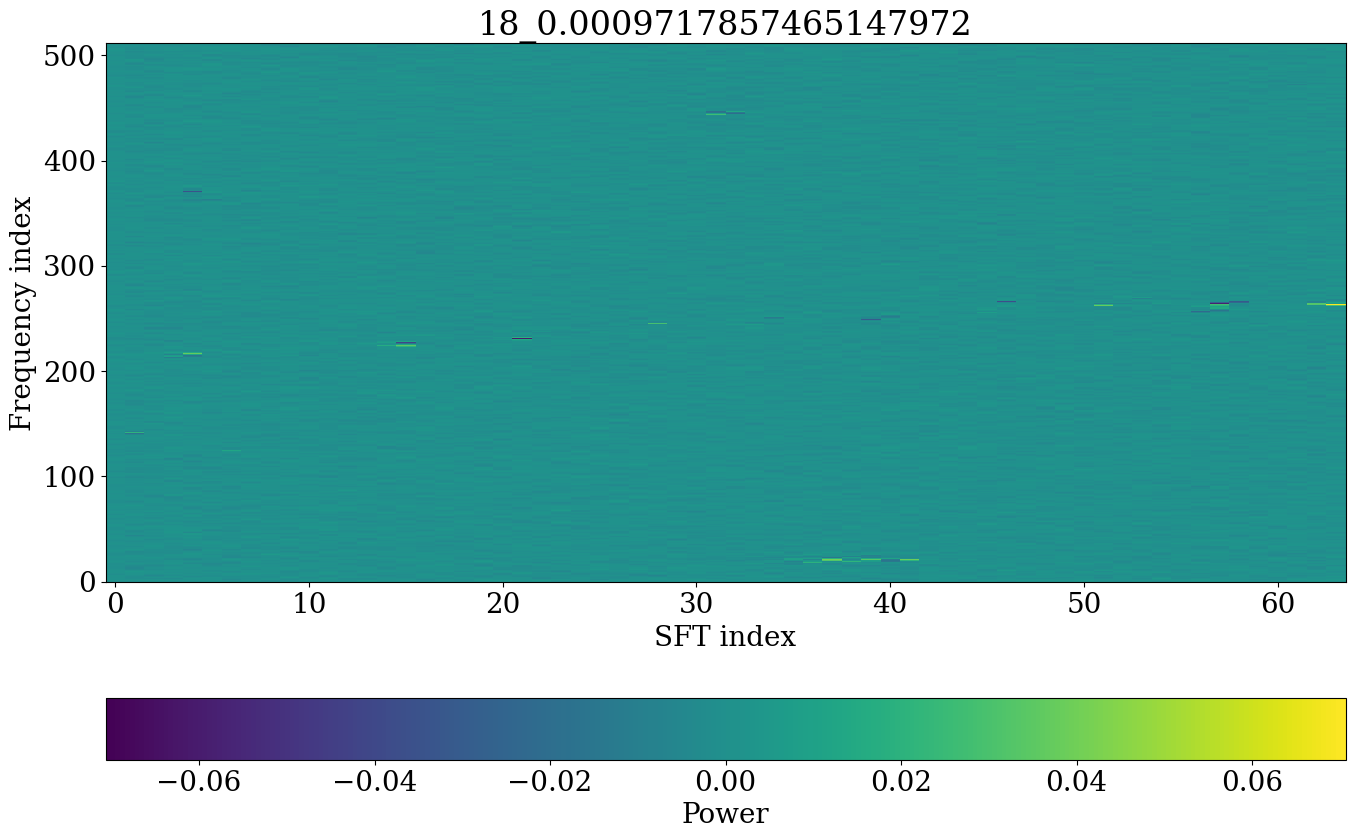

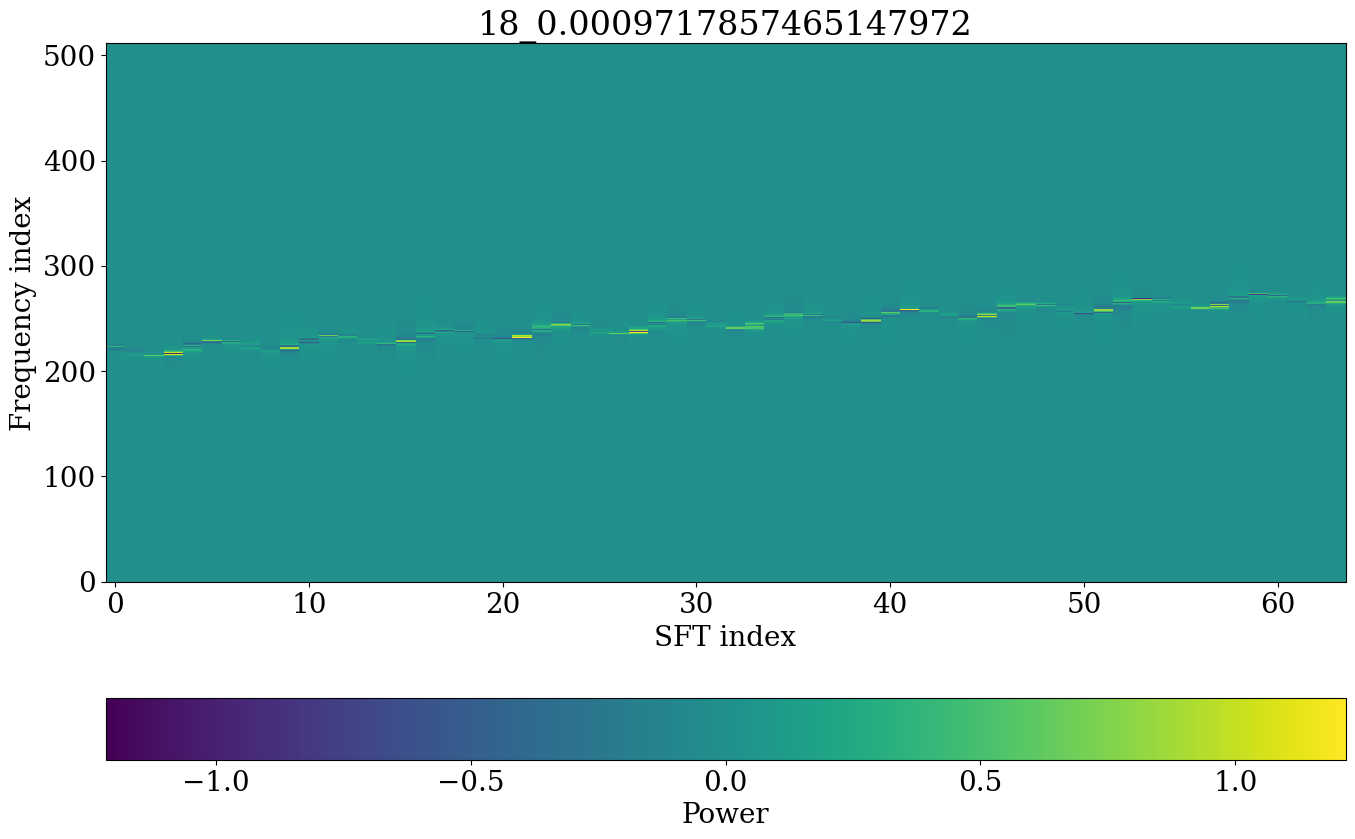

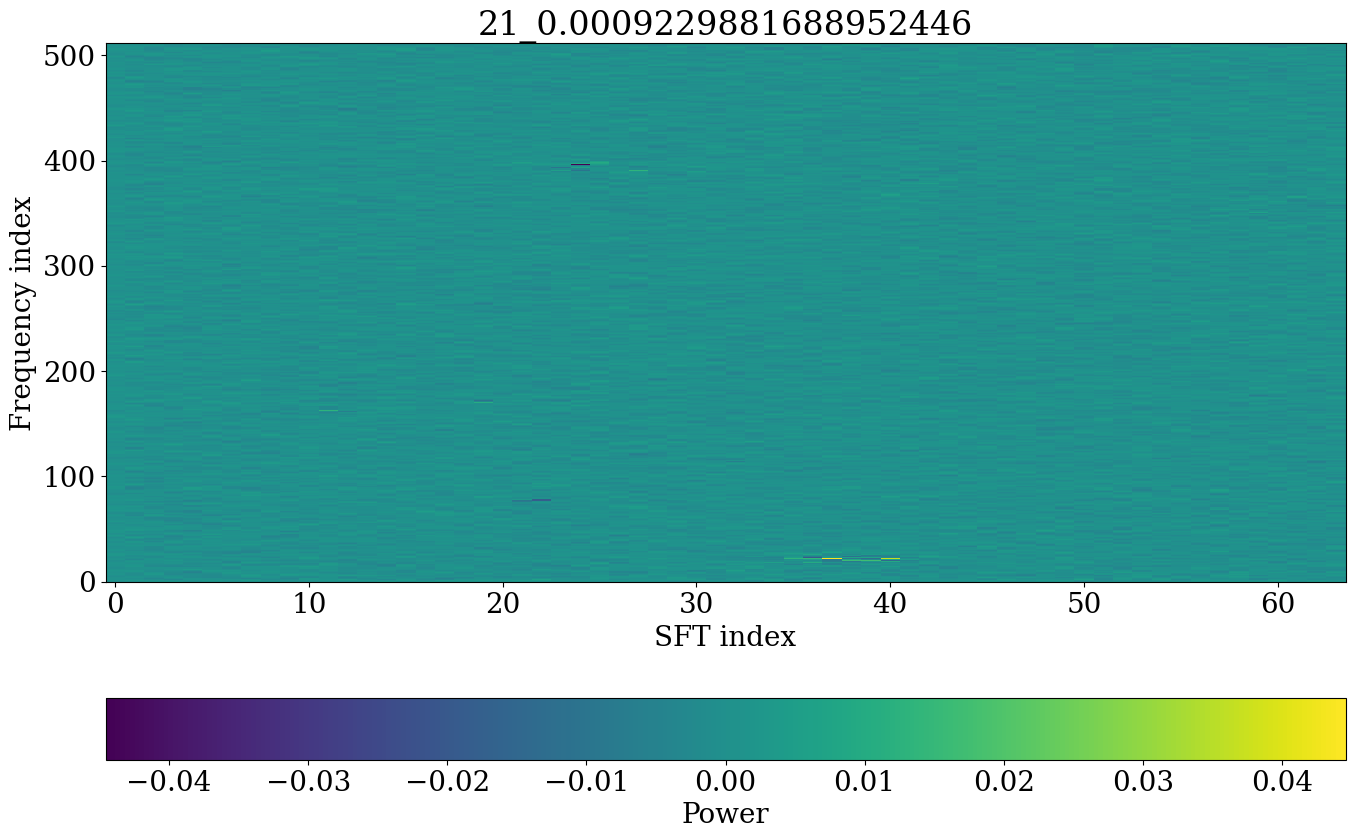

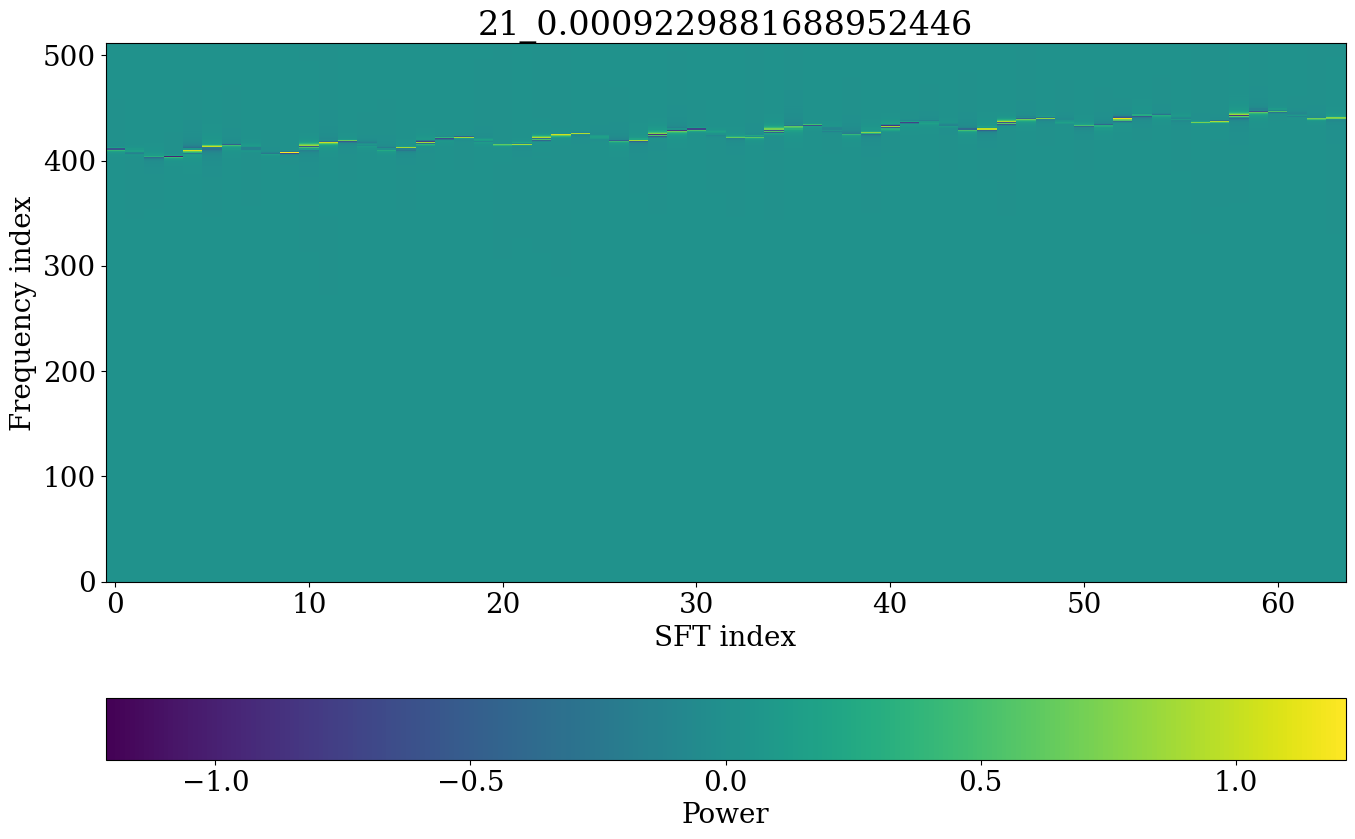

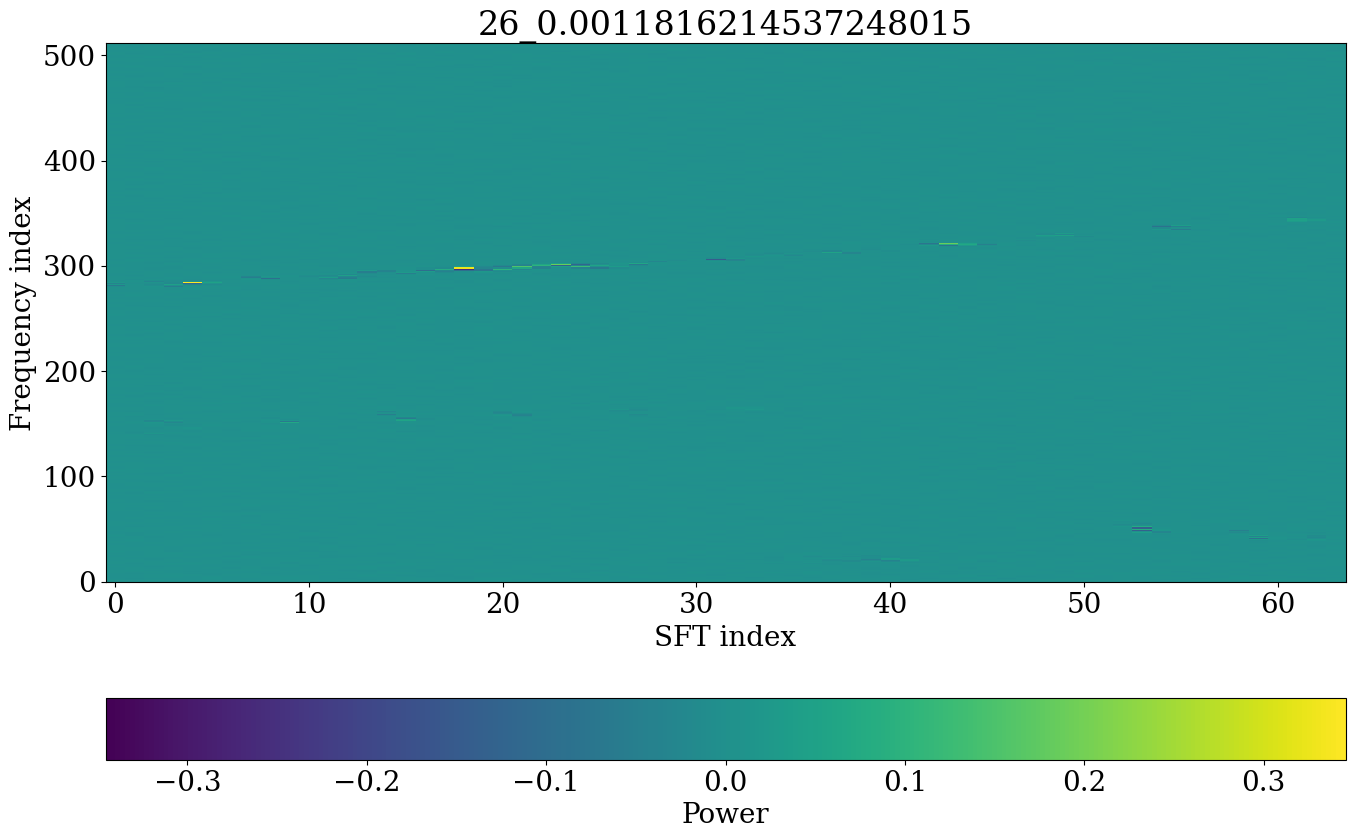

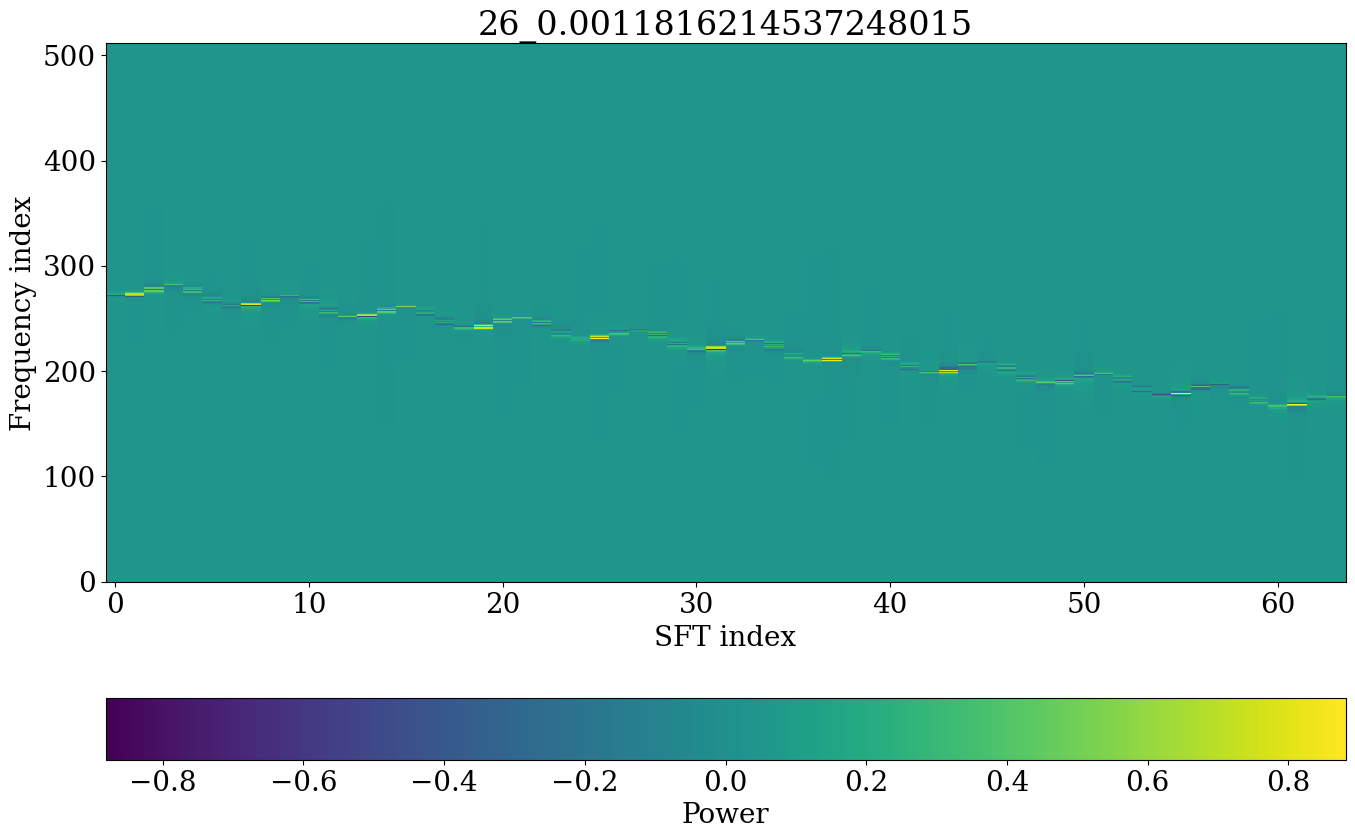

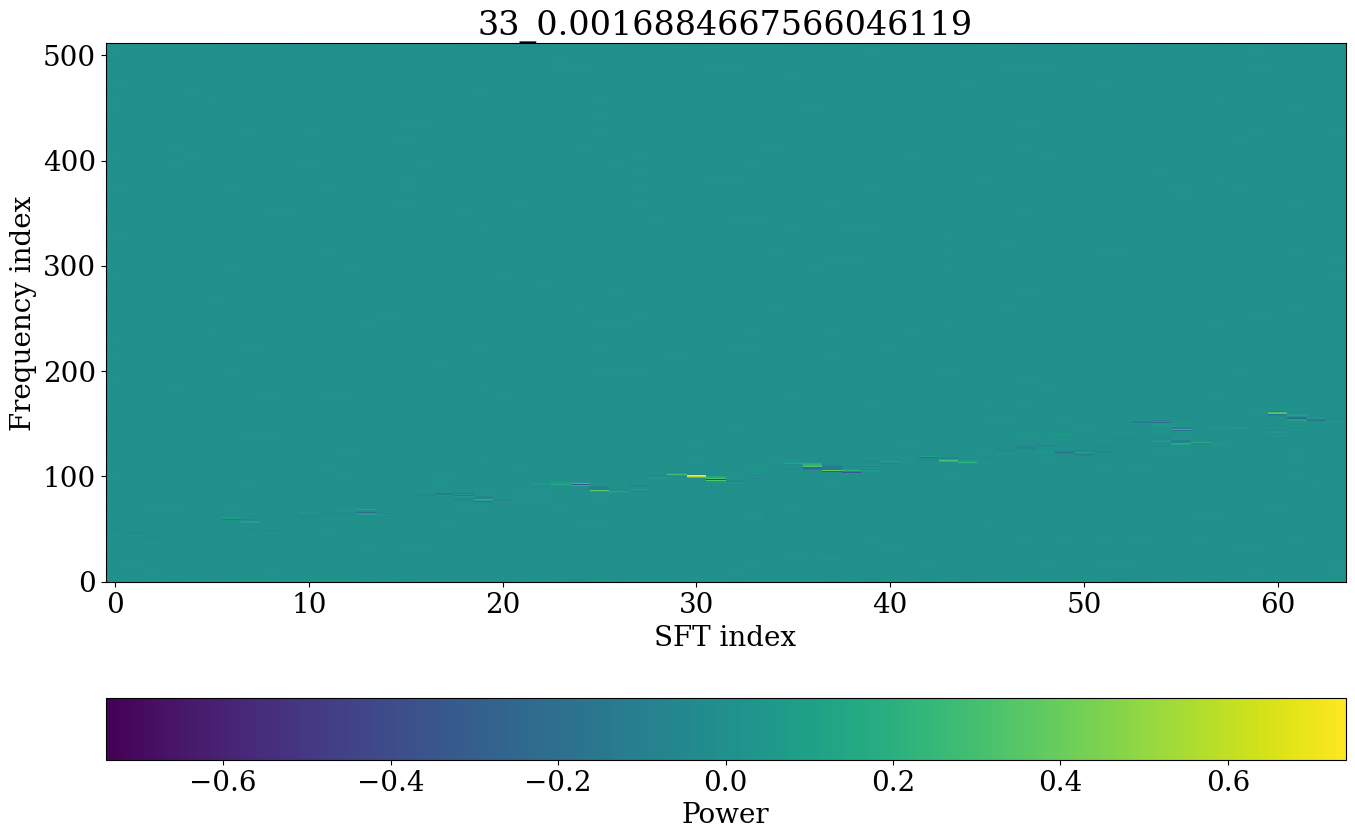

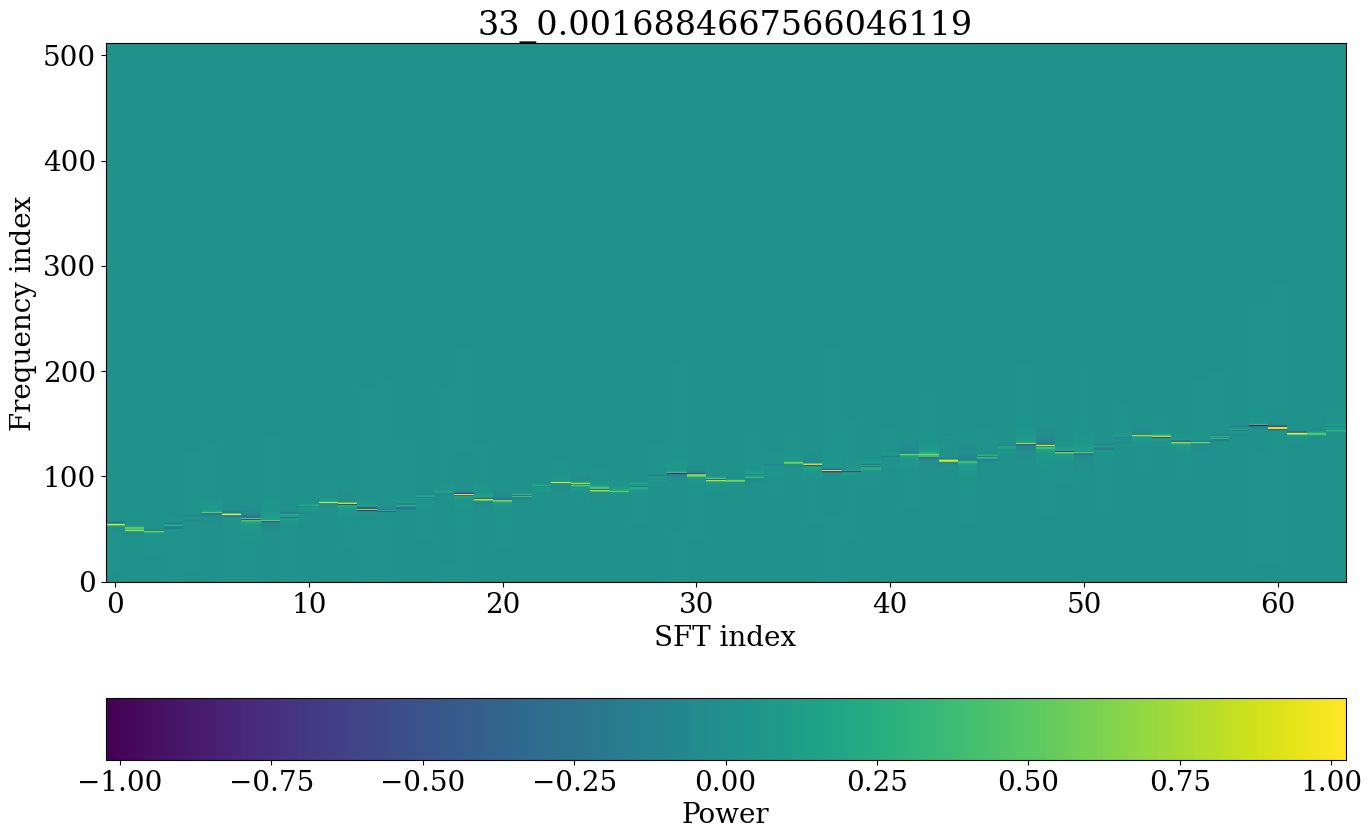

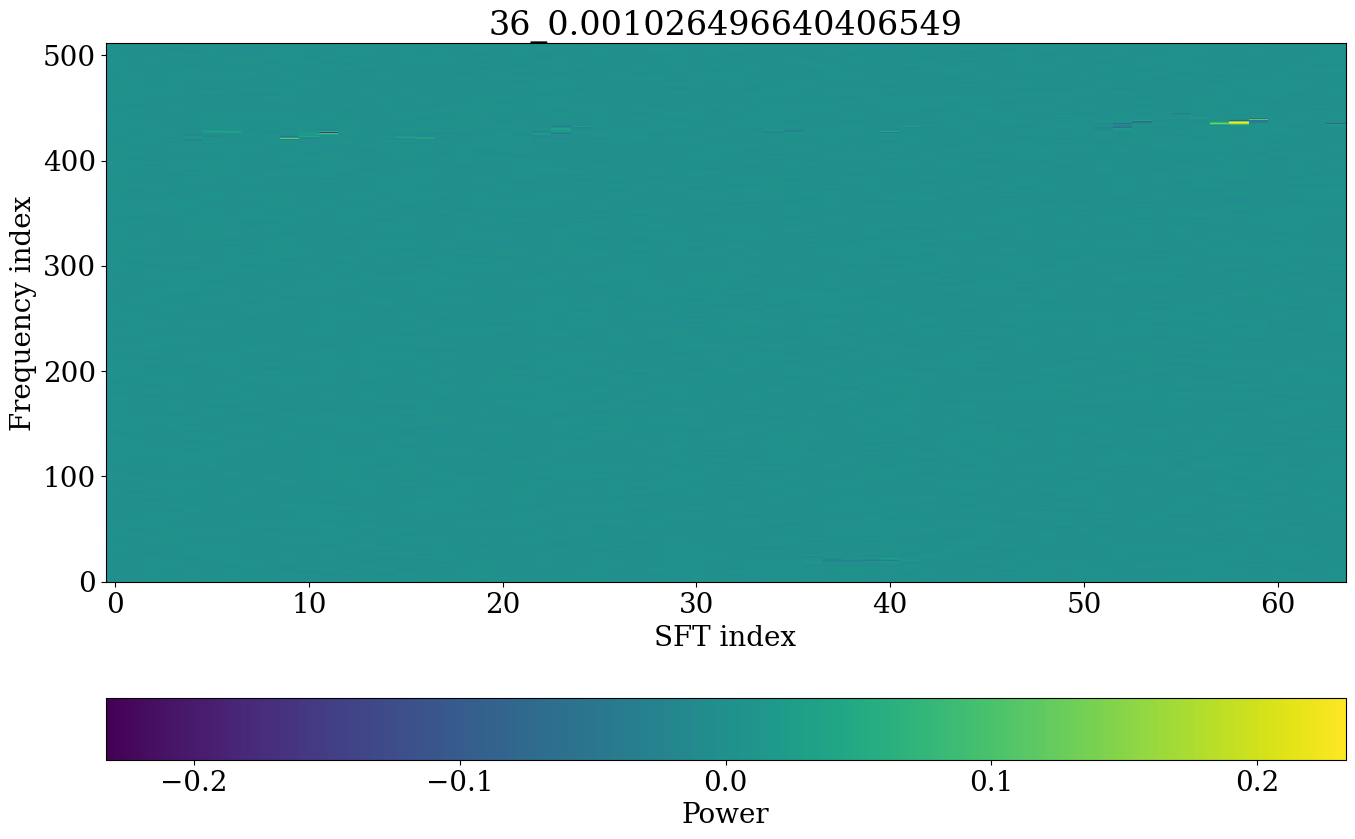

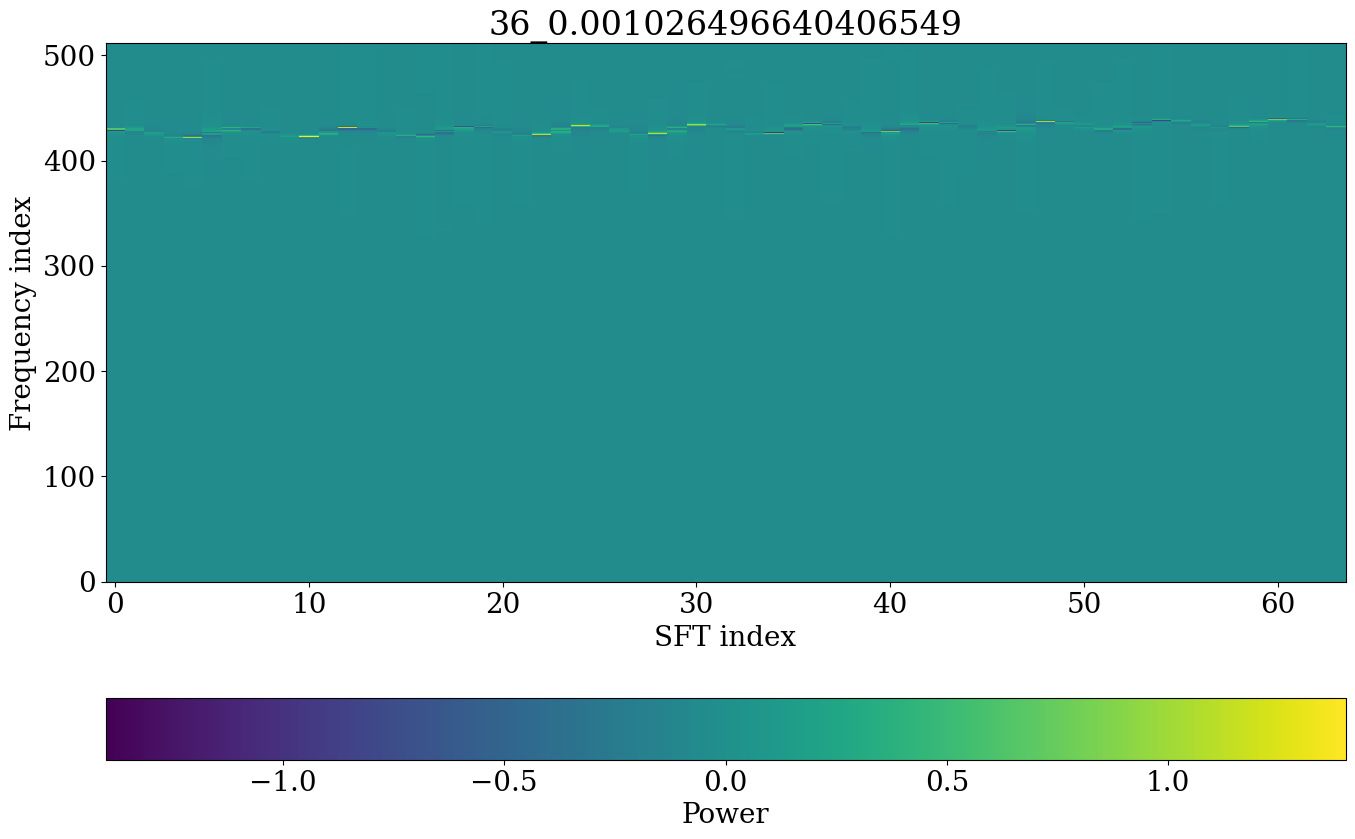

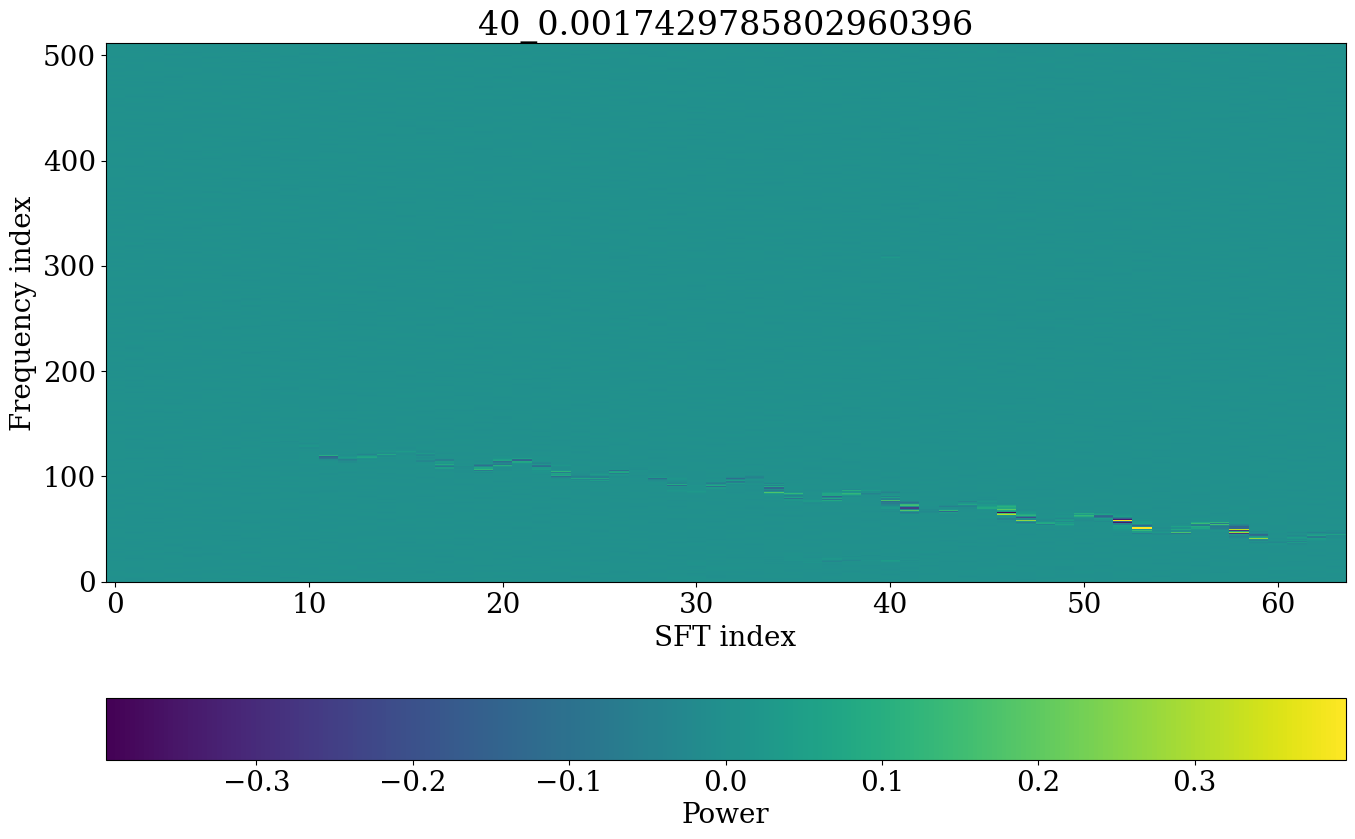

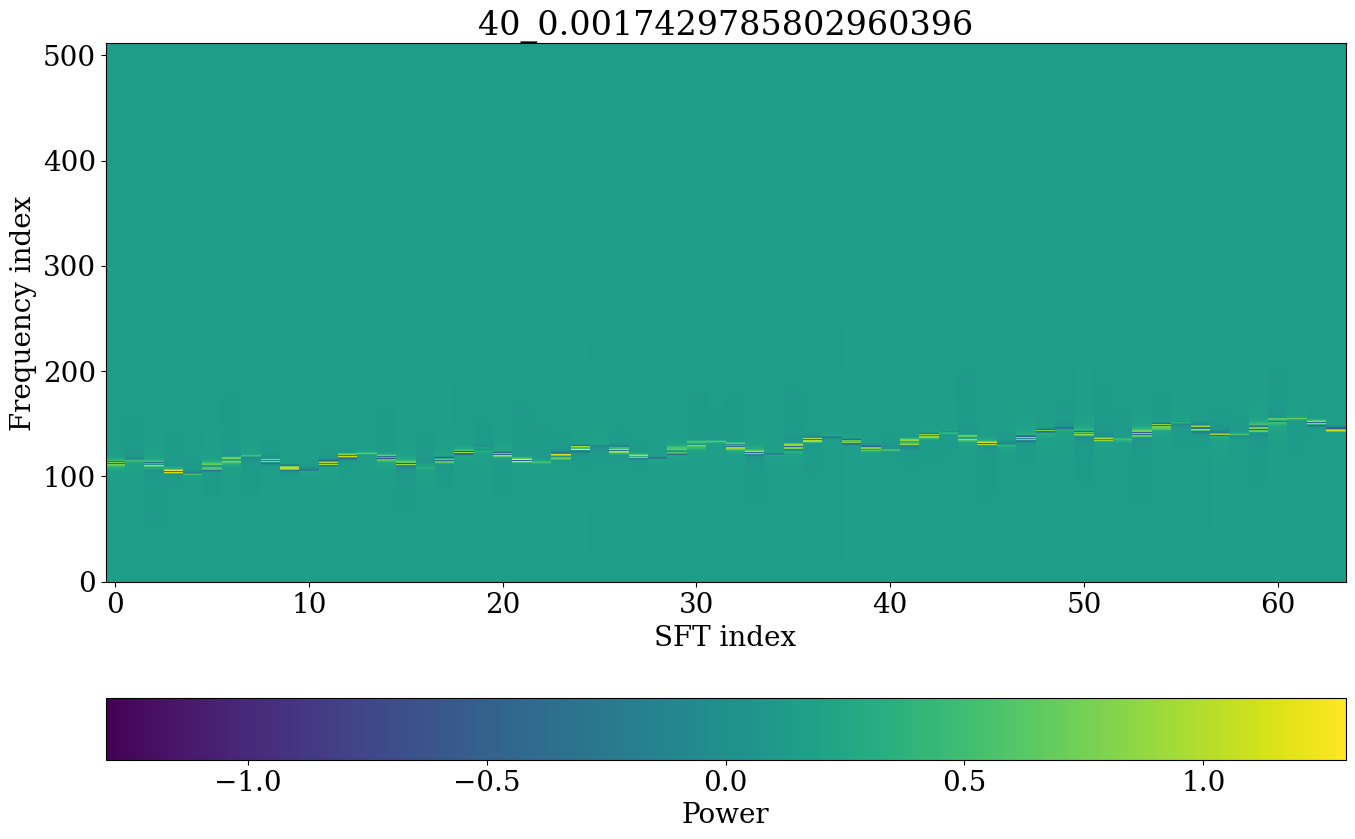

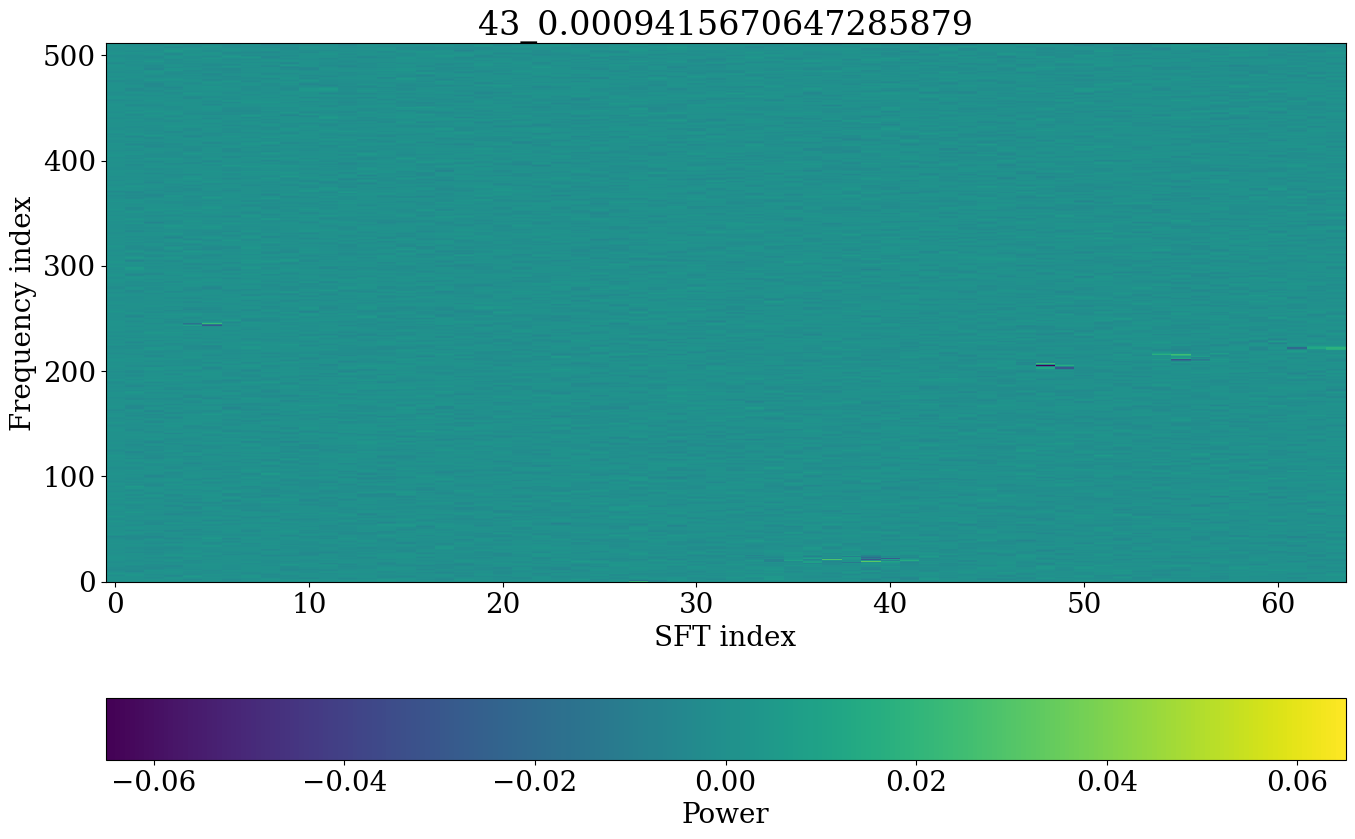

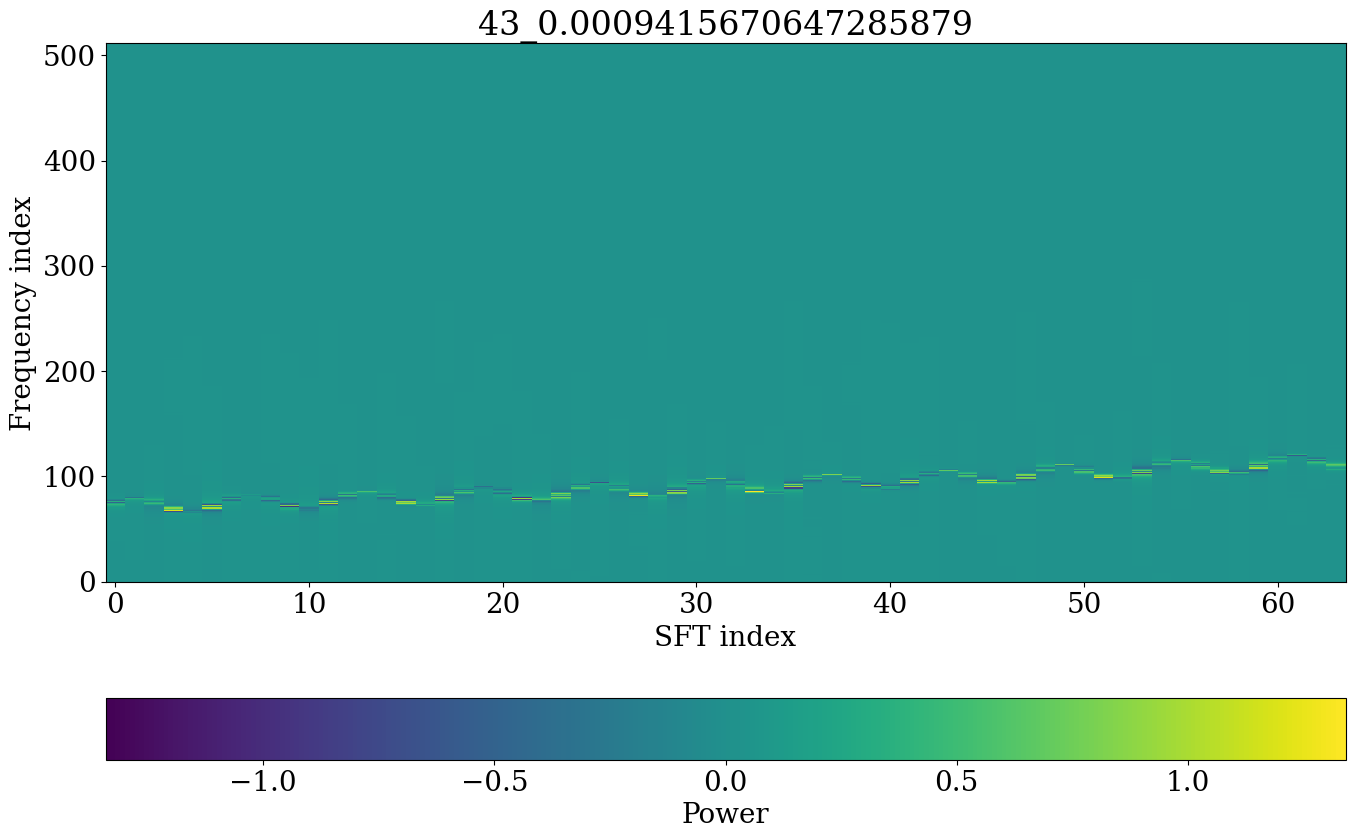

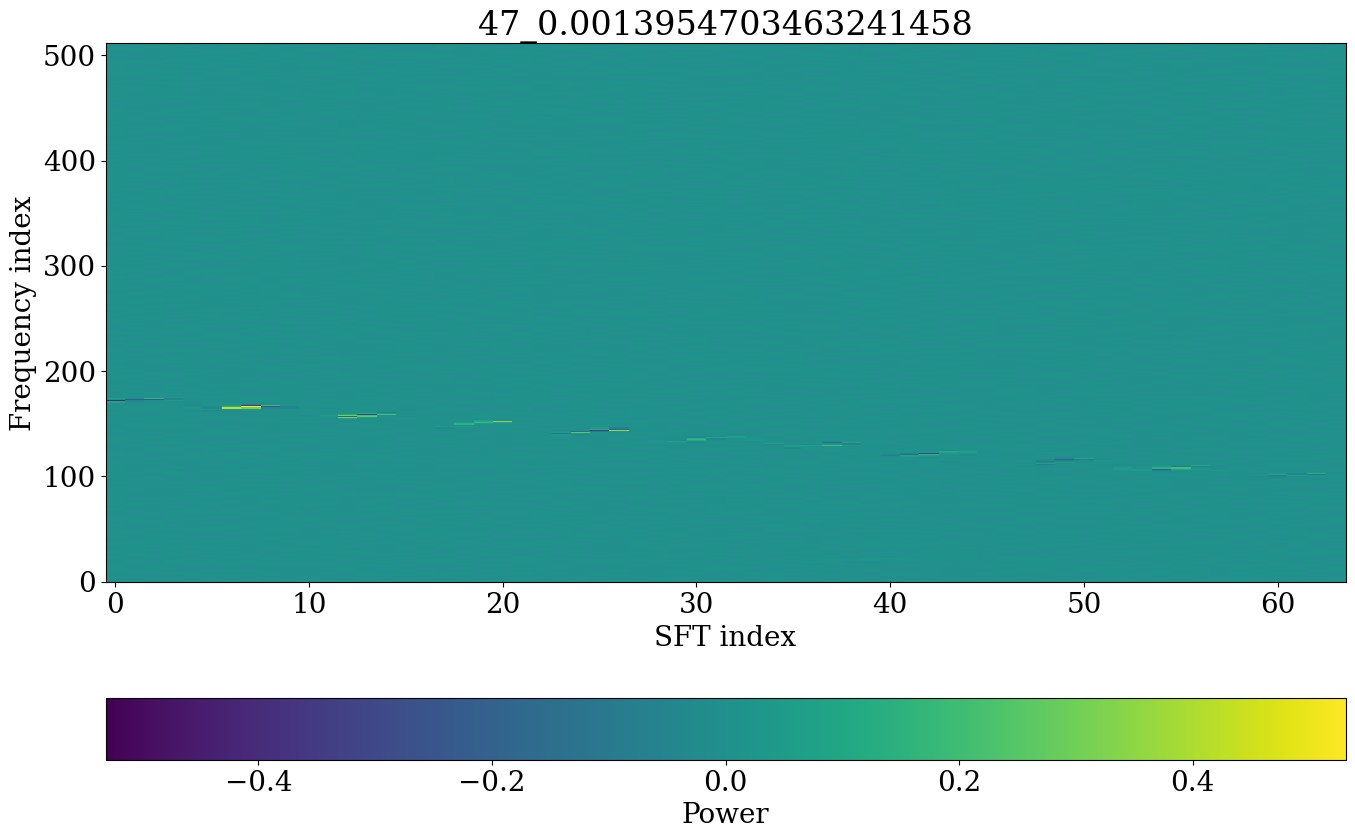

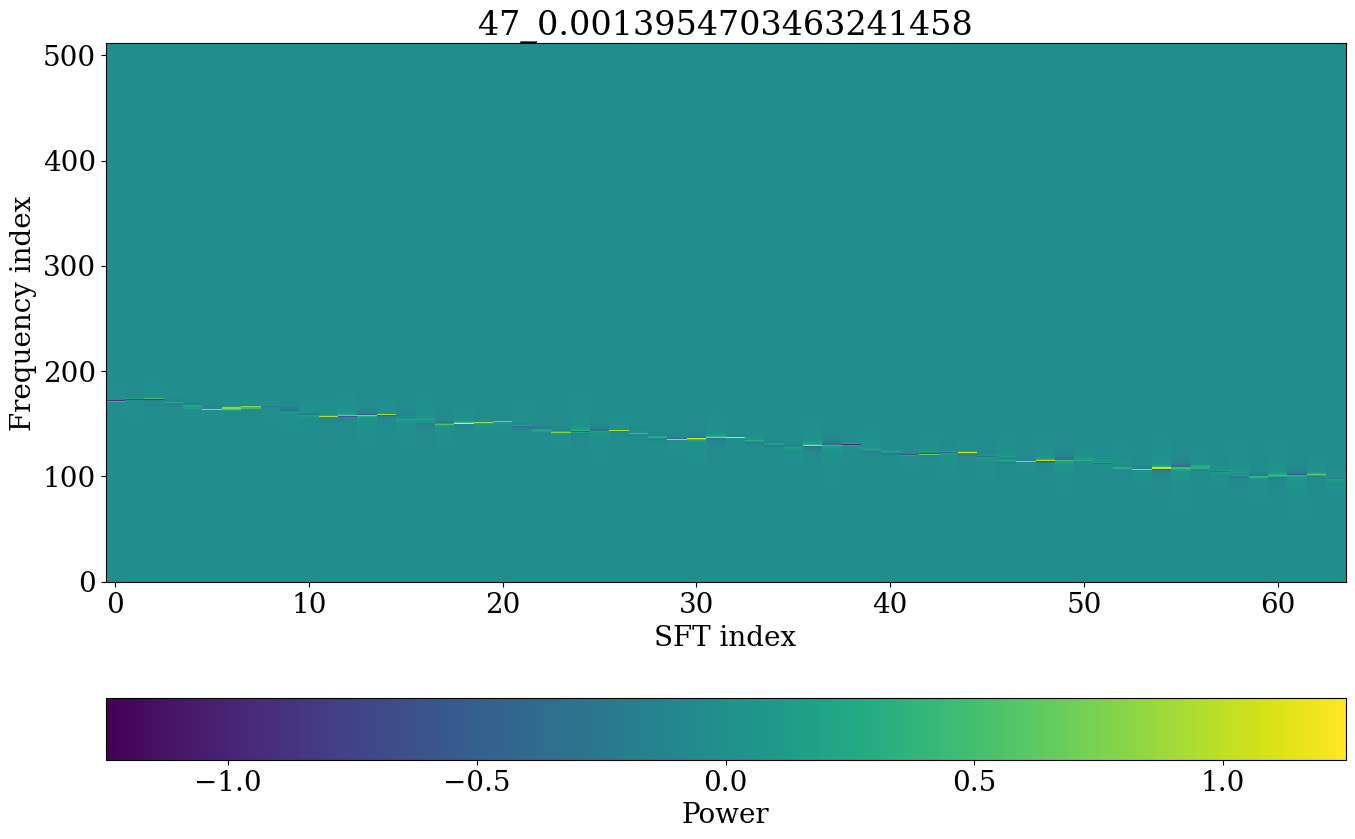

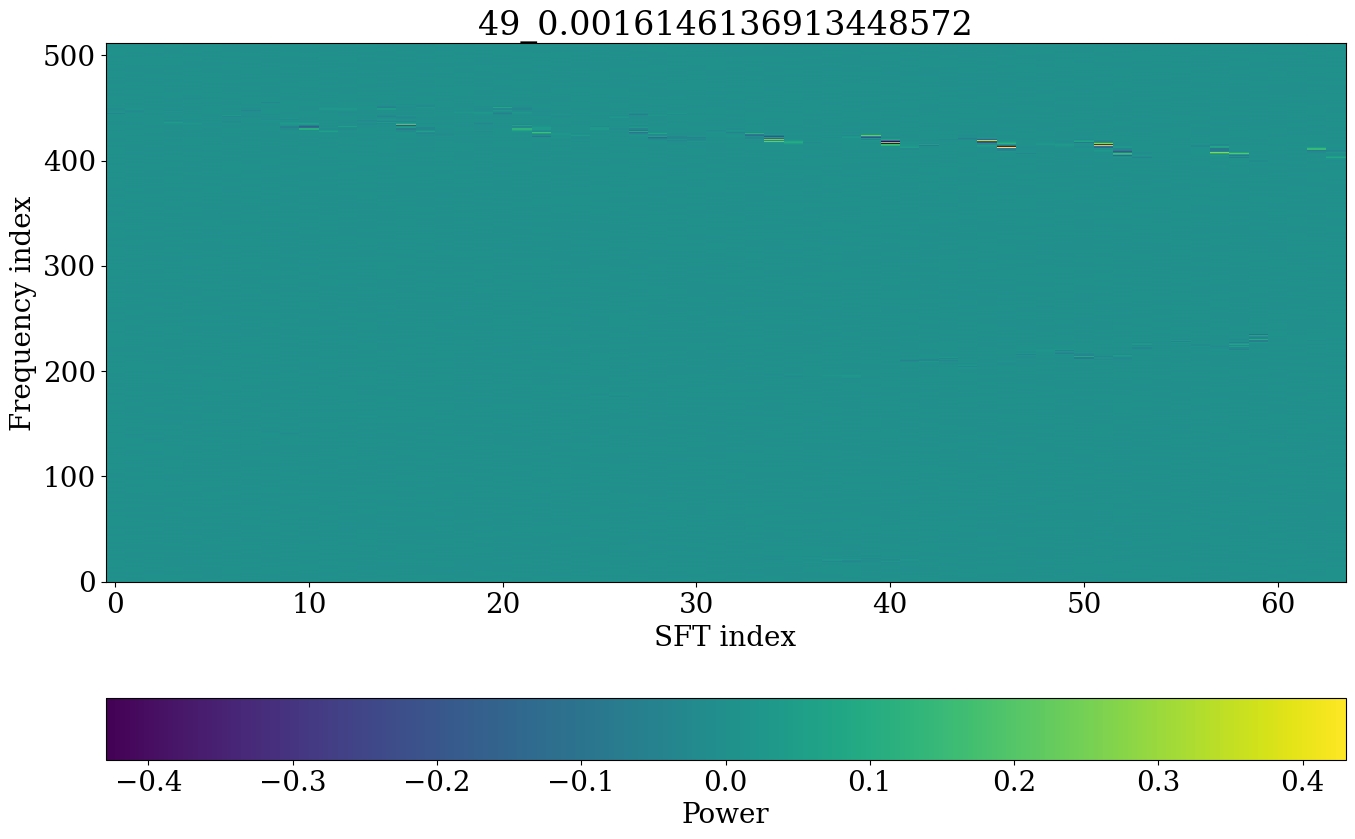

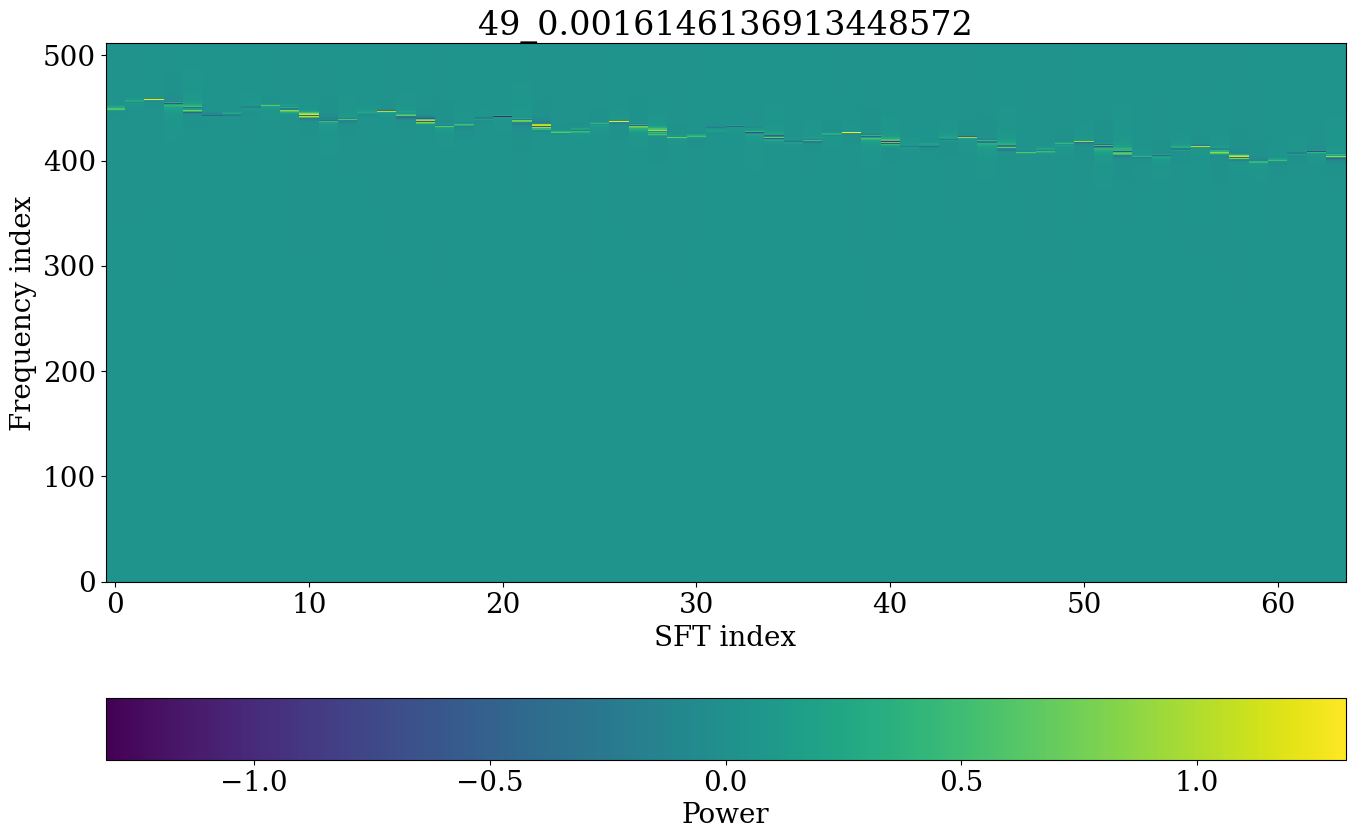

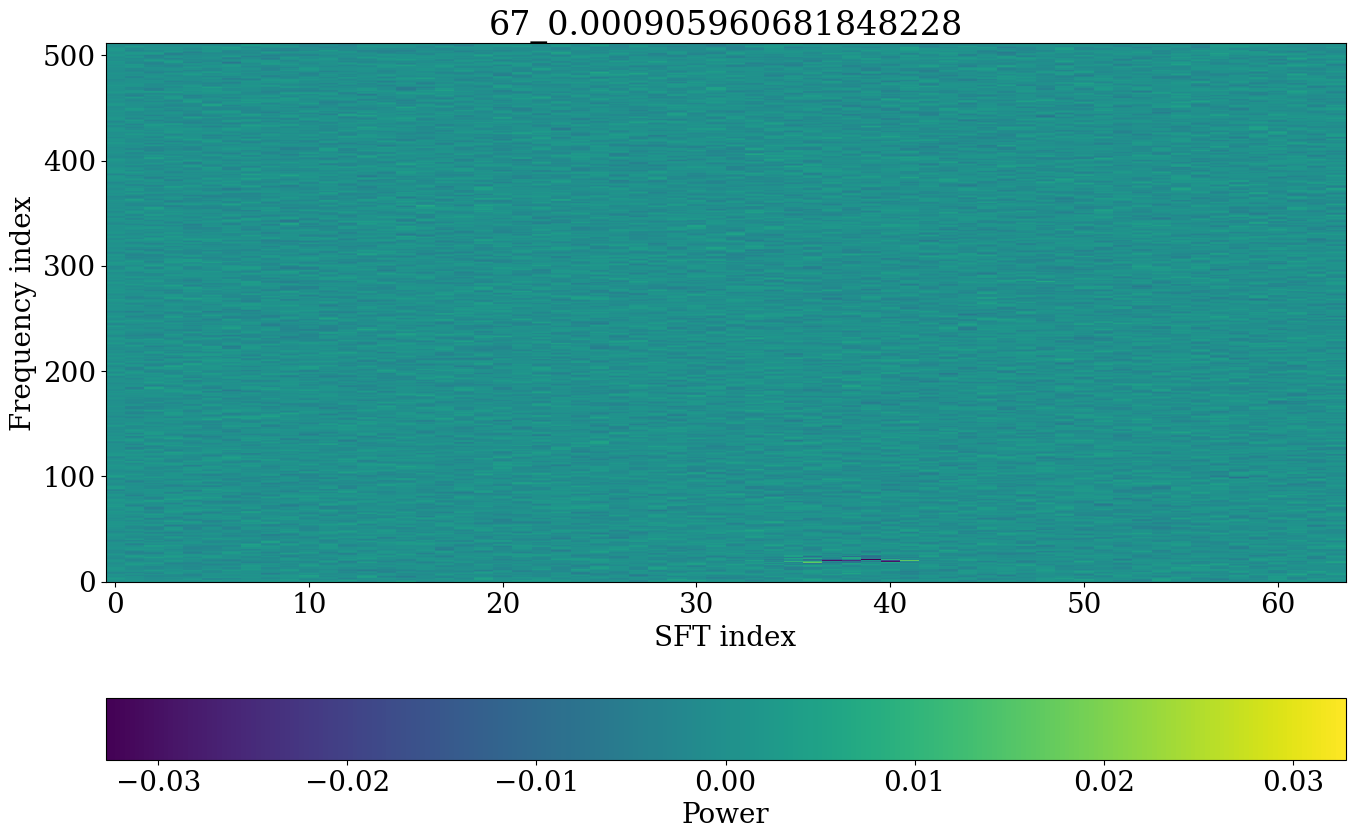

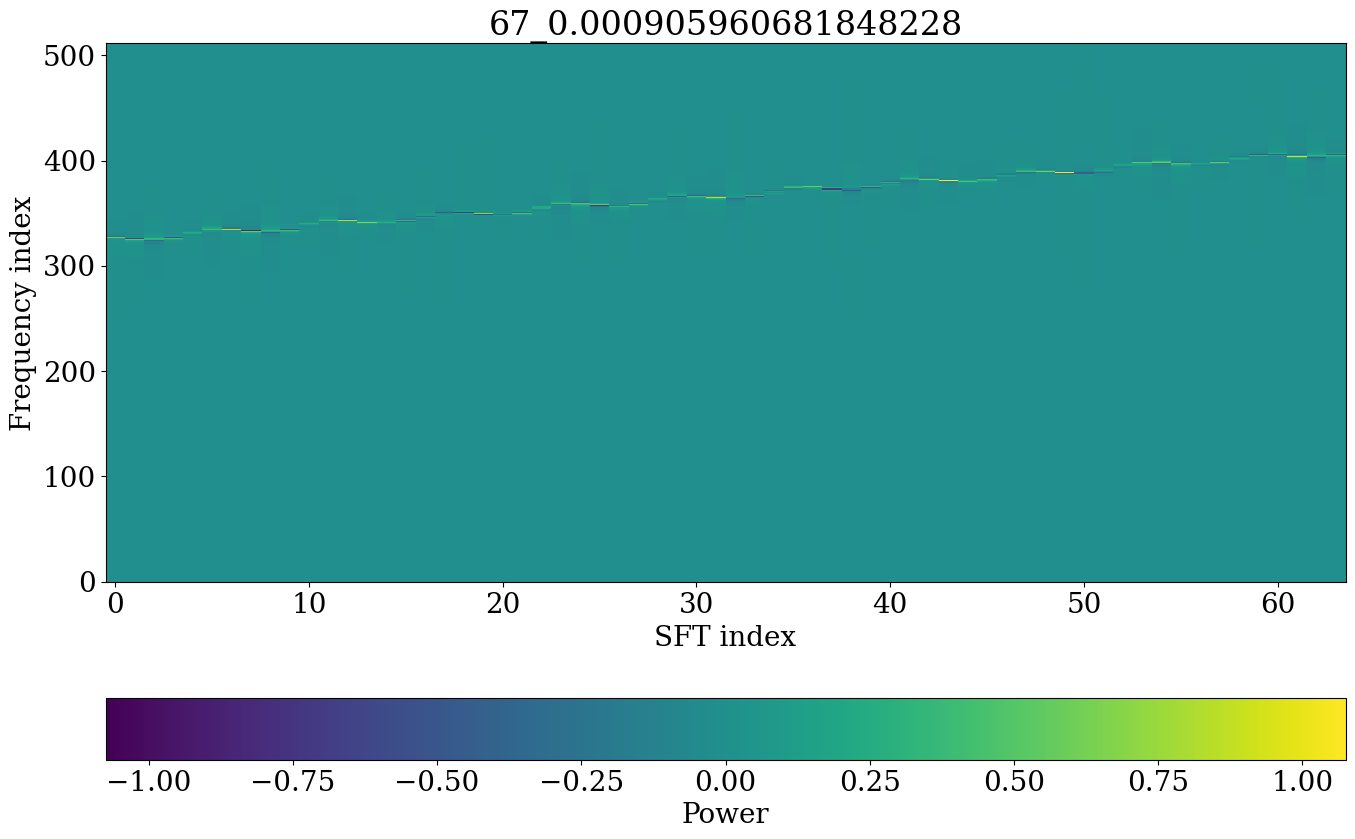

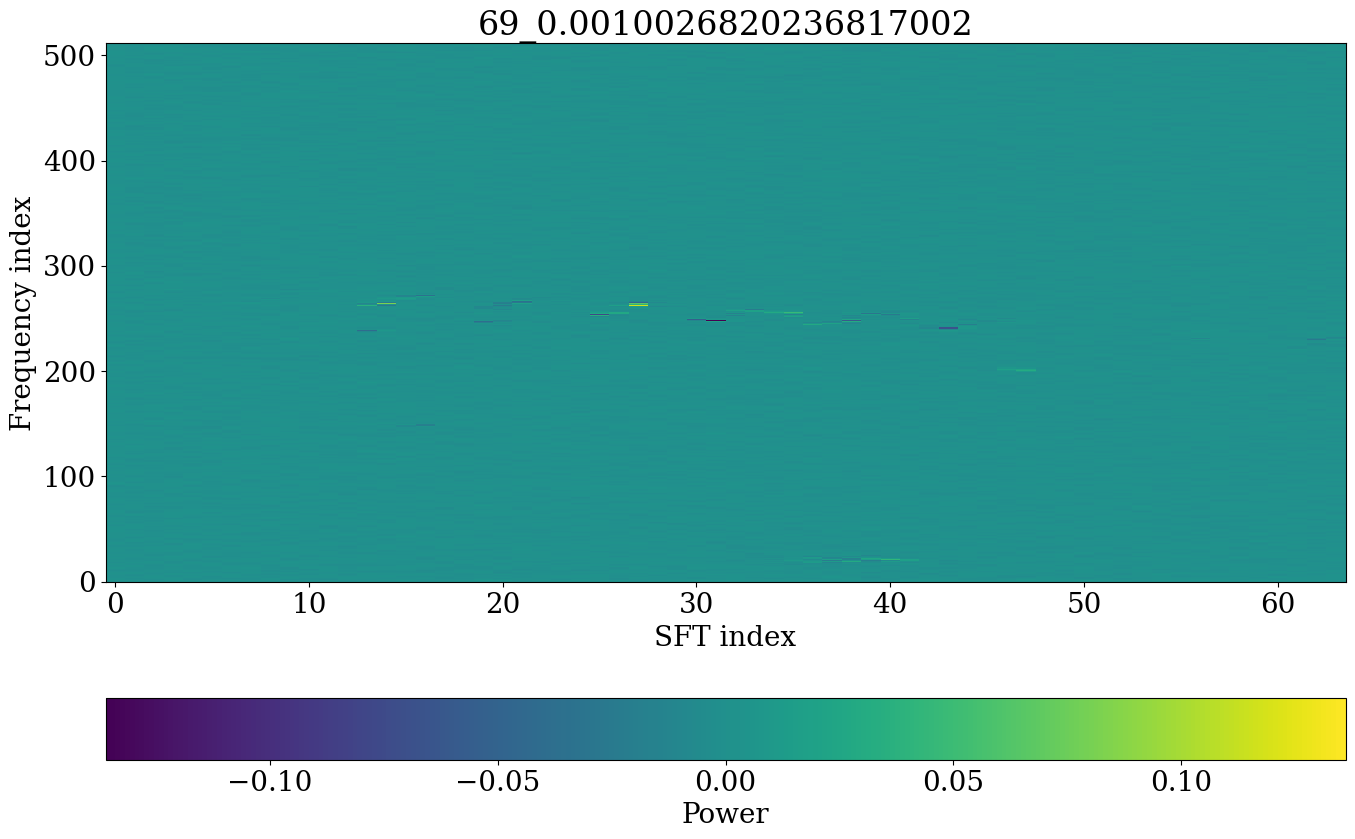

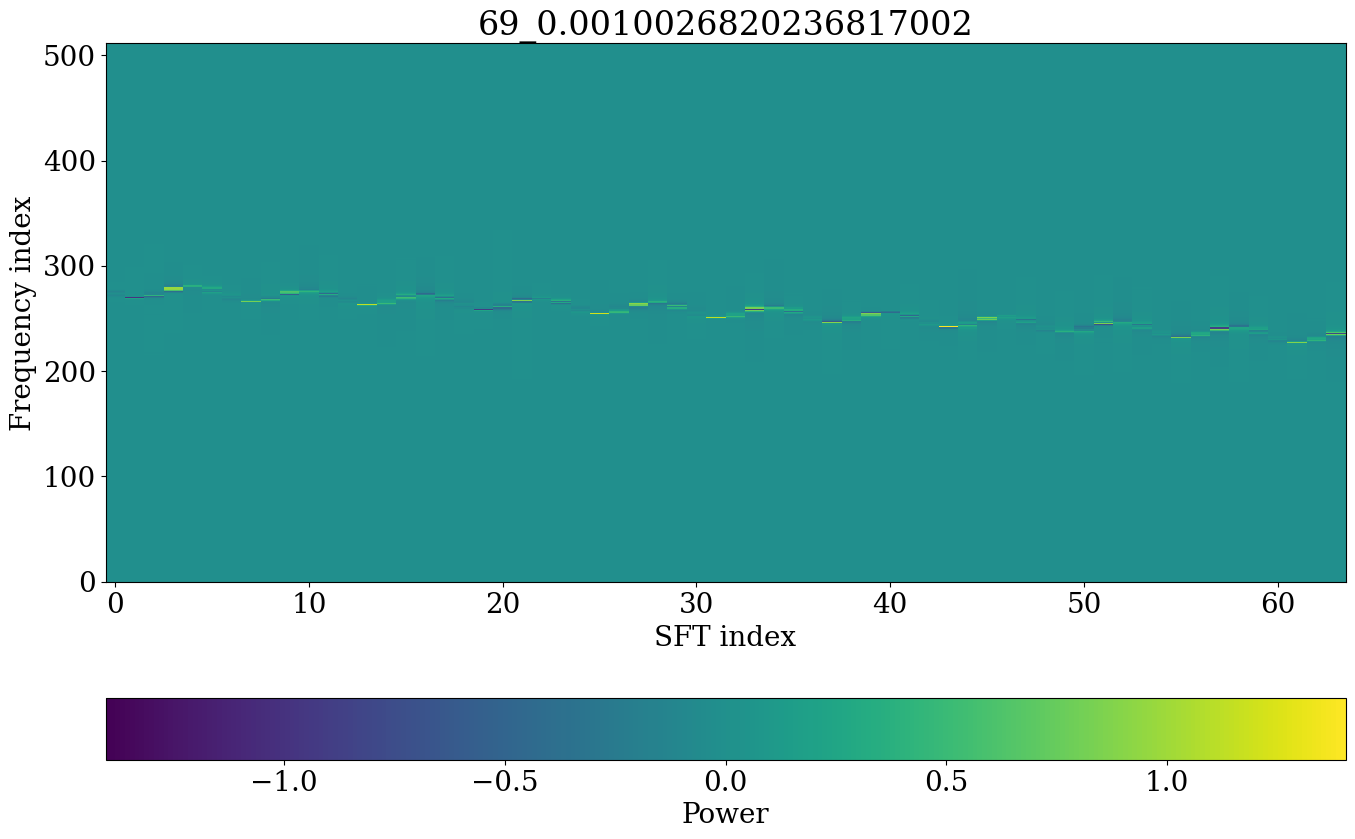

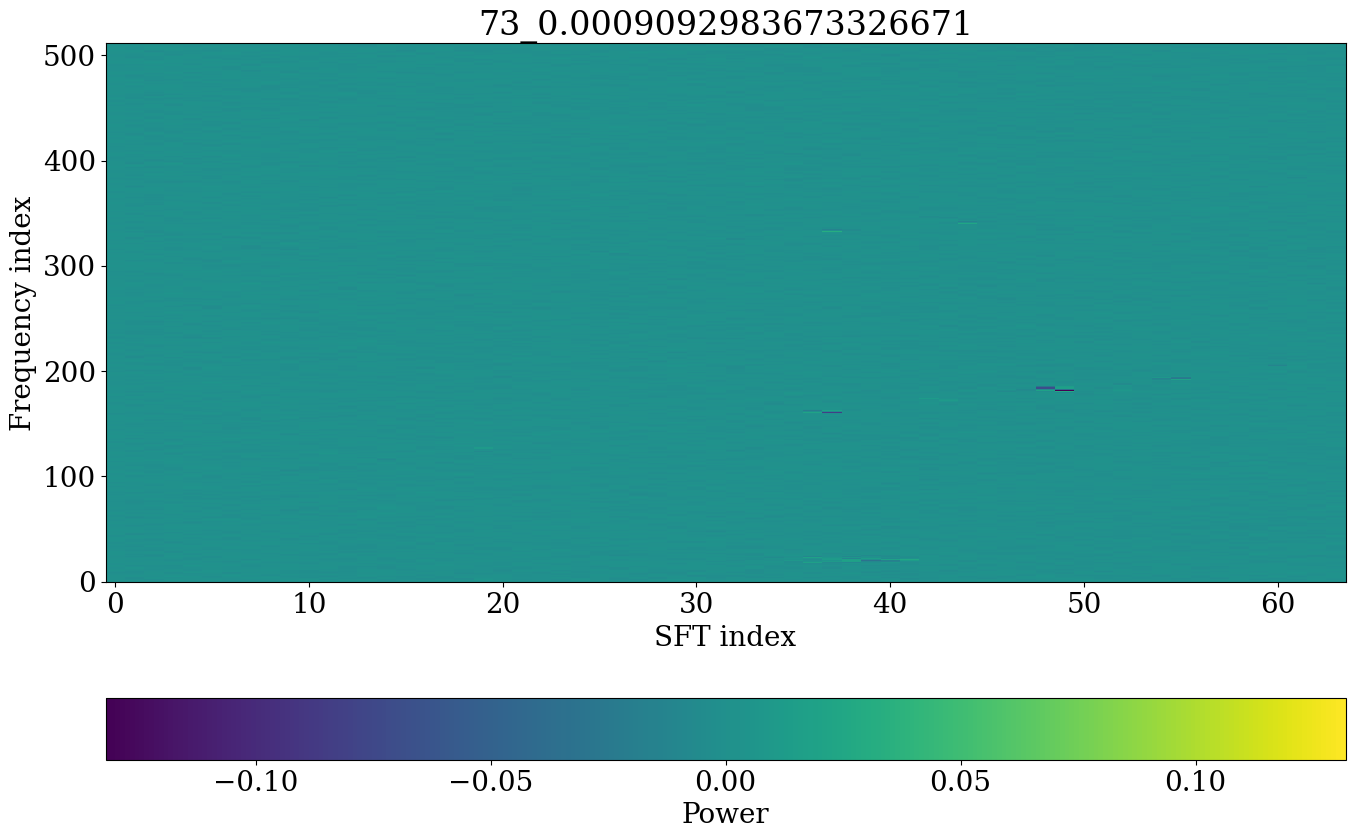

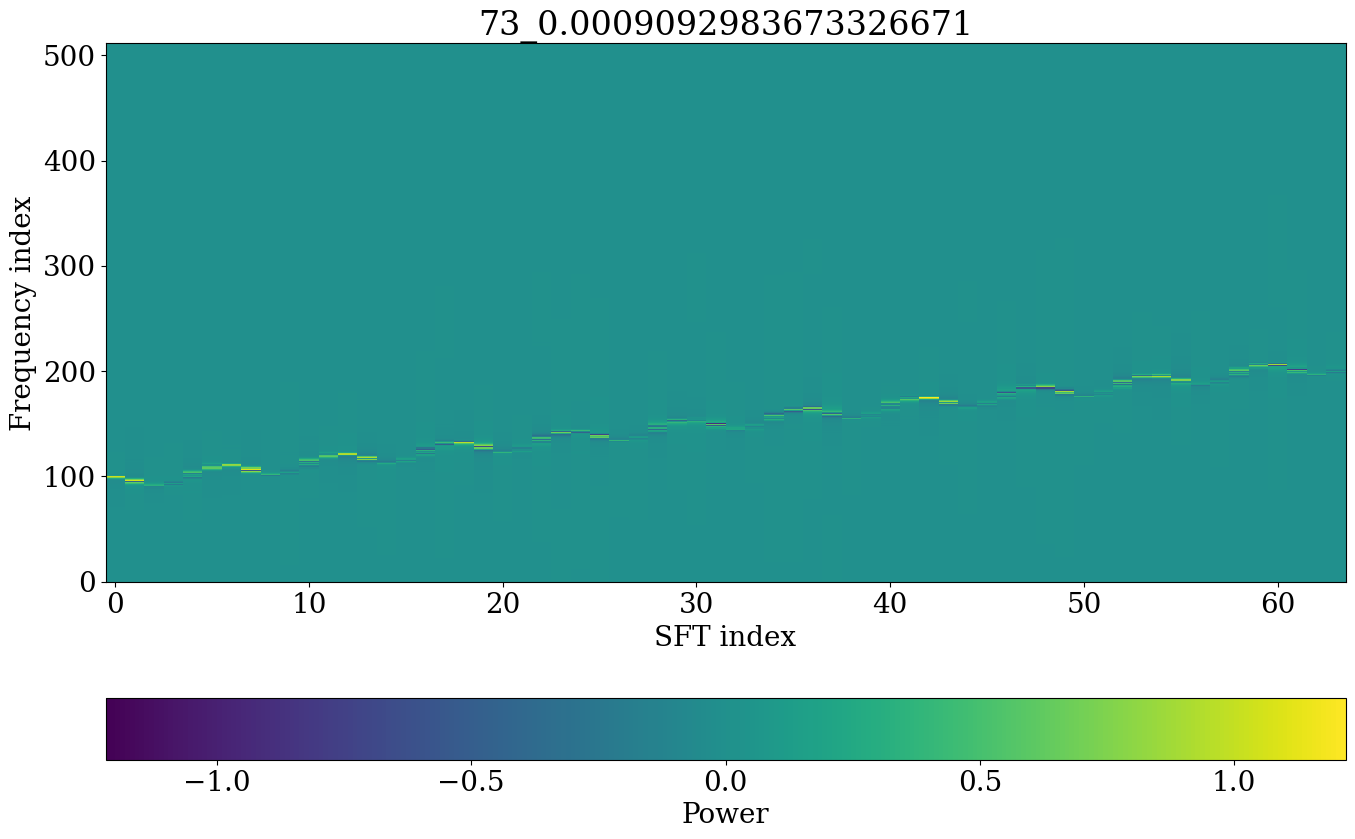

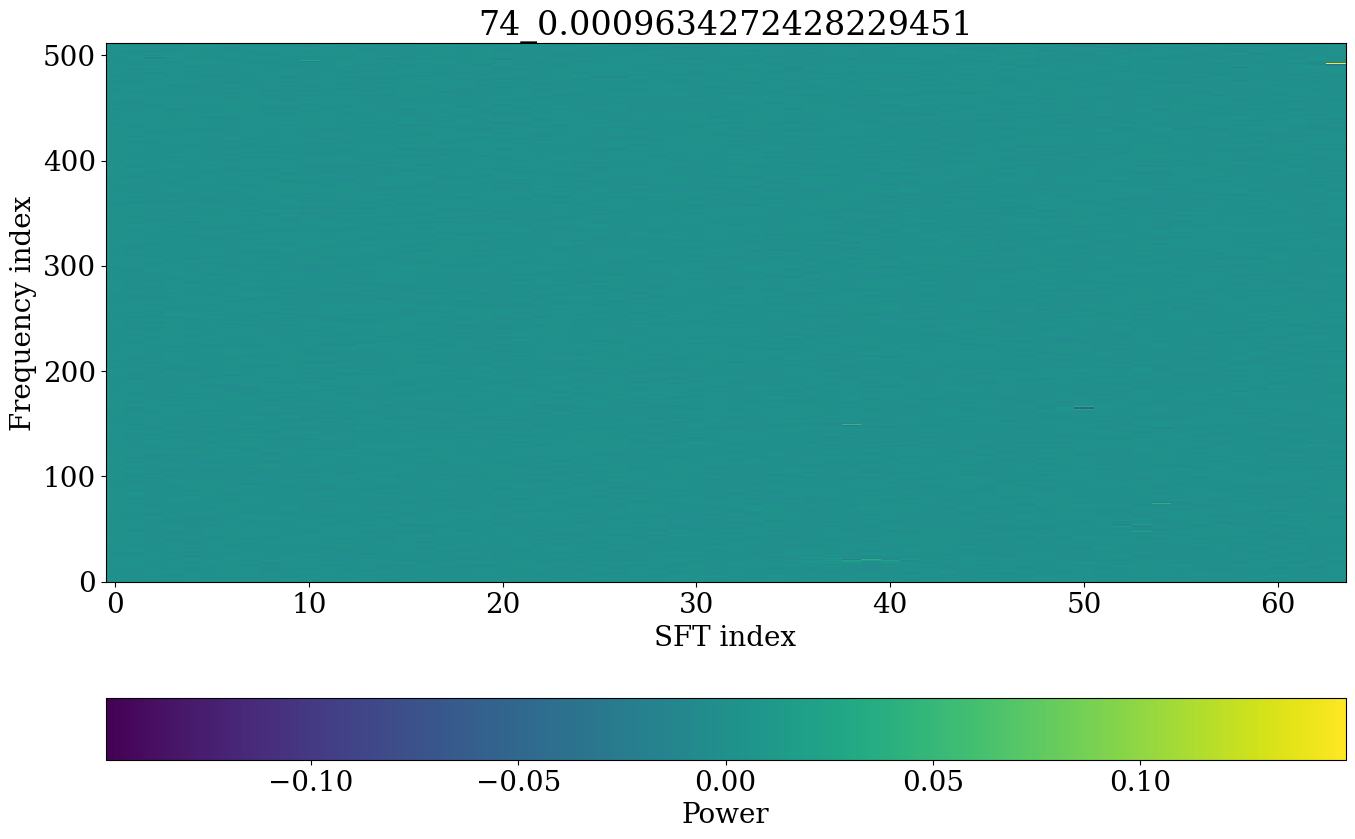

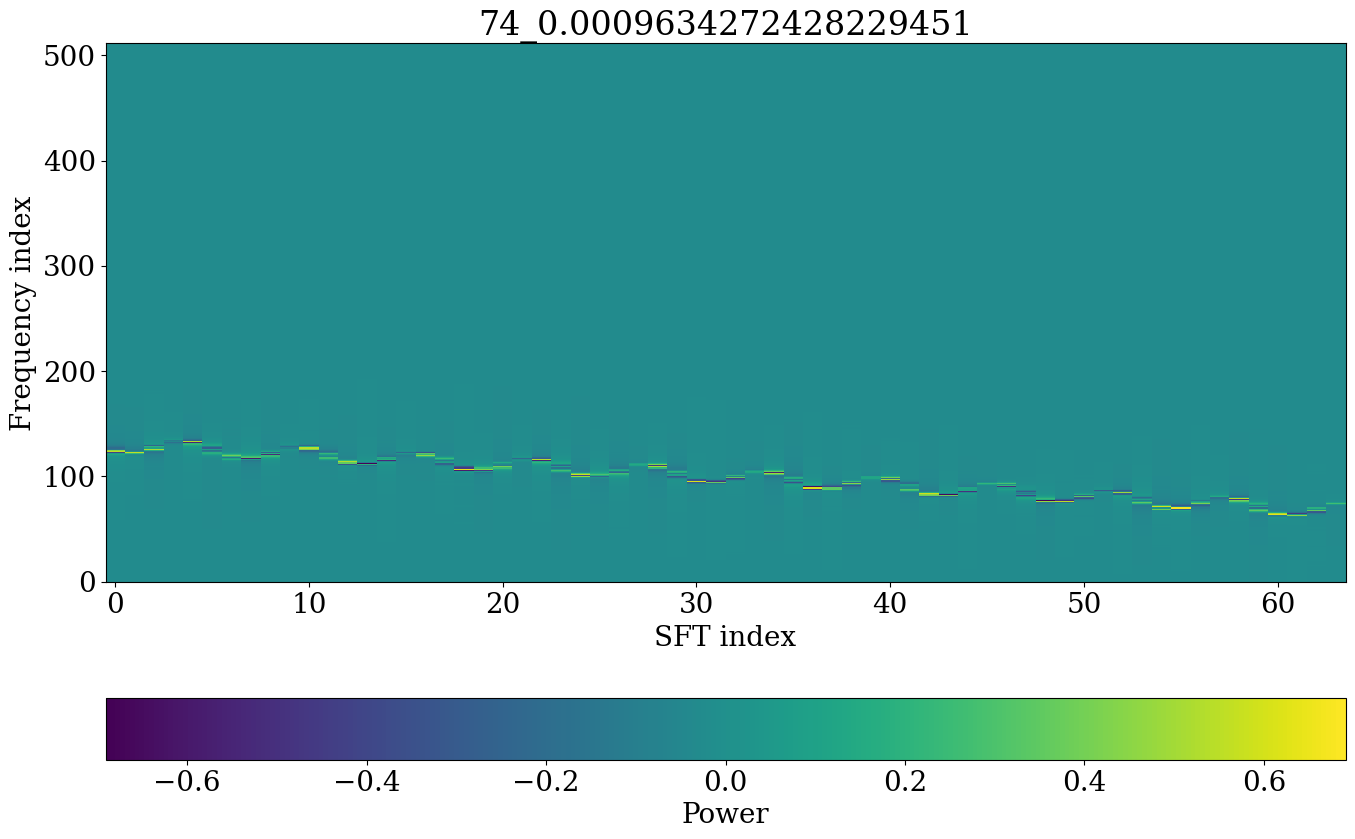

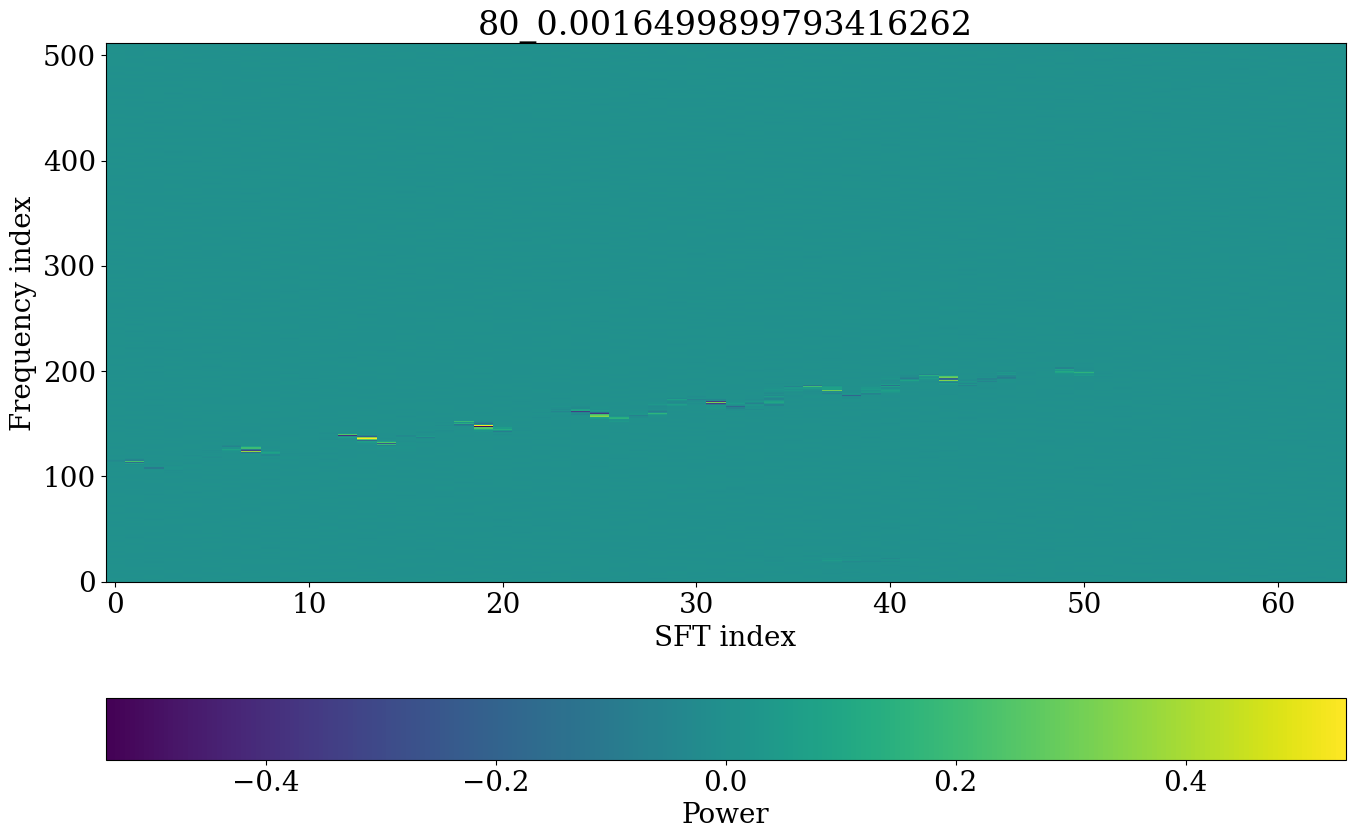

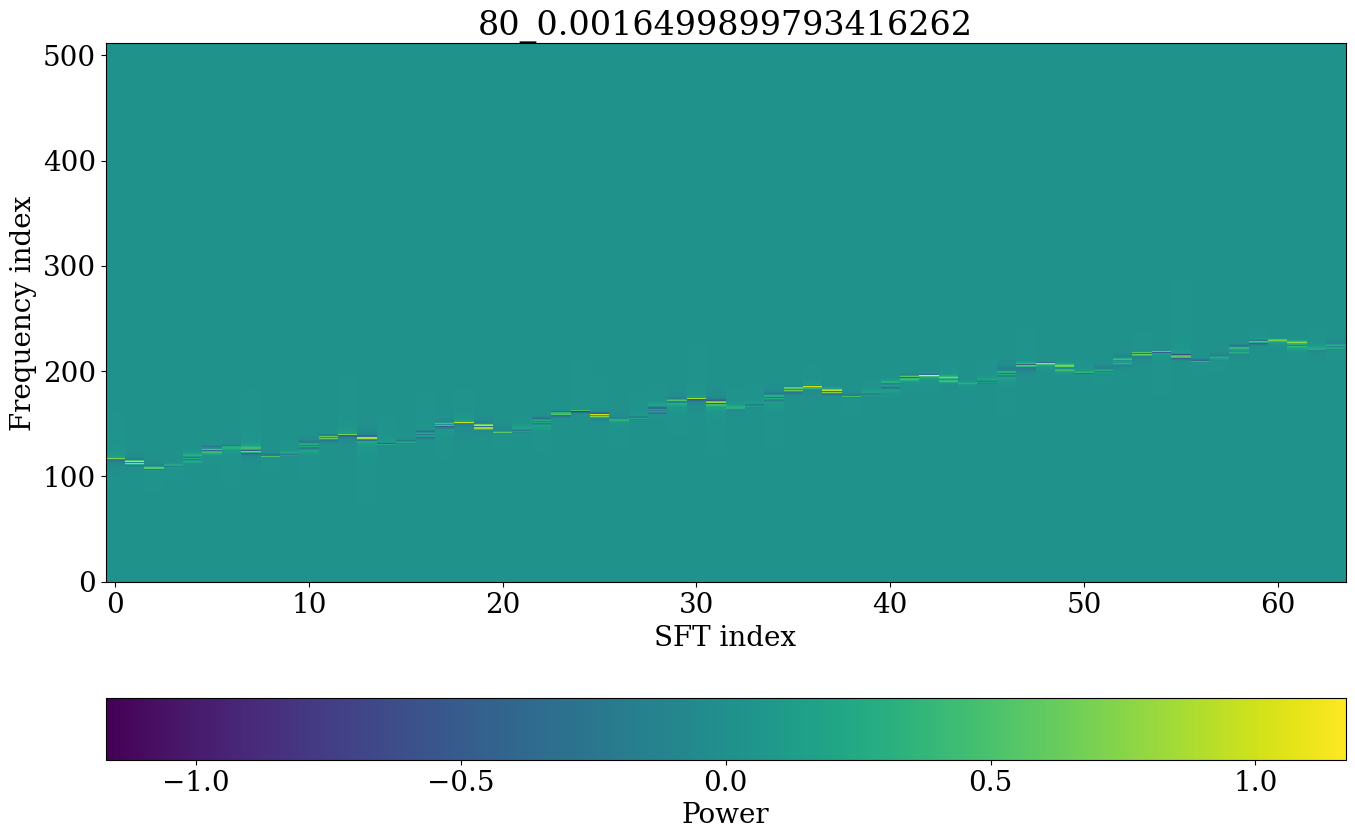

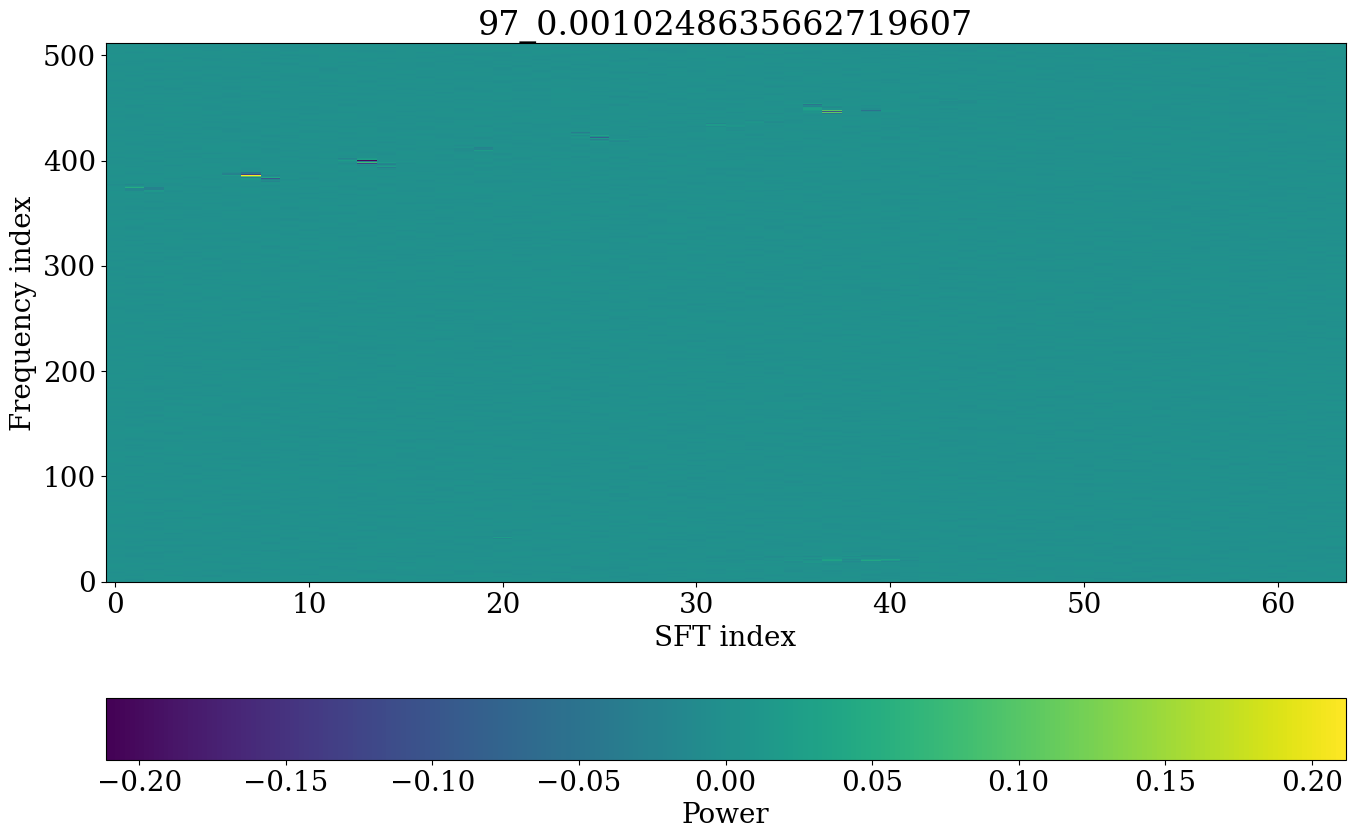

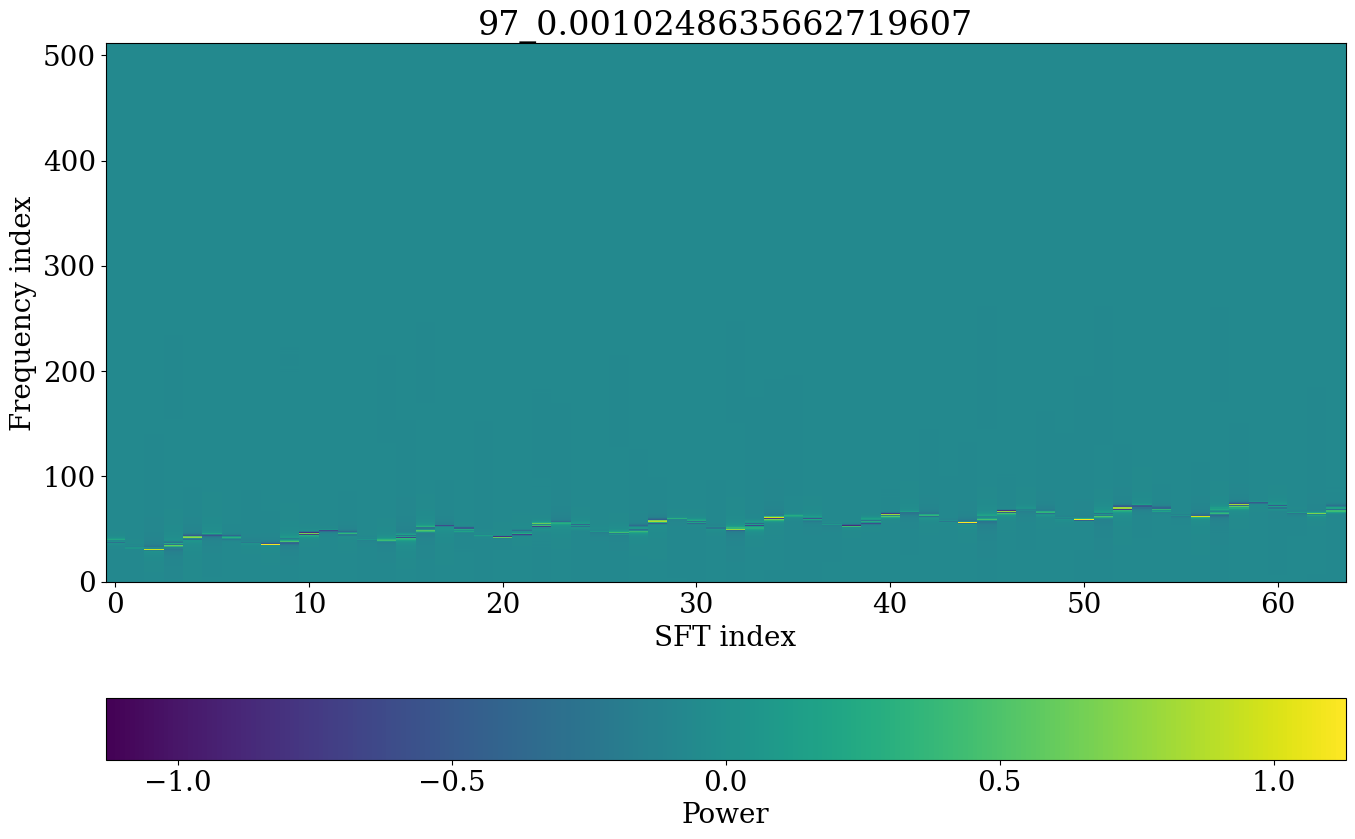

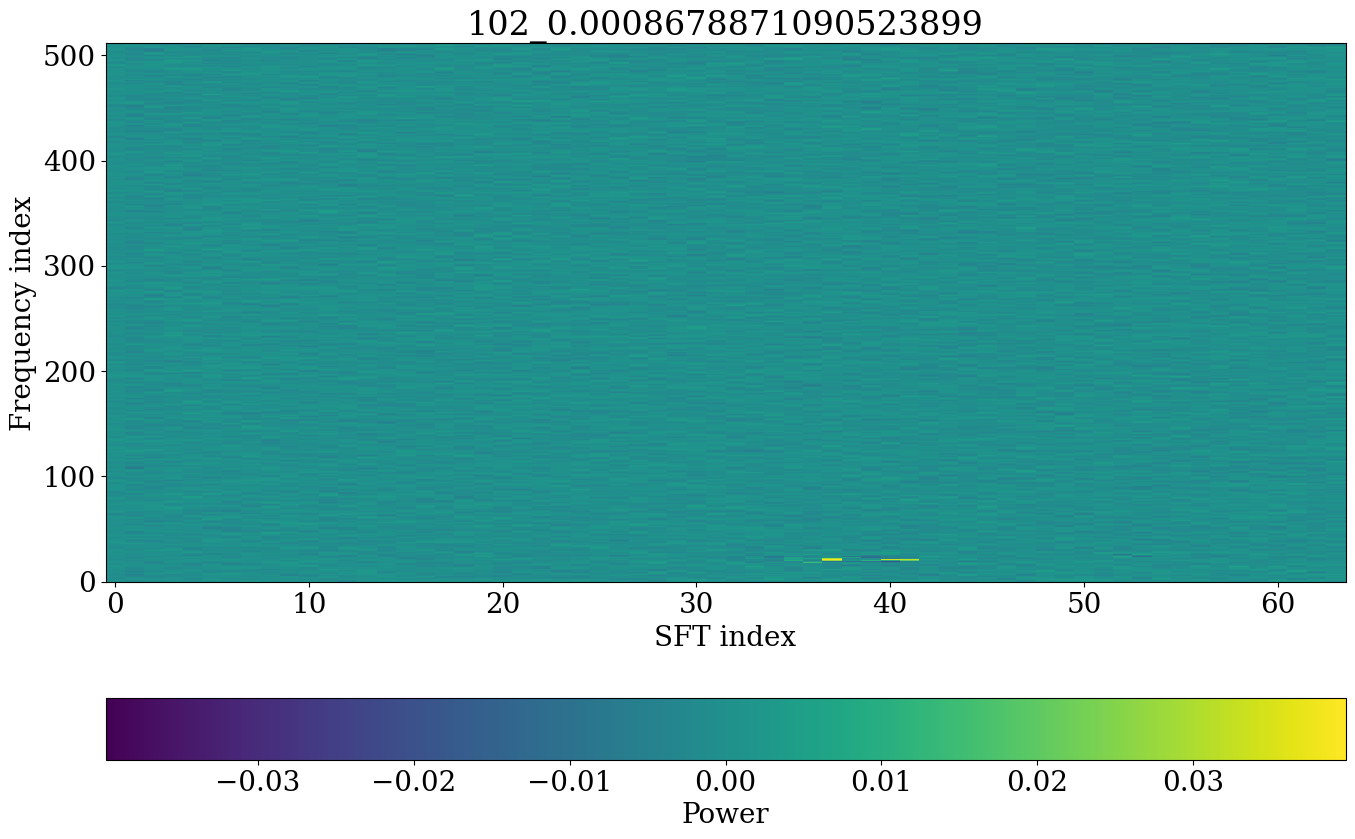

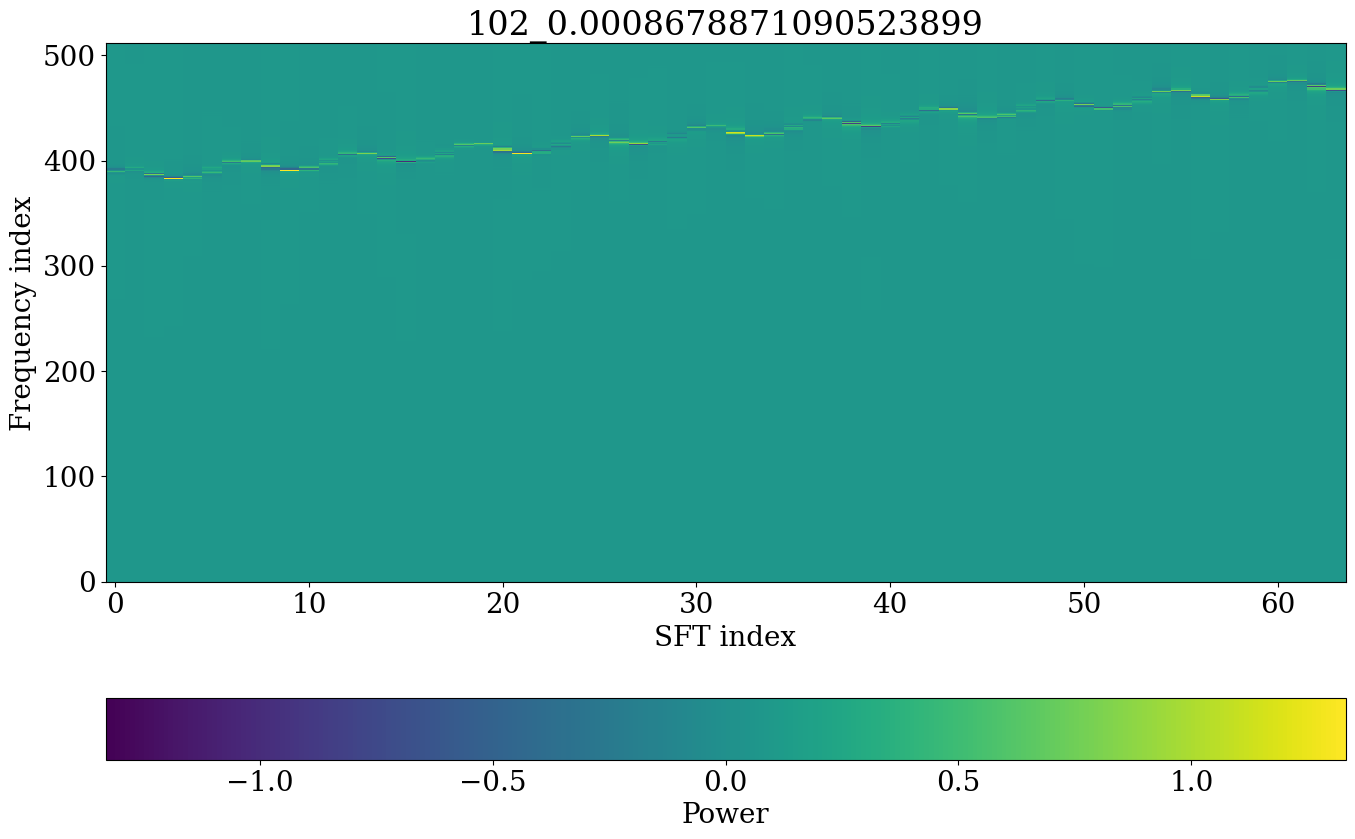

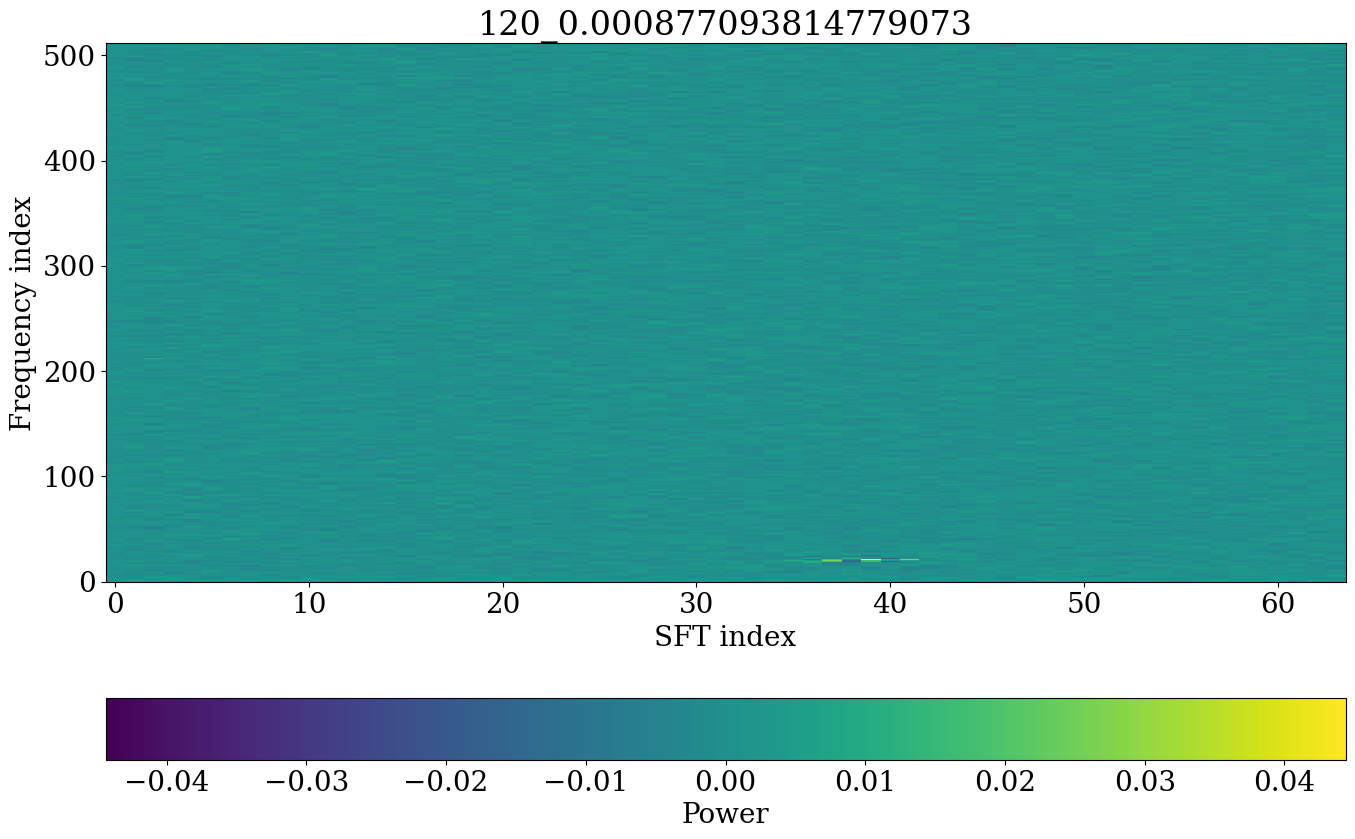

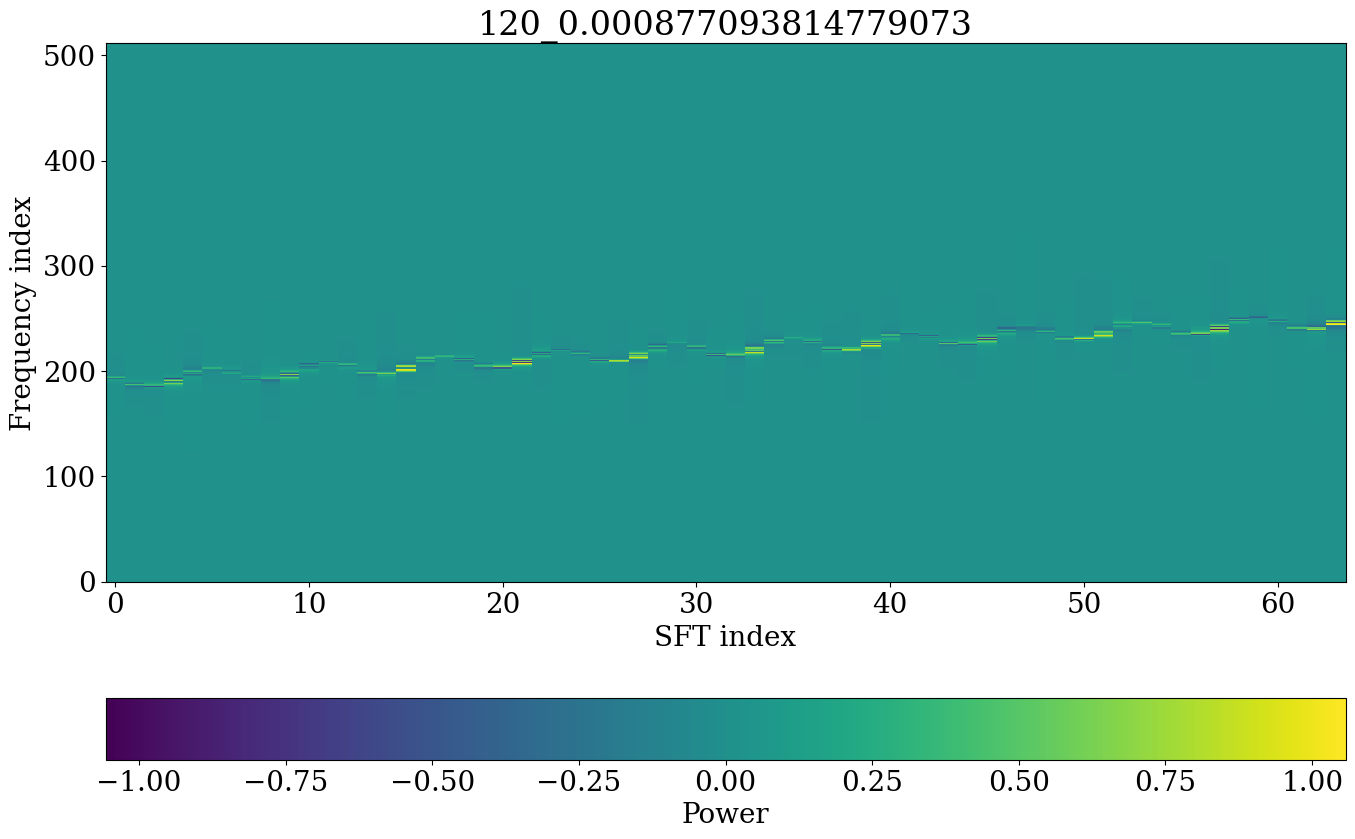

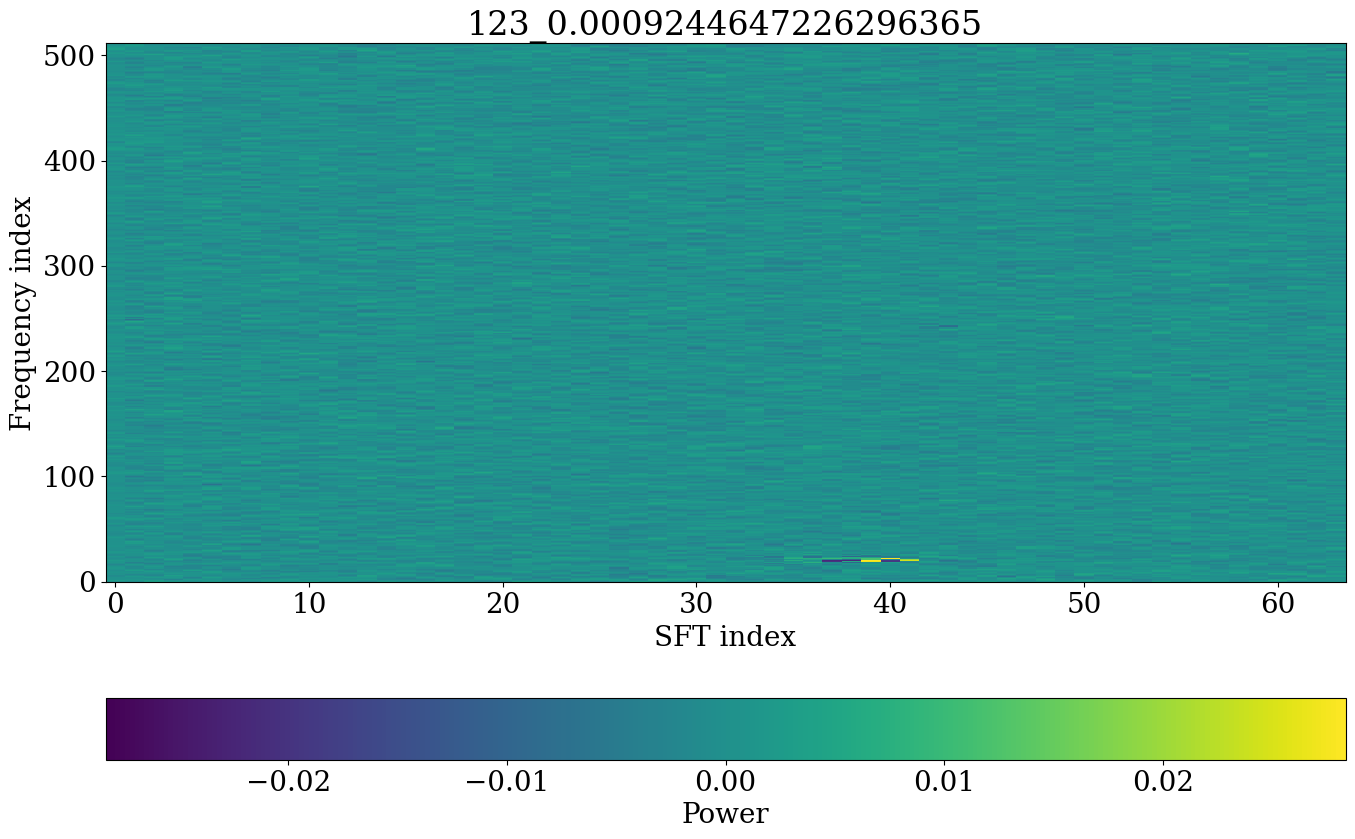

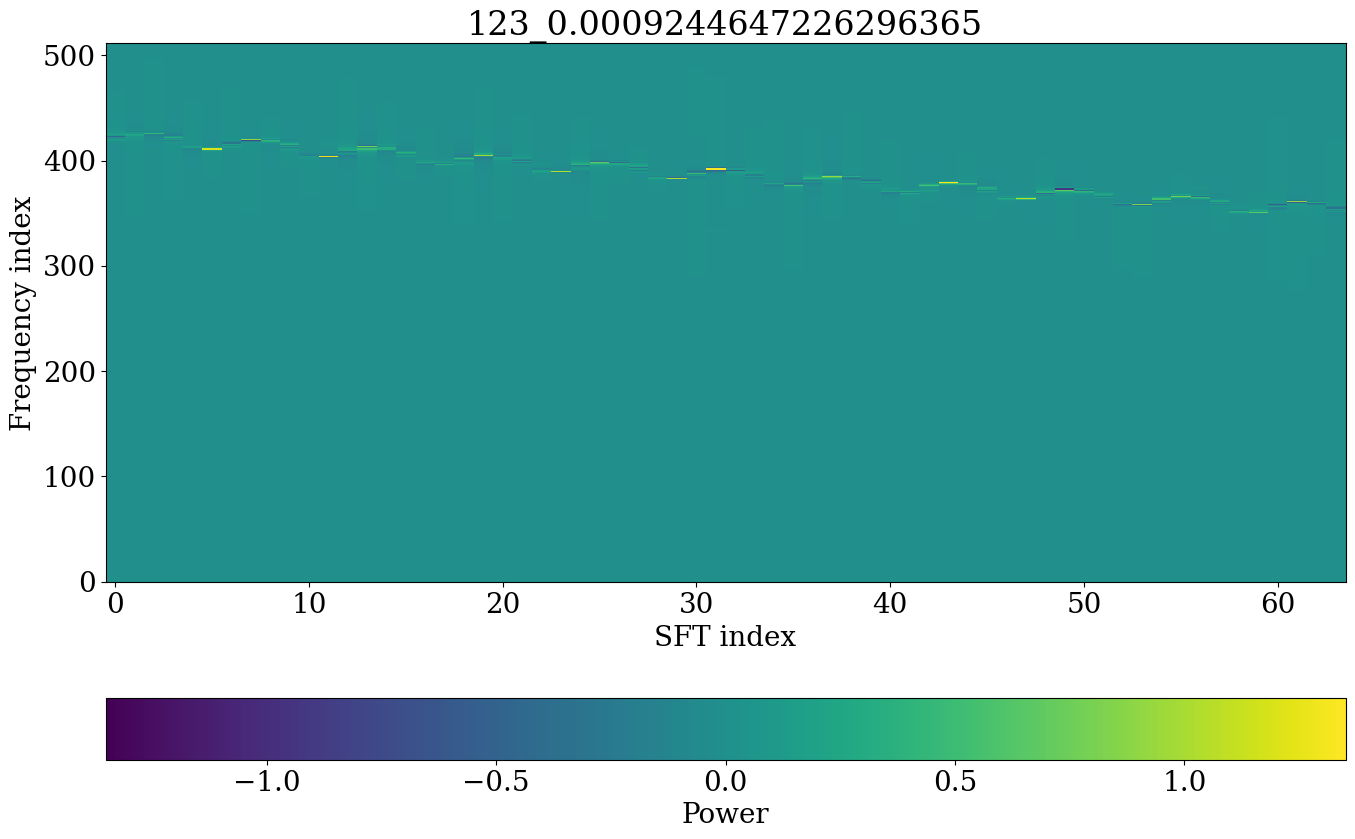

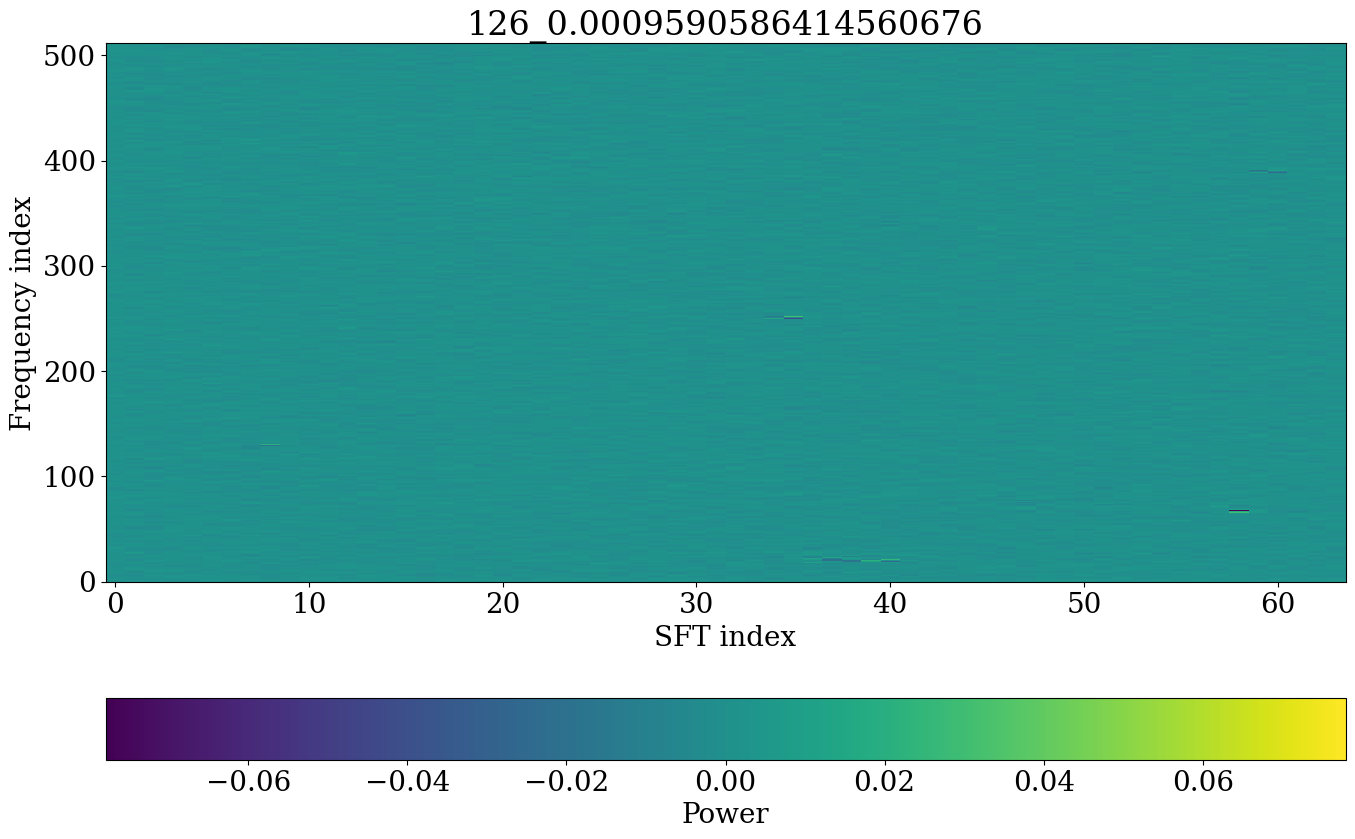

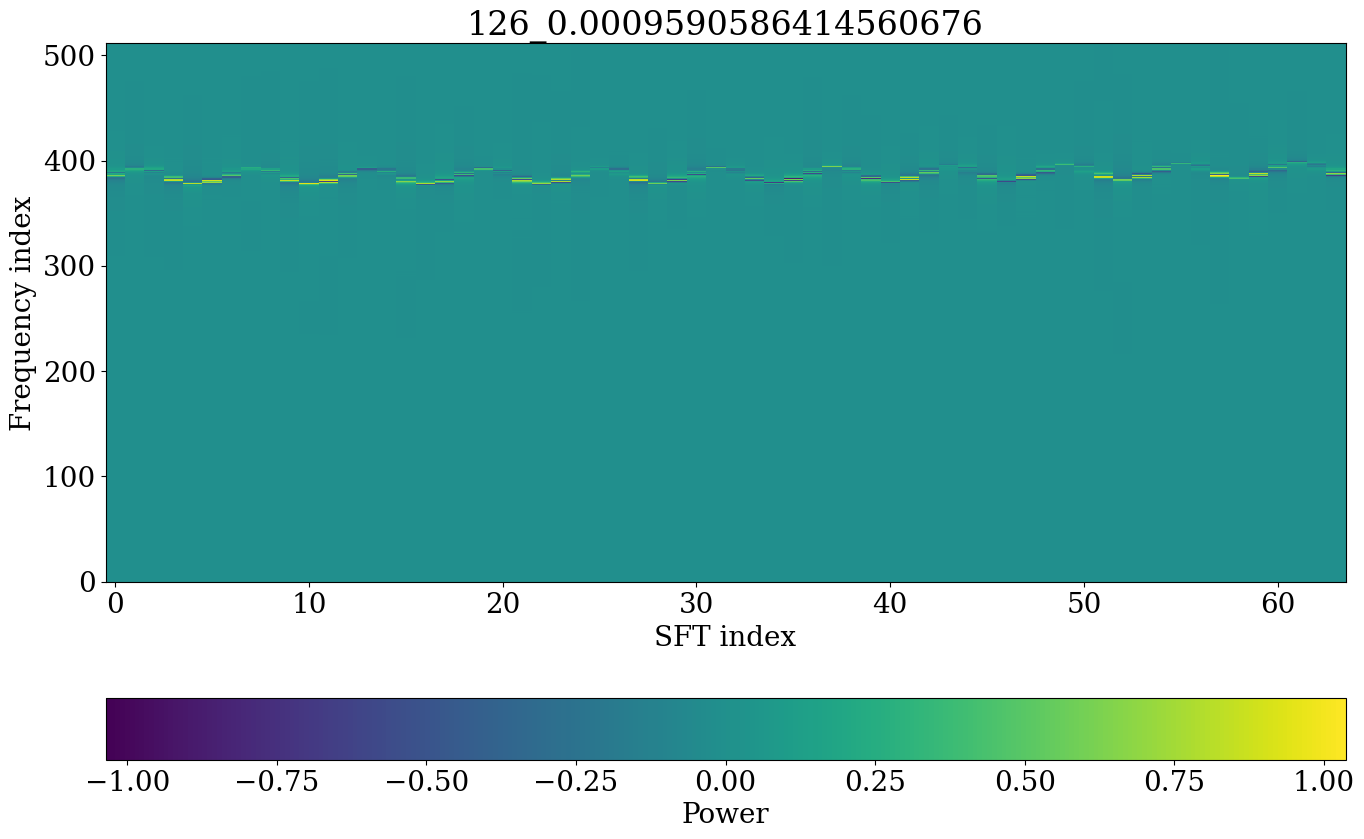

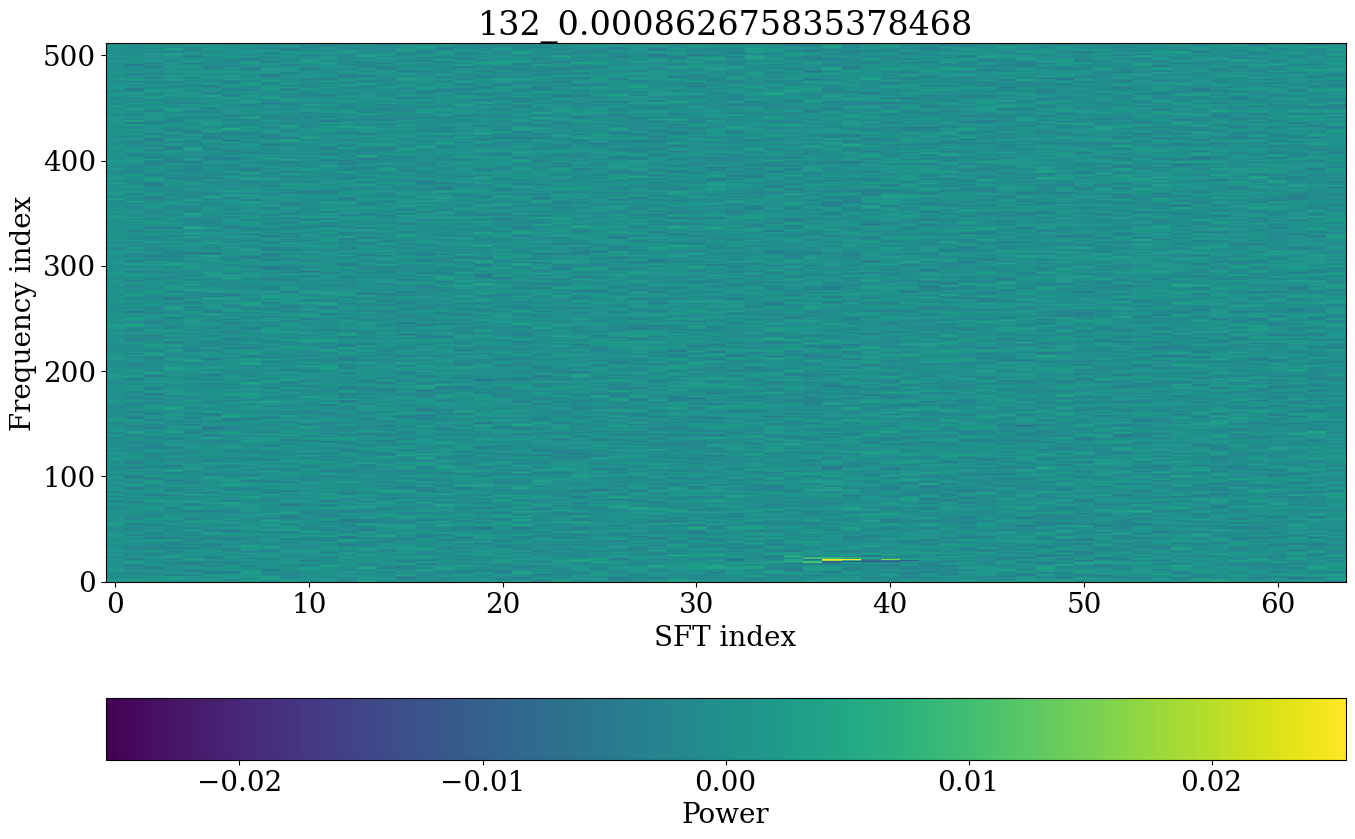

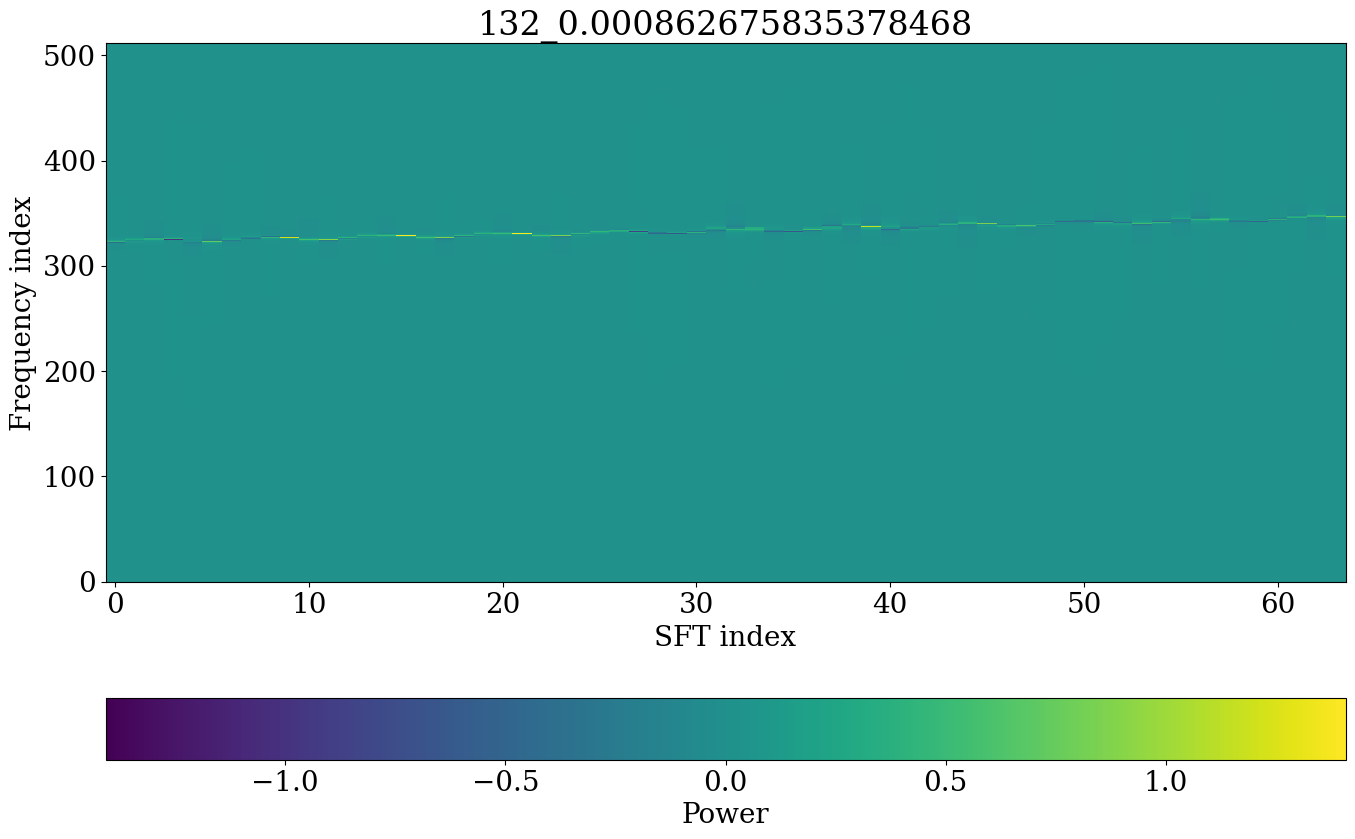

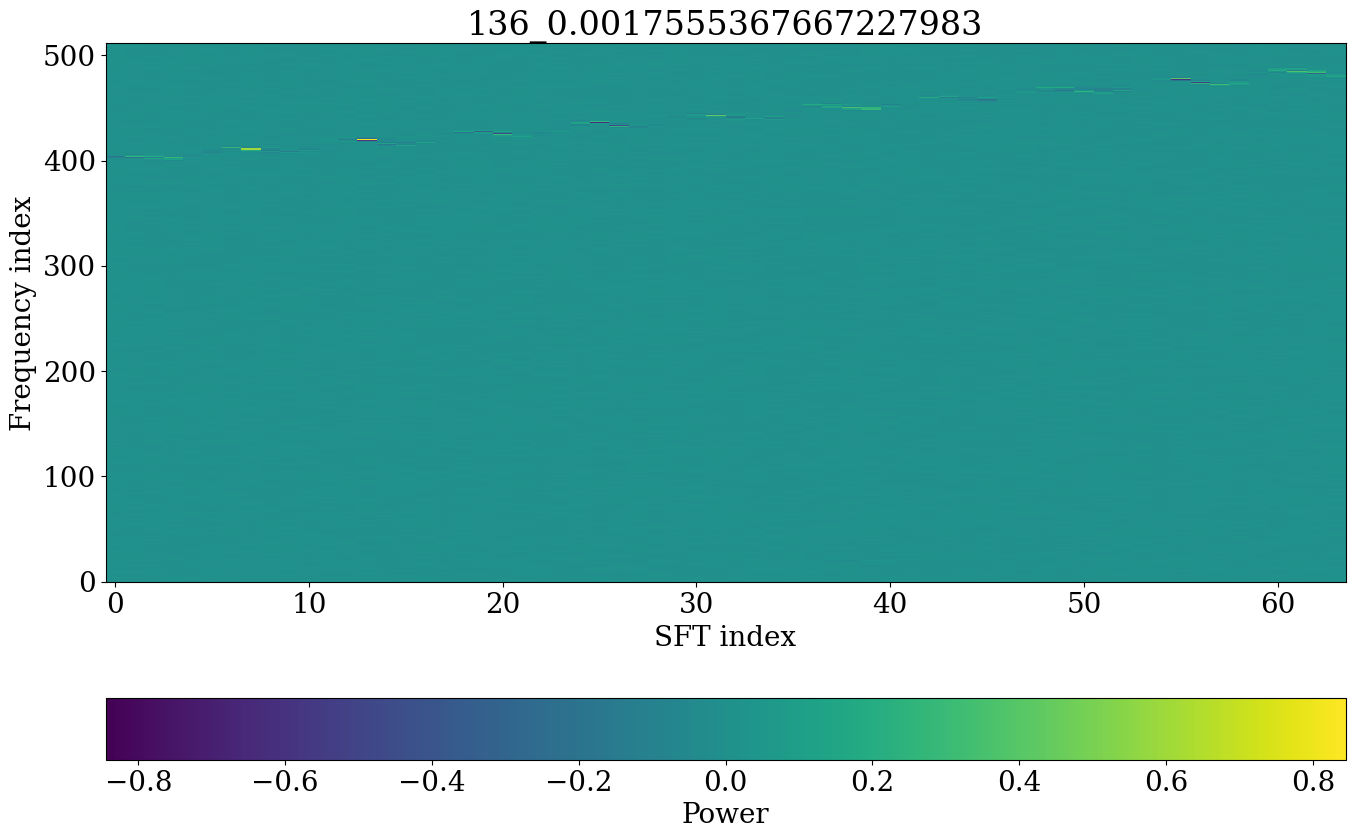

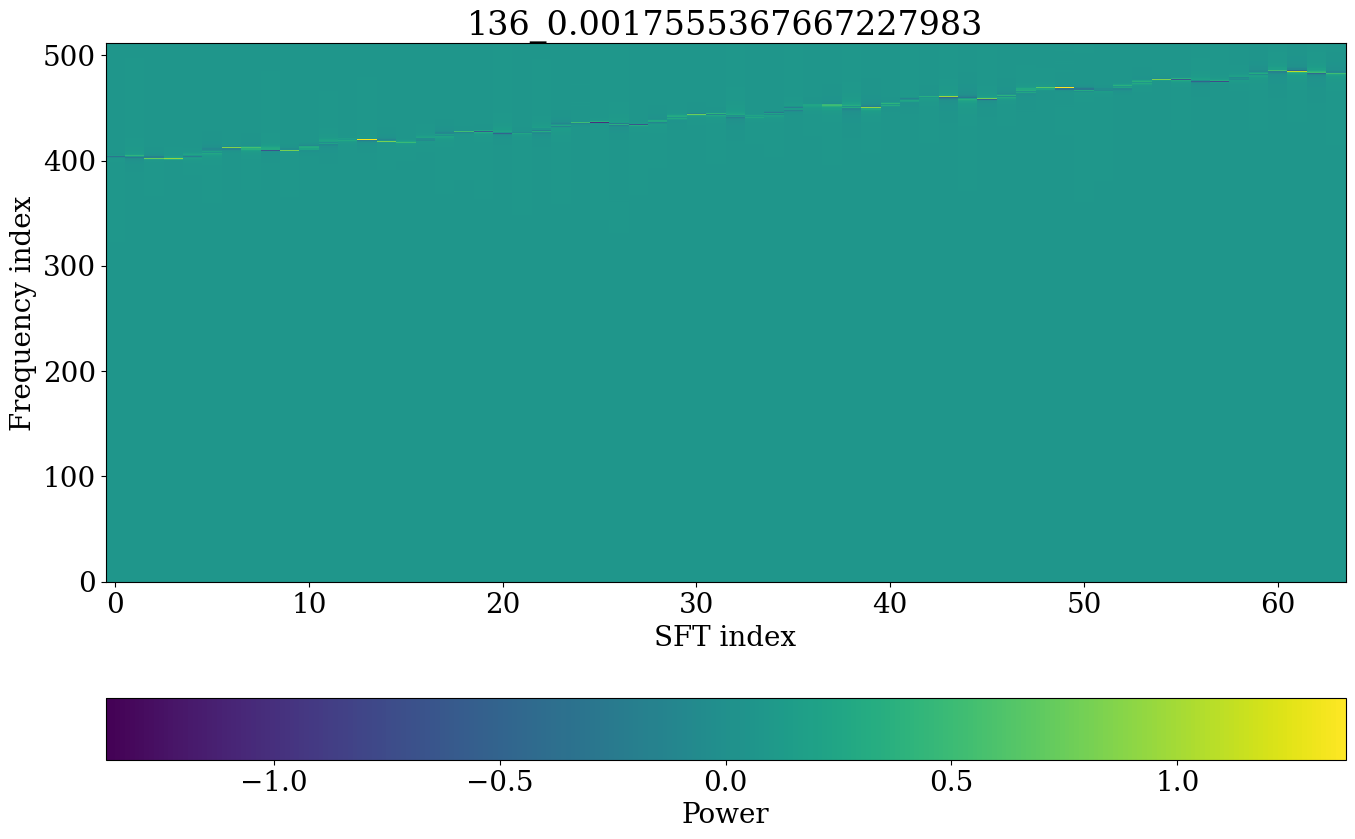

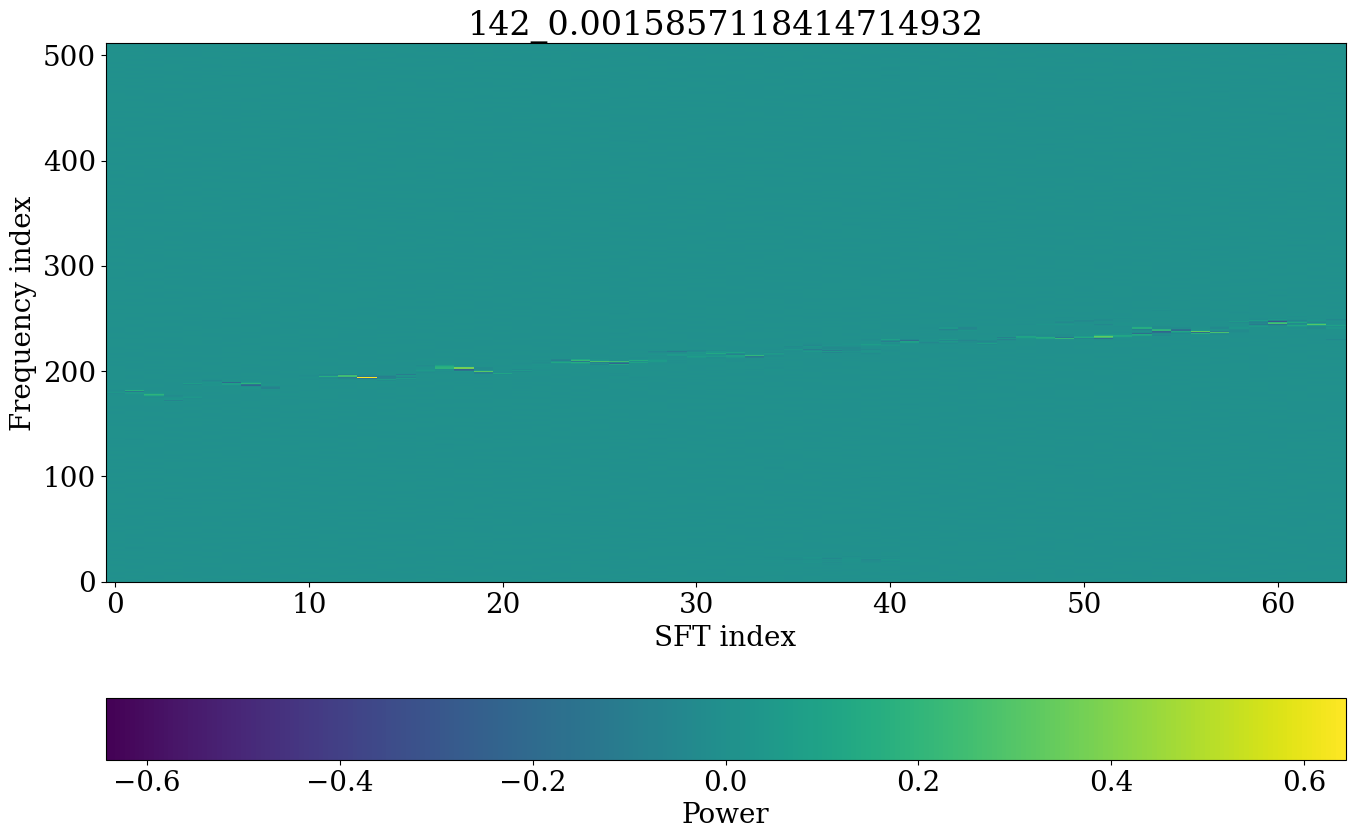

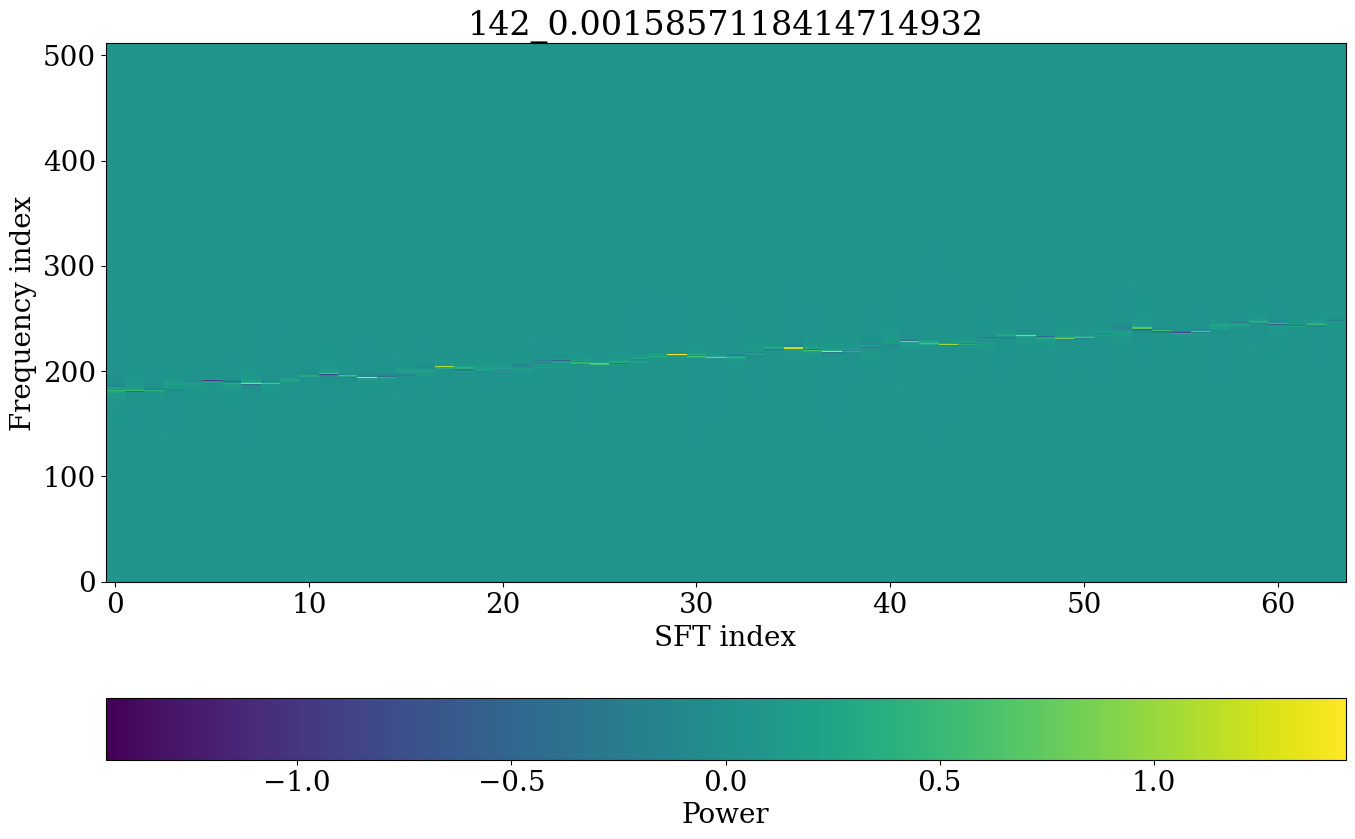

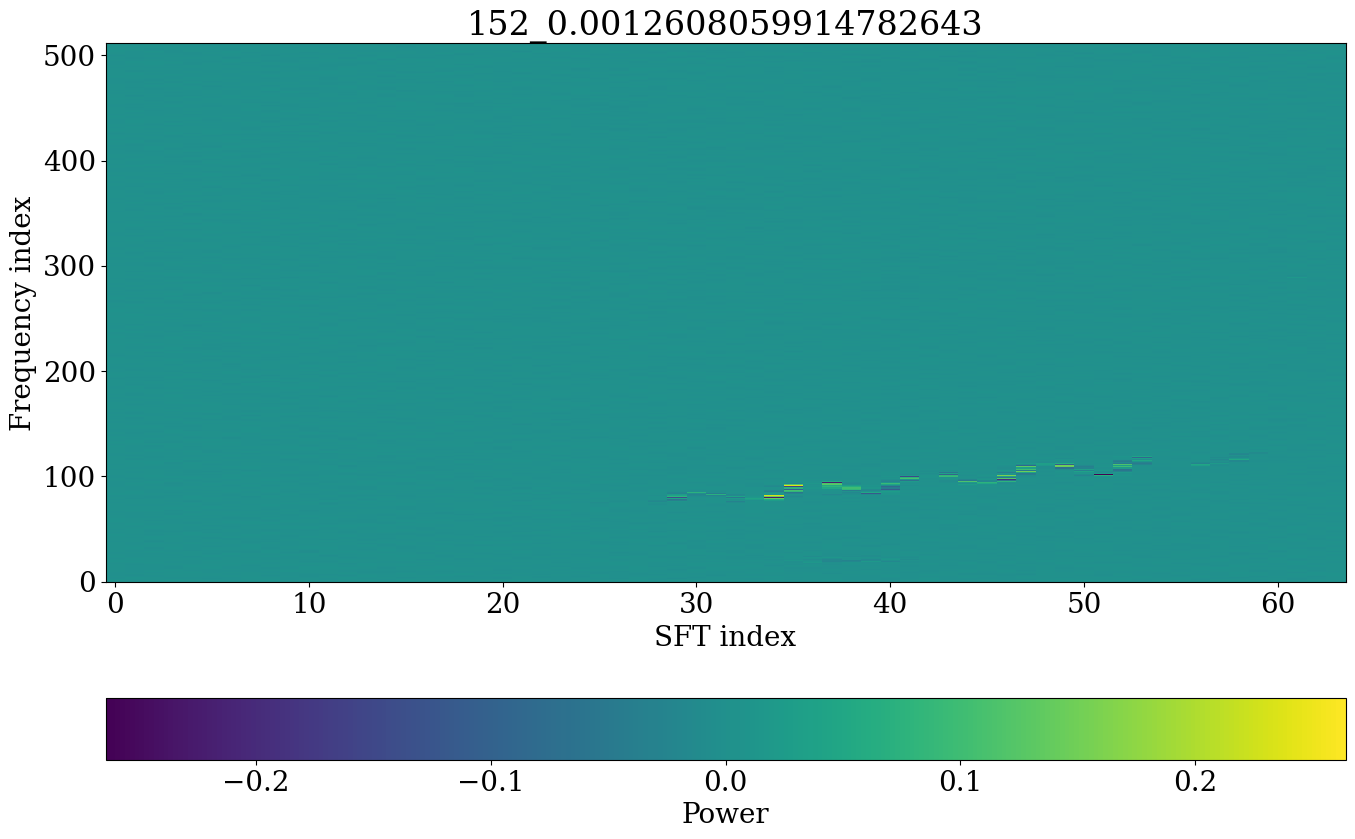

Error in callback <function flush_figures at 0x146eccf83af0> (for post_execute):


KeyboardInterrupt: 

In [10]:
timestamps = np.arange(0, size[1])
frequency = np.arange(0, size[0])

indices = np.where(labels == 20)[0]
stat = results_dict[20]
for i, idx in enumerate(indices):
    title = '{}_{}'.format(i, stat[i])
    #fig, ax = plot_spectrograms(title, timestamps, frequency, inputs[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_input_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_input_{}.png'.format(version))
    #fig, ax = plot_spectrograms(title, timestamps, frequency, predictions[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_pred_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_pred_{}.png'.format(version))
    if (stat[i] - x_pfa)<0:
        fig, ax = plot_spectrograms(title, timestamps, frequency, predictions[idx].transpose(1, 2, 0))
        fig, ax = plot_spectrograms(title, timestamps, frequency, ground_truth[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_target_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_target_{}.png'.format(version))

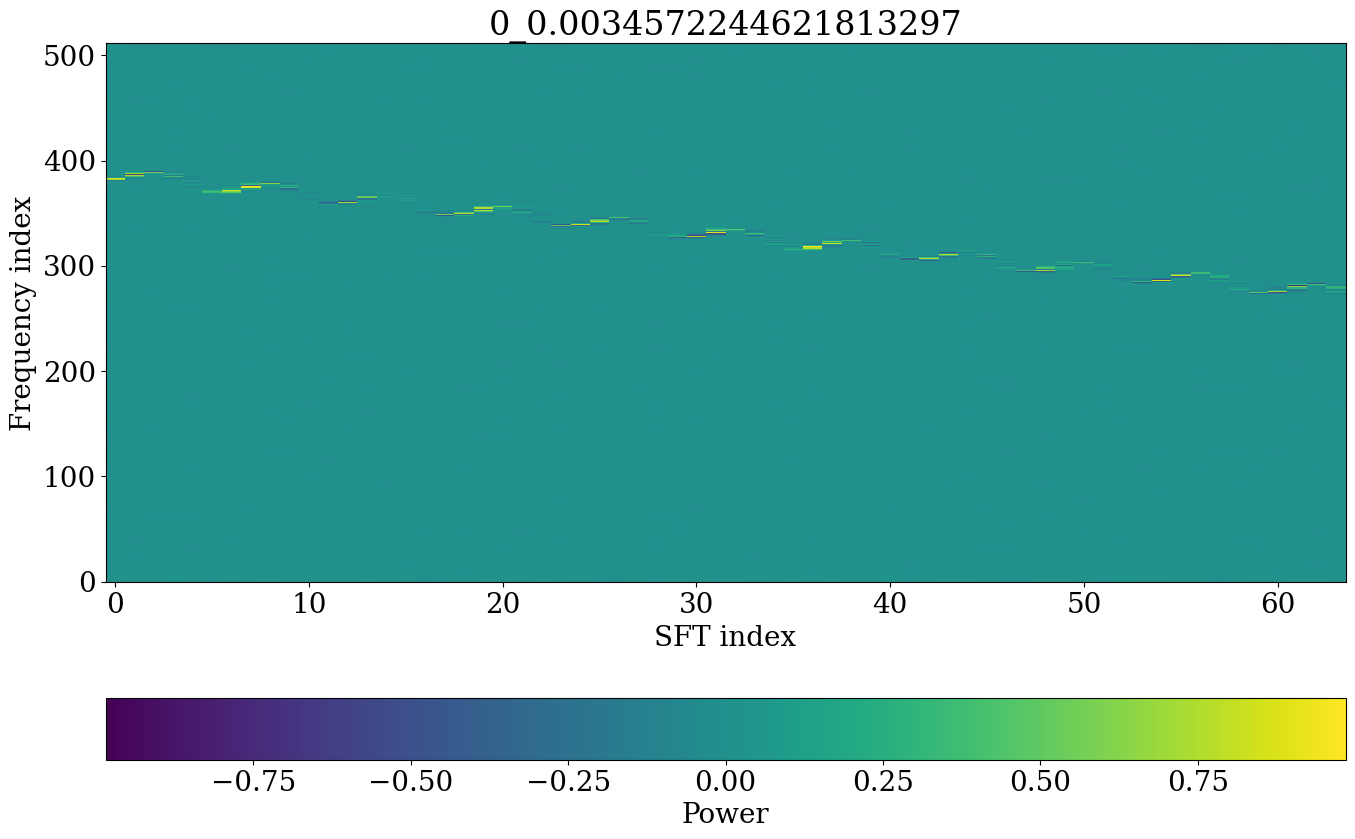

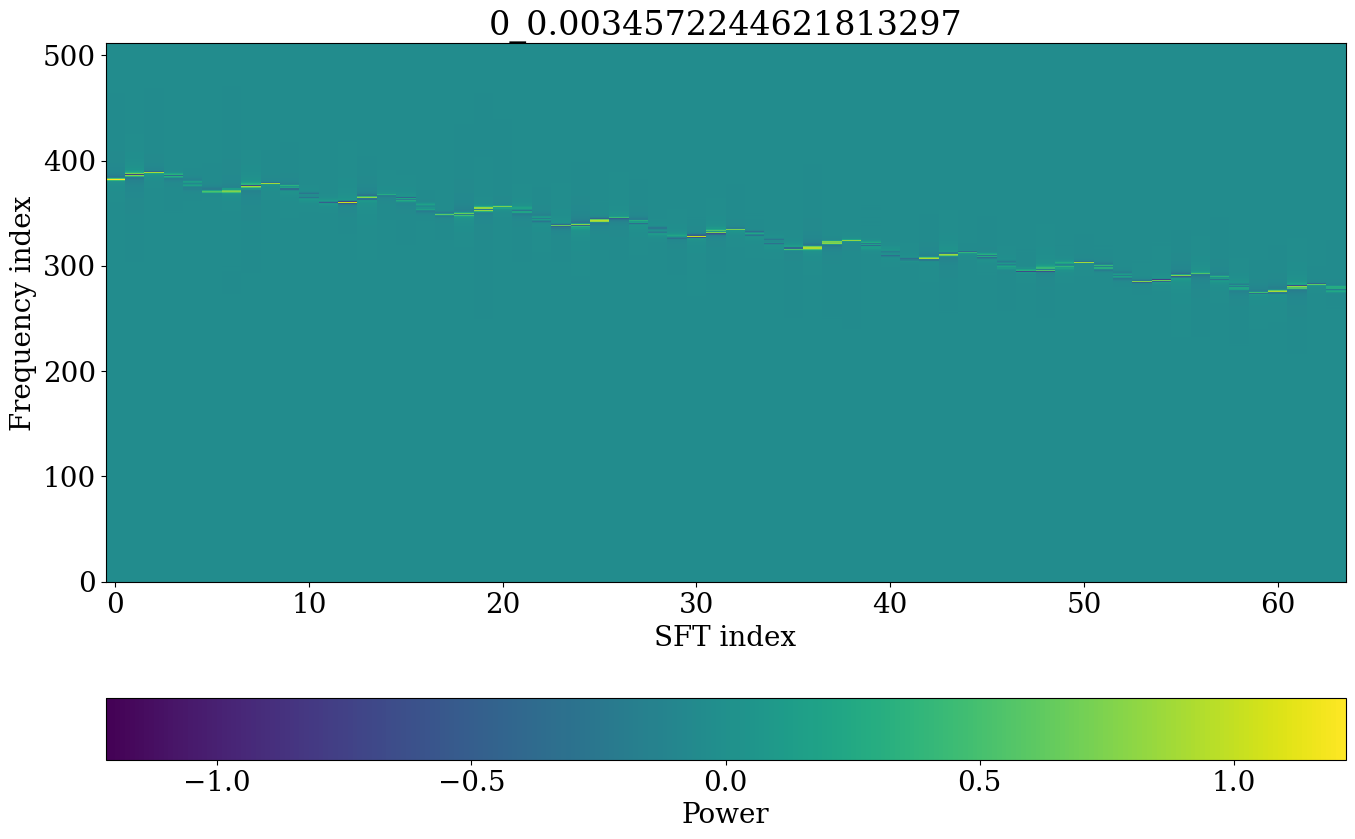

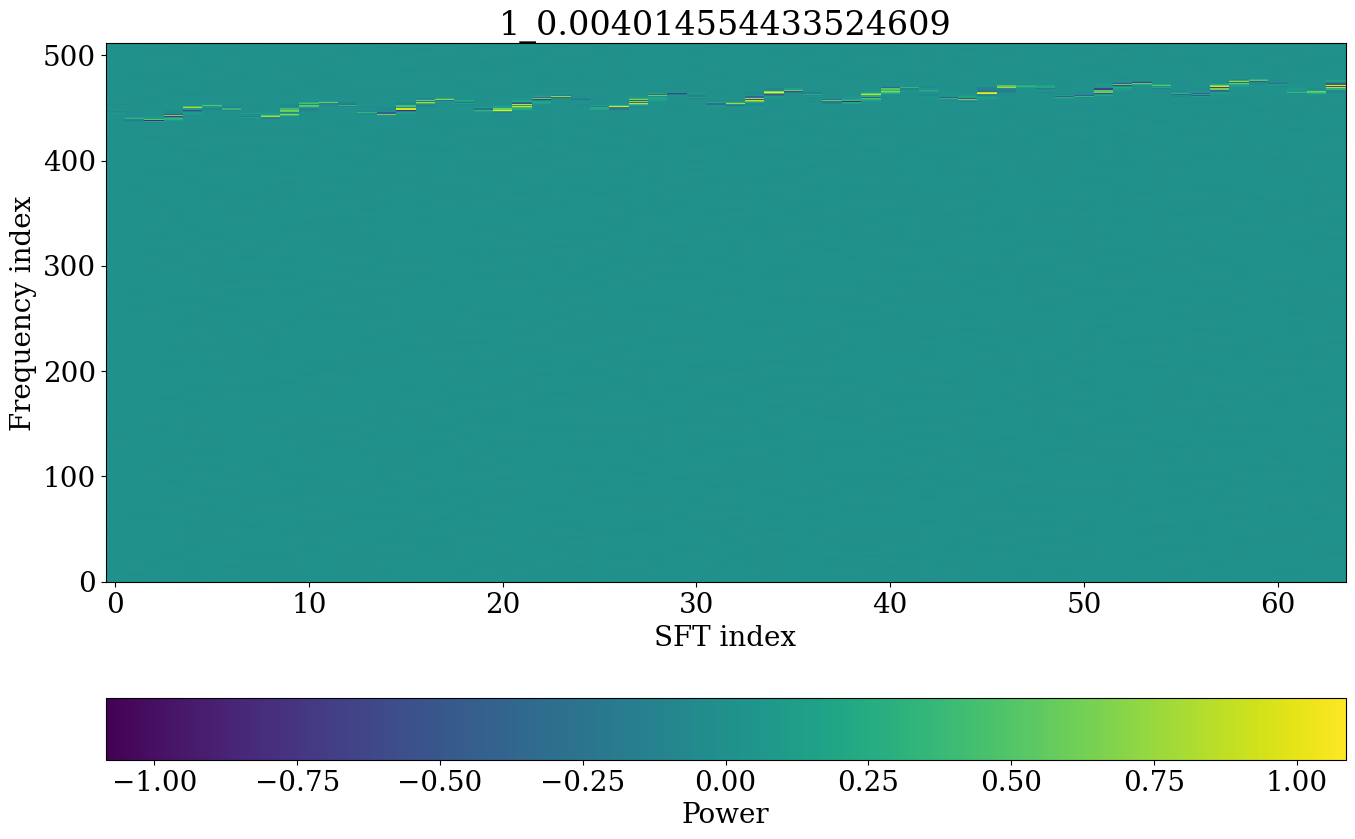

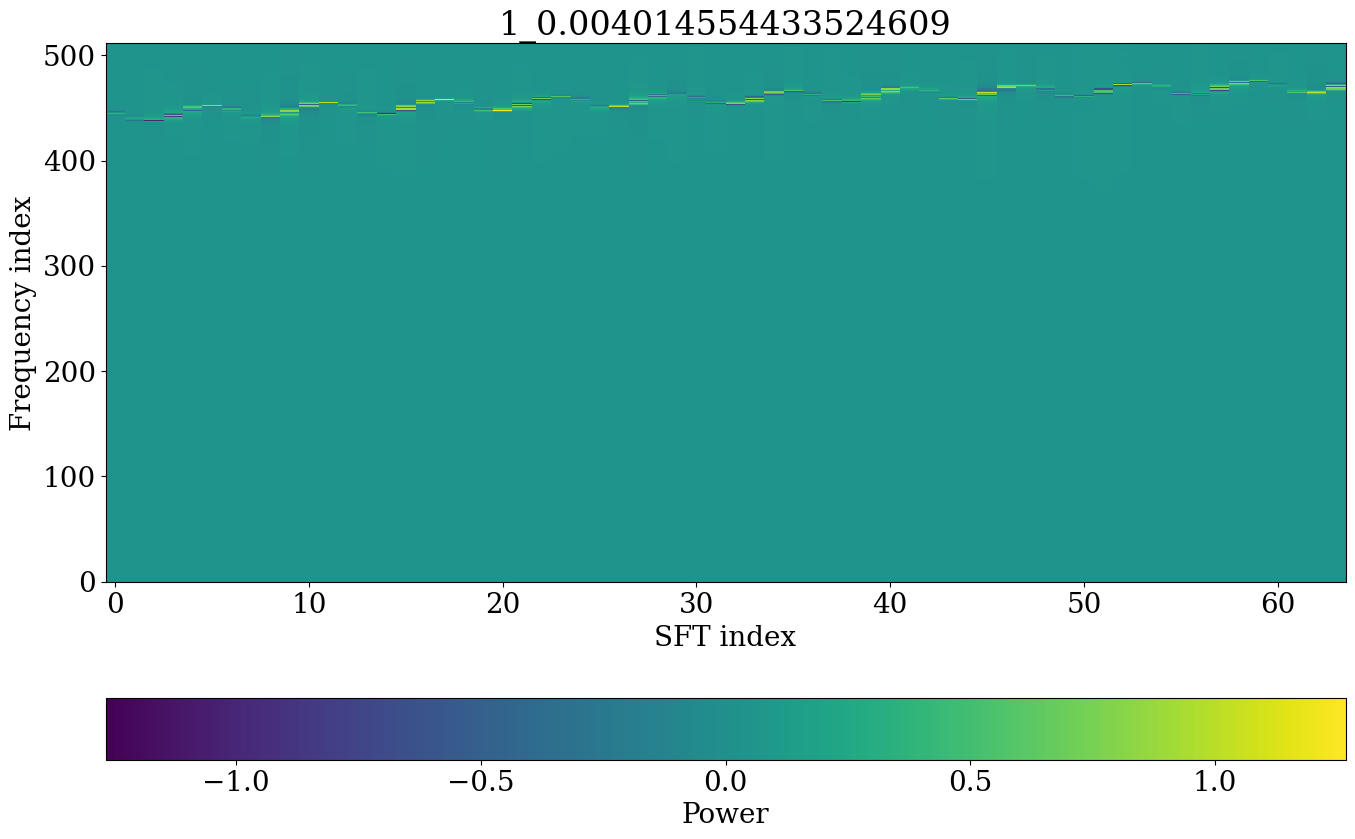

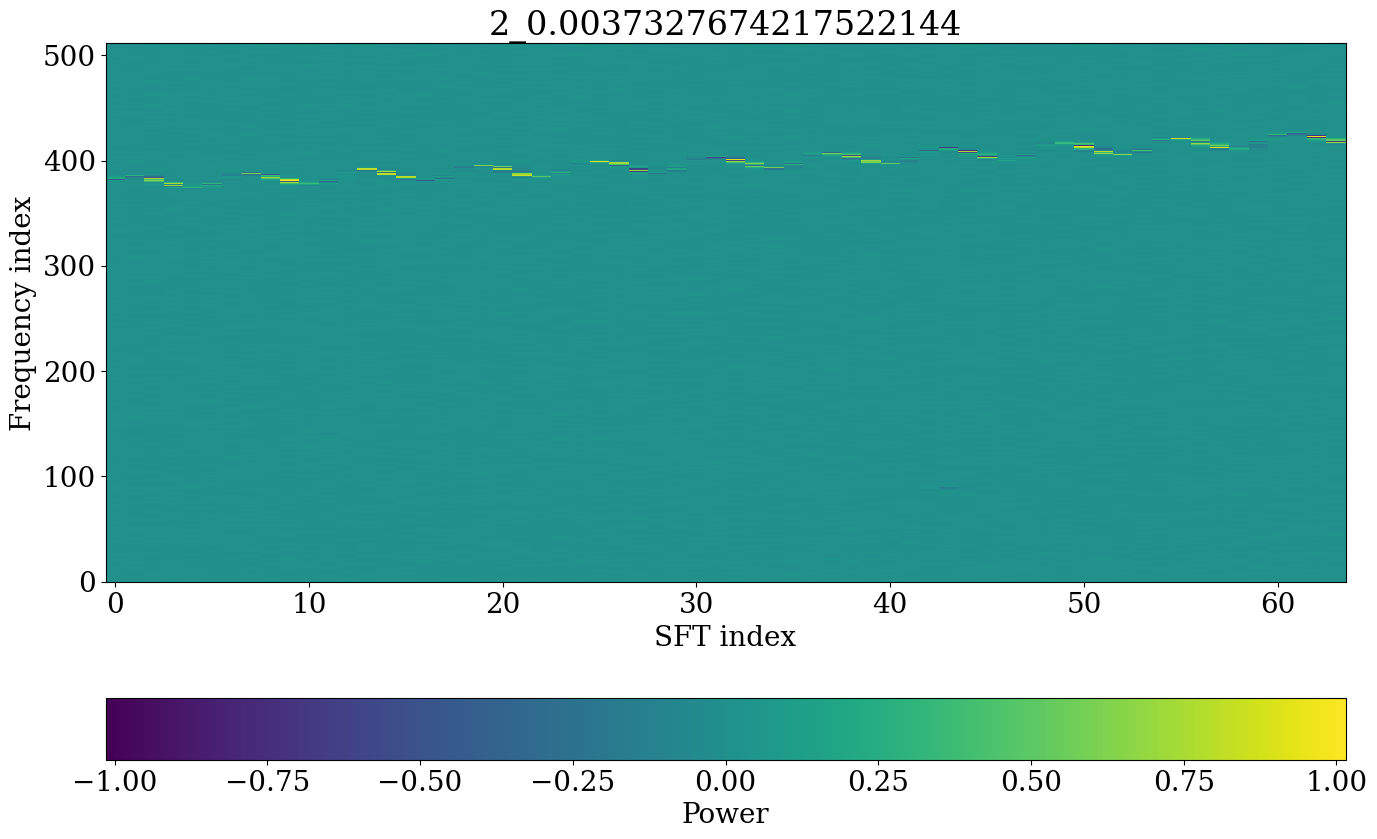

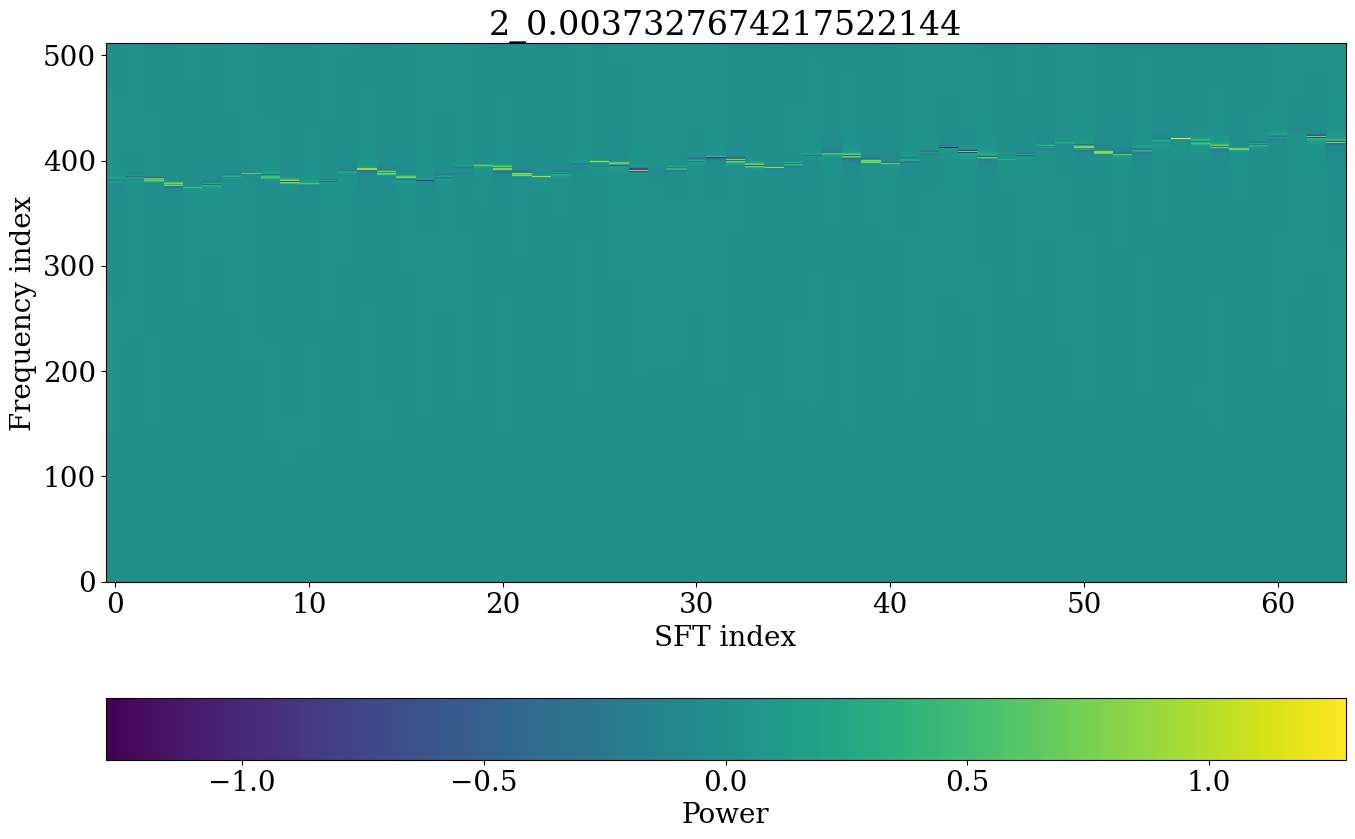

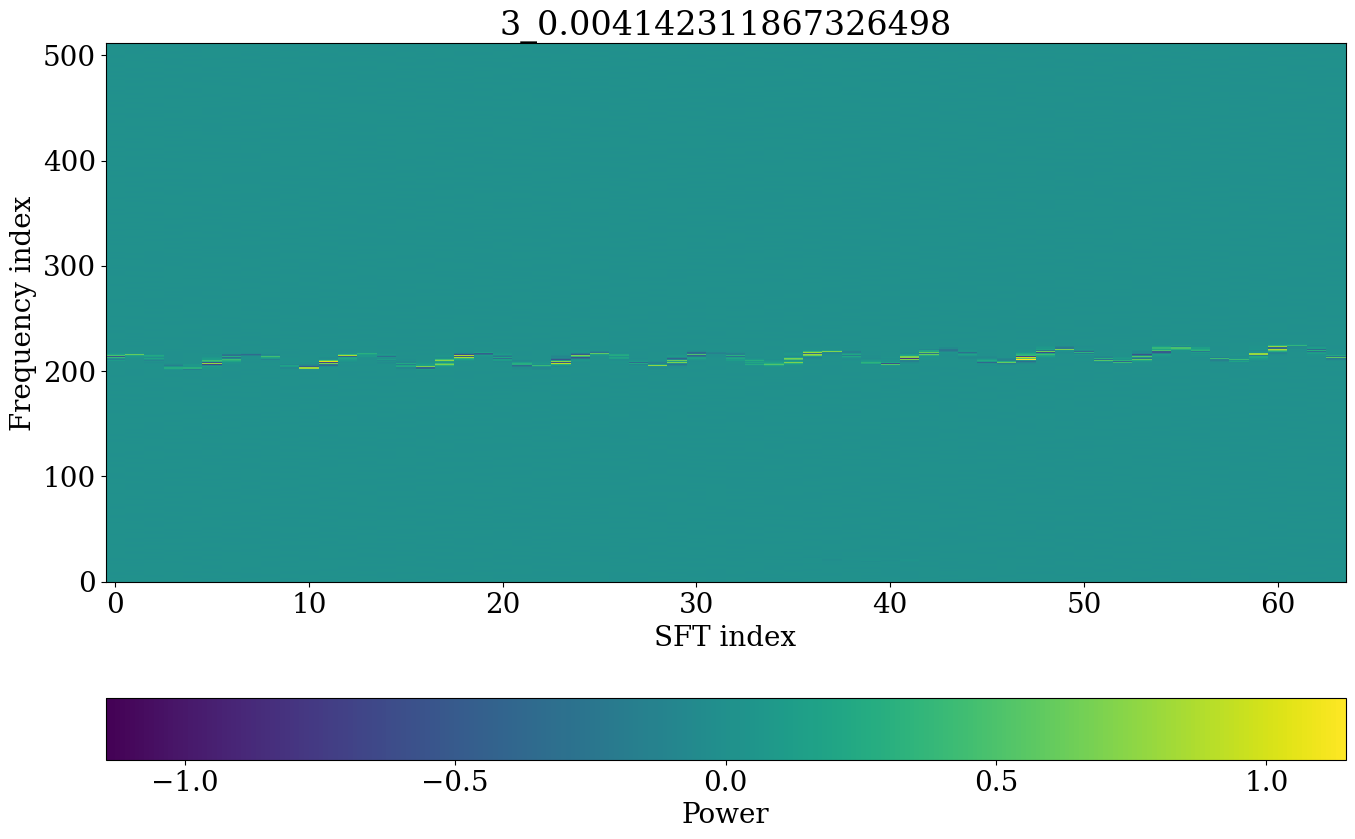

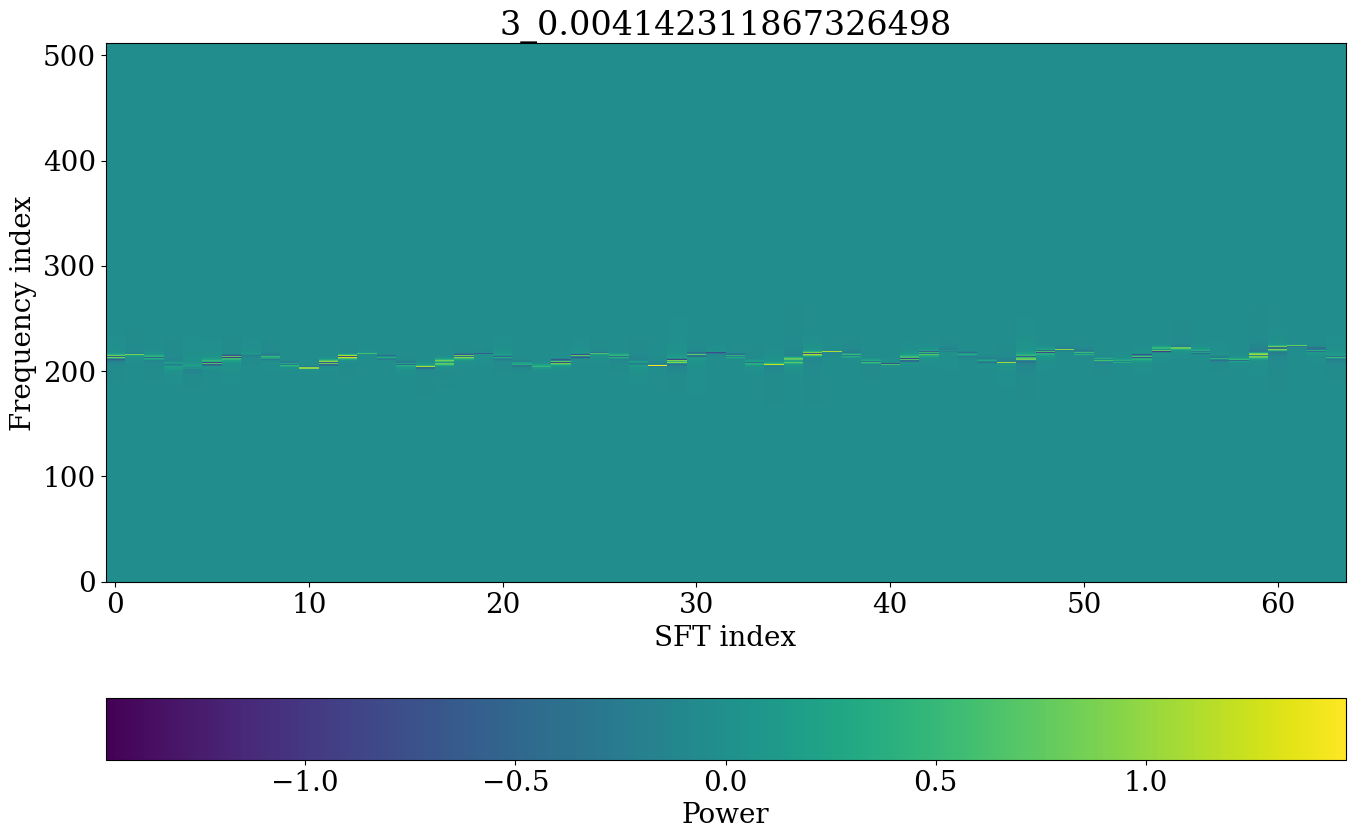

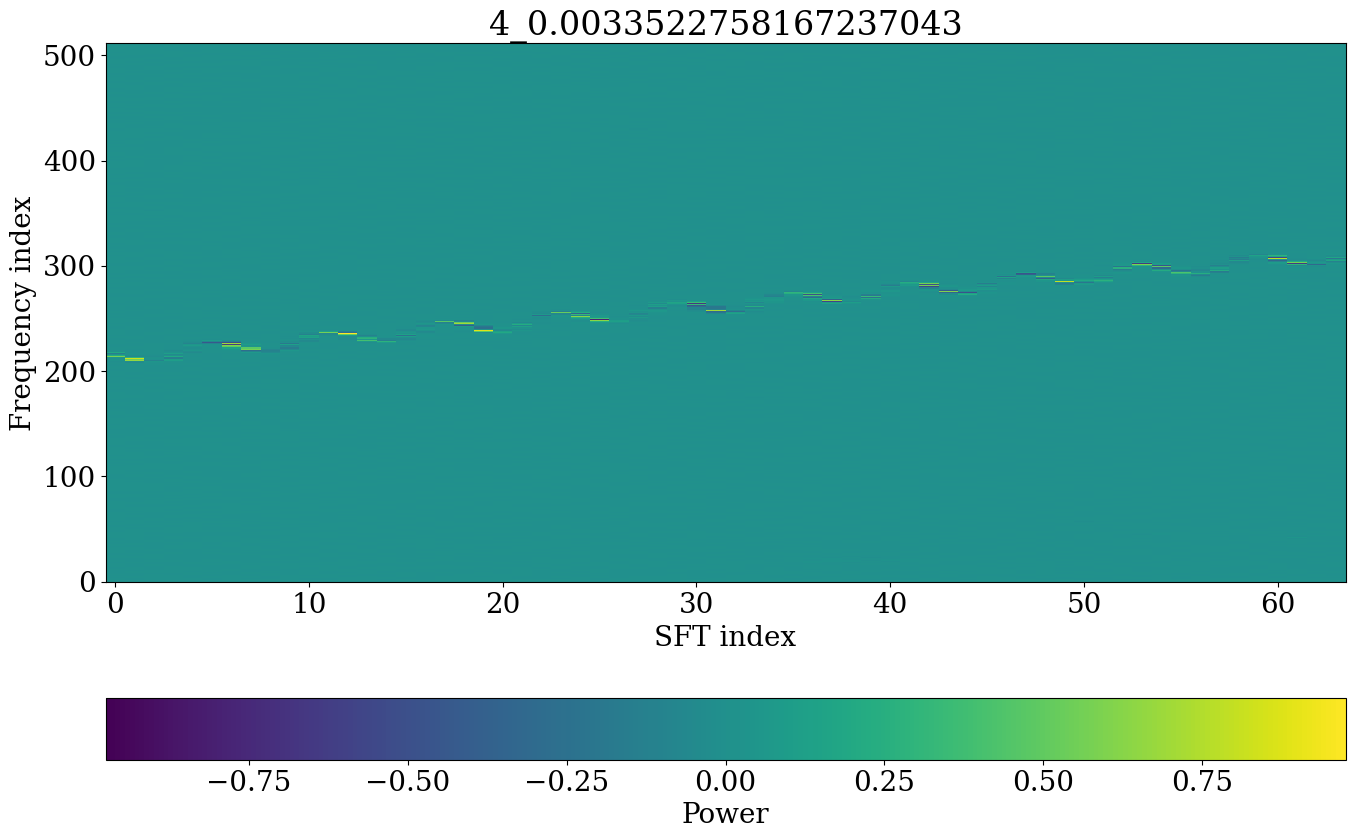

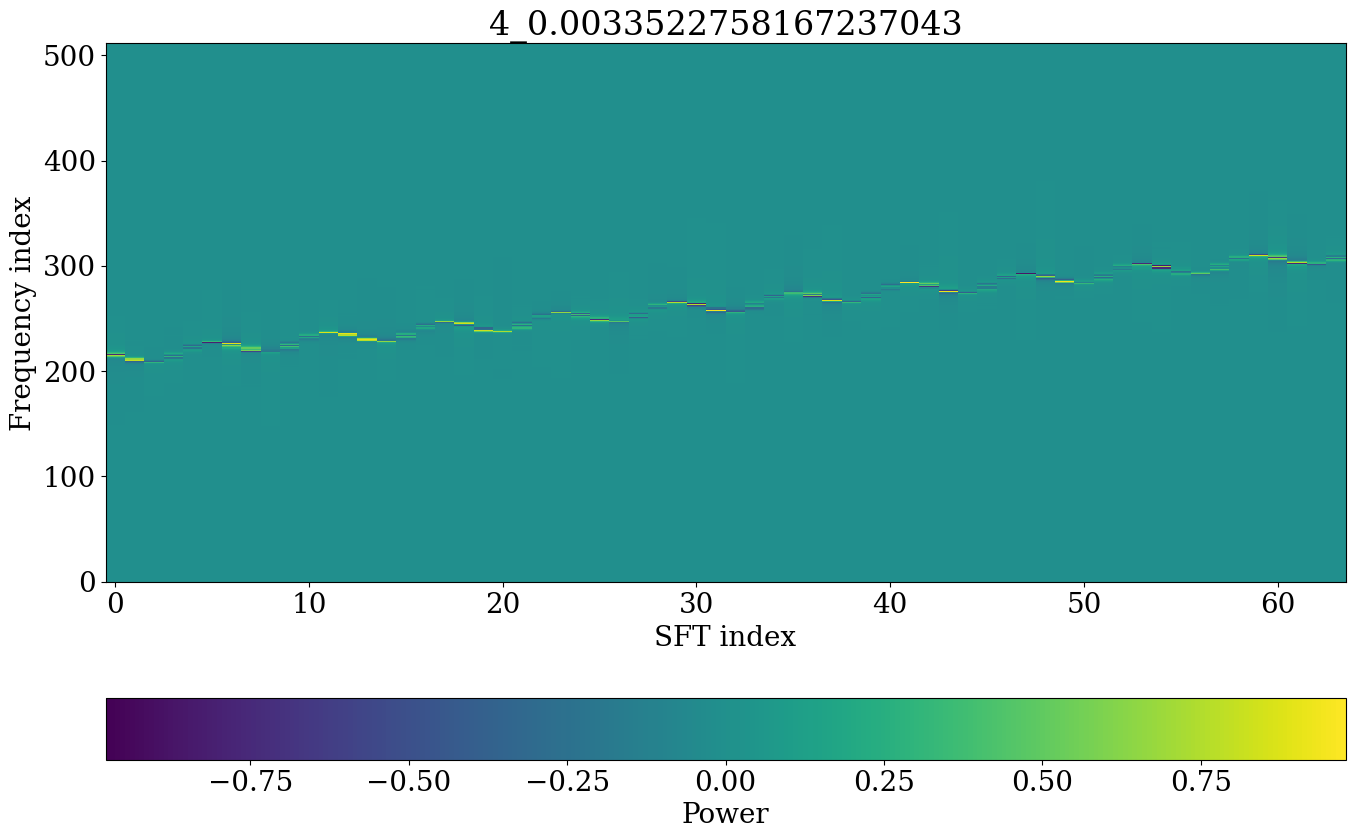

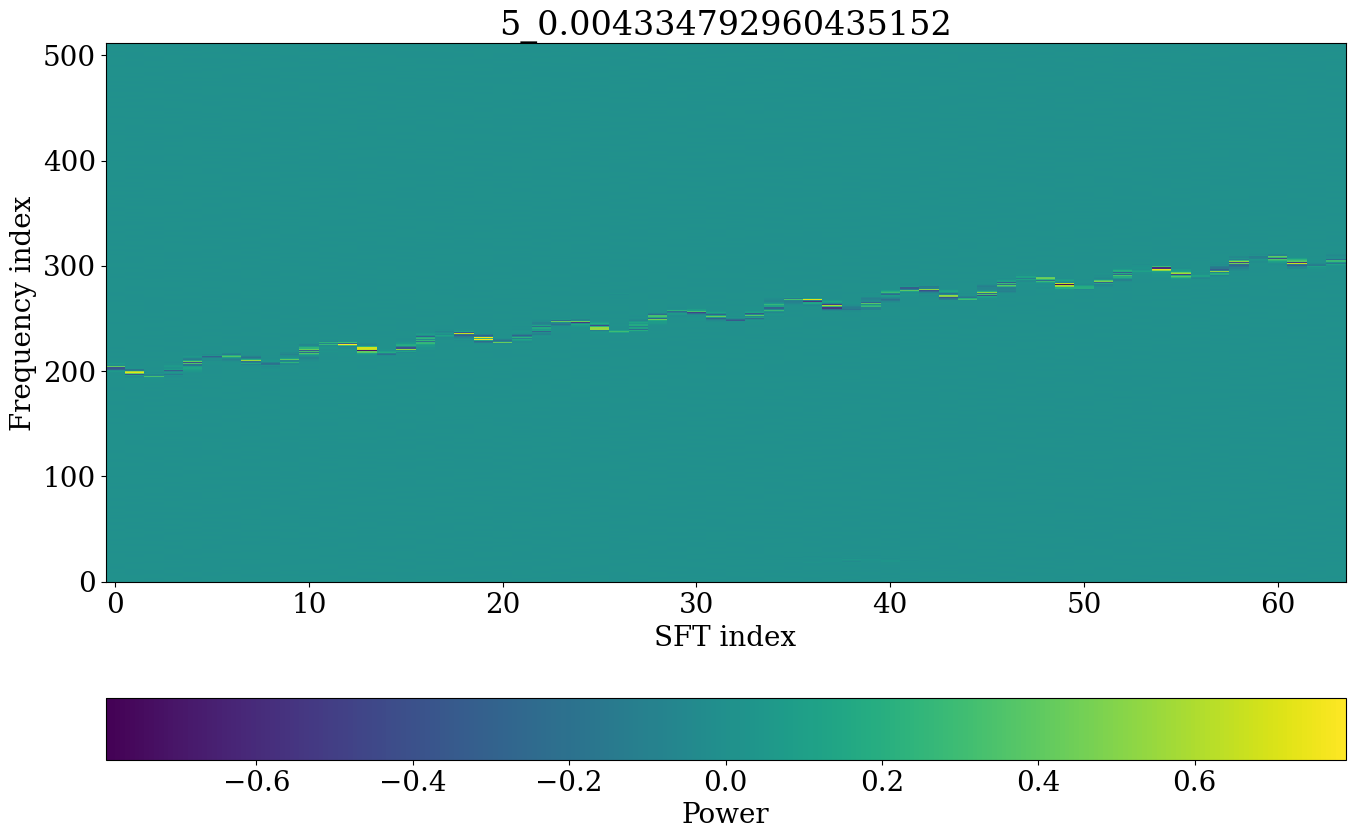

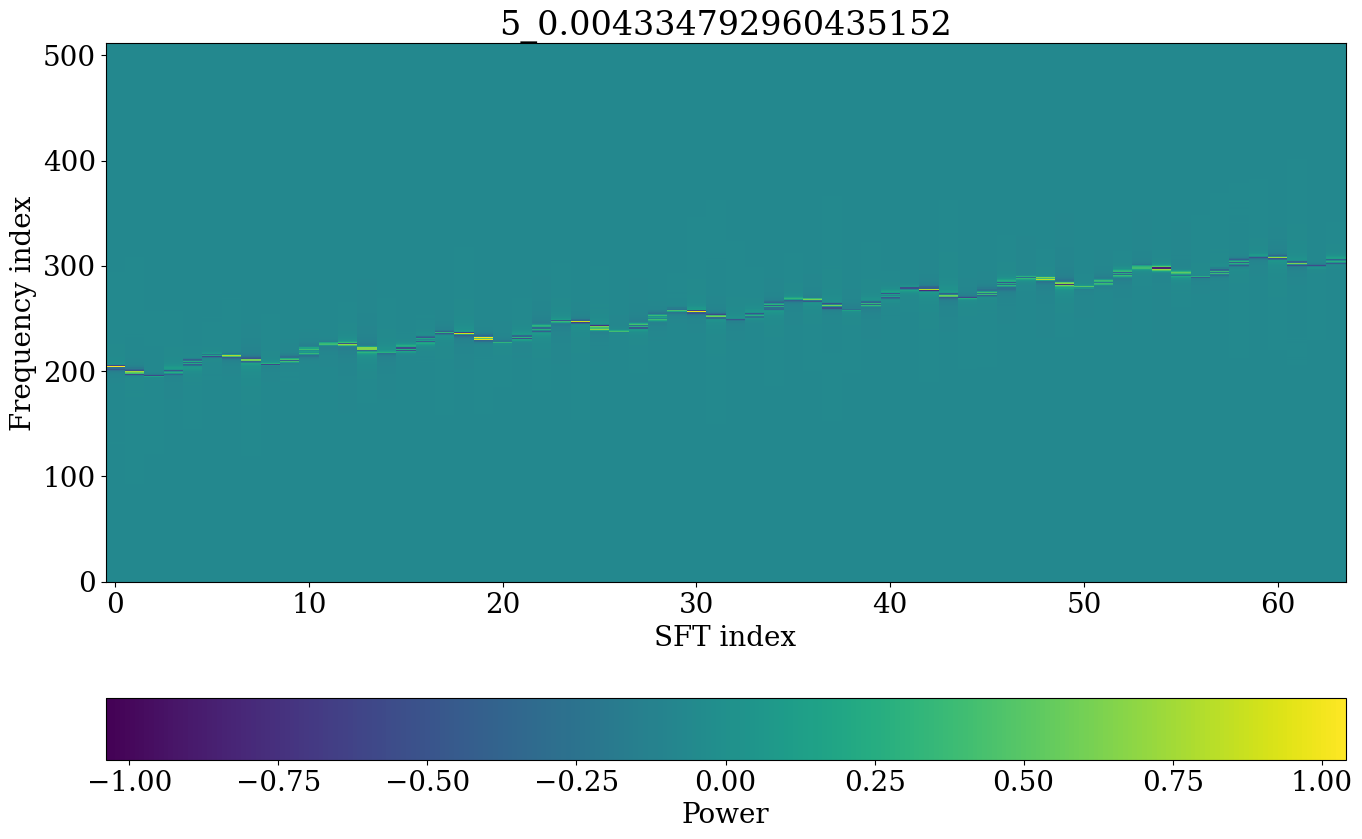

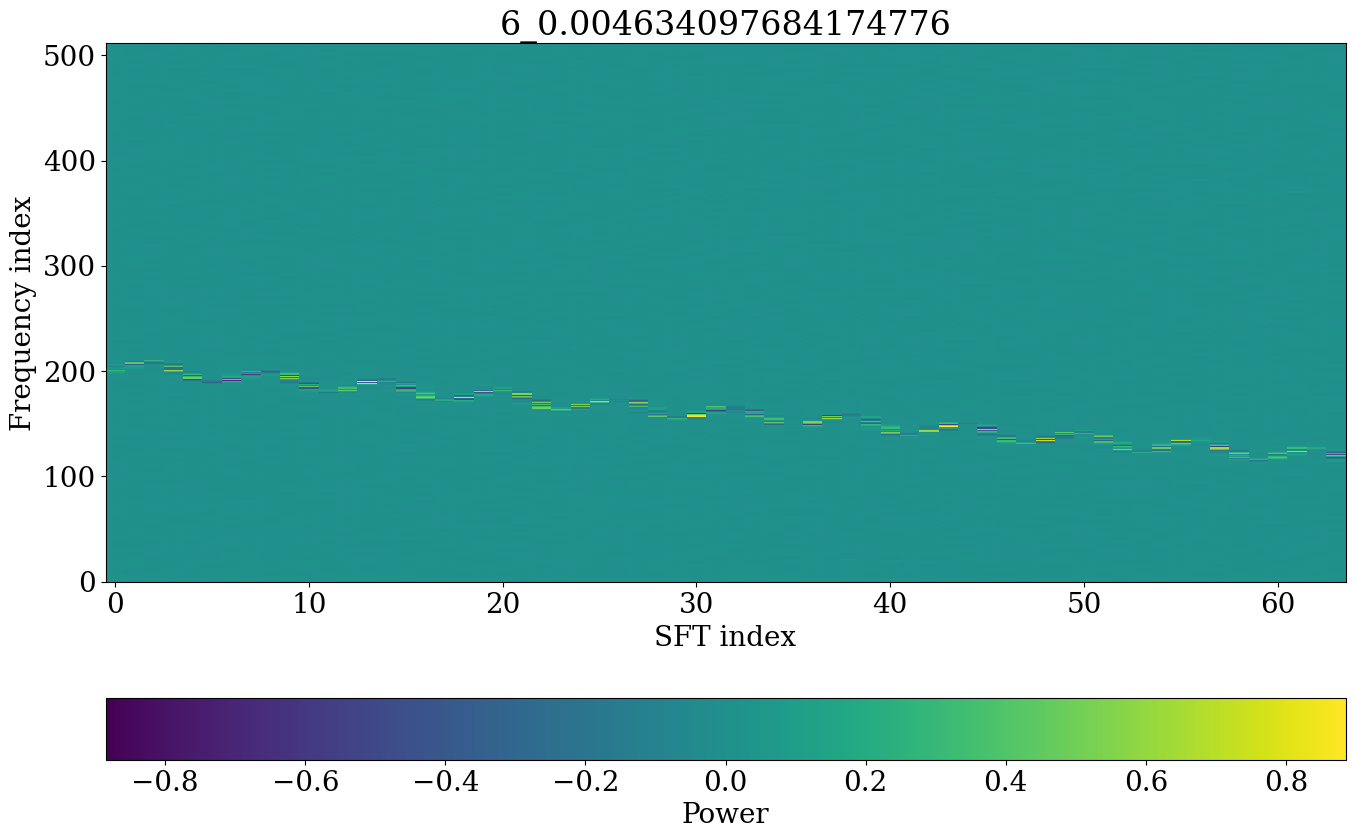

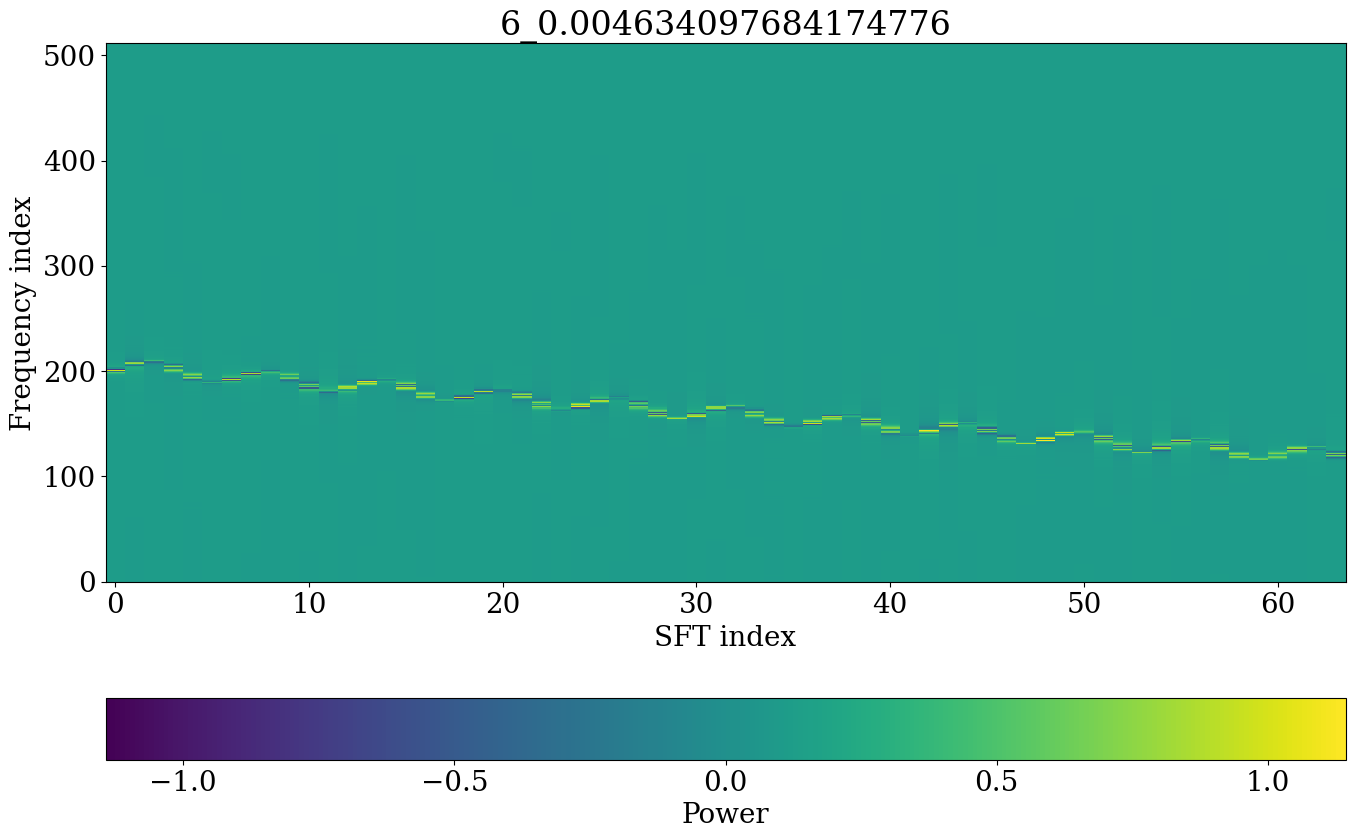

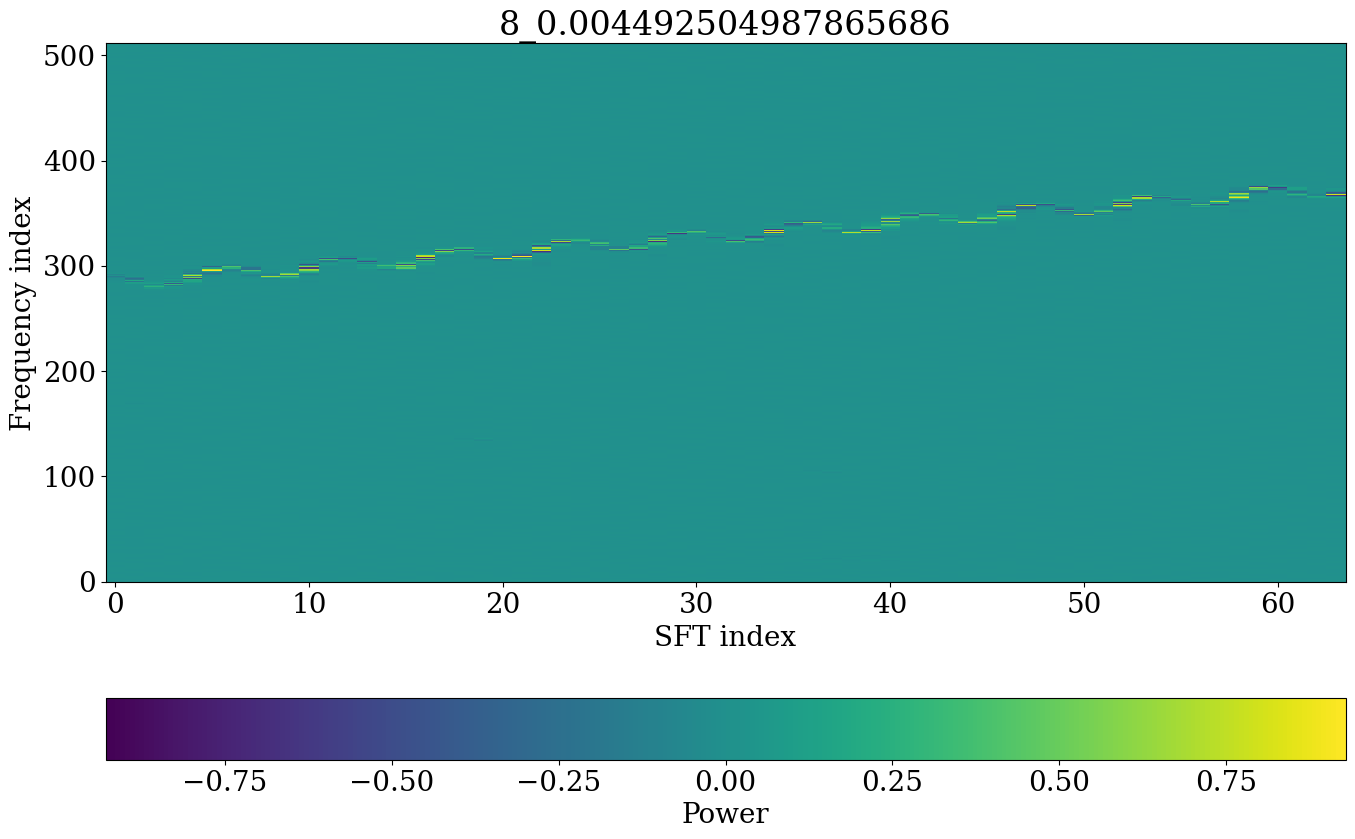

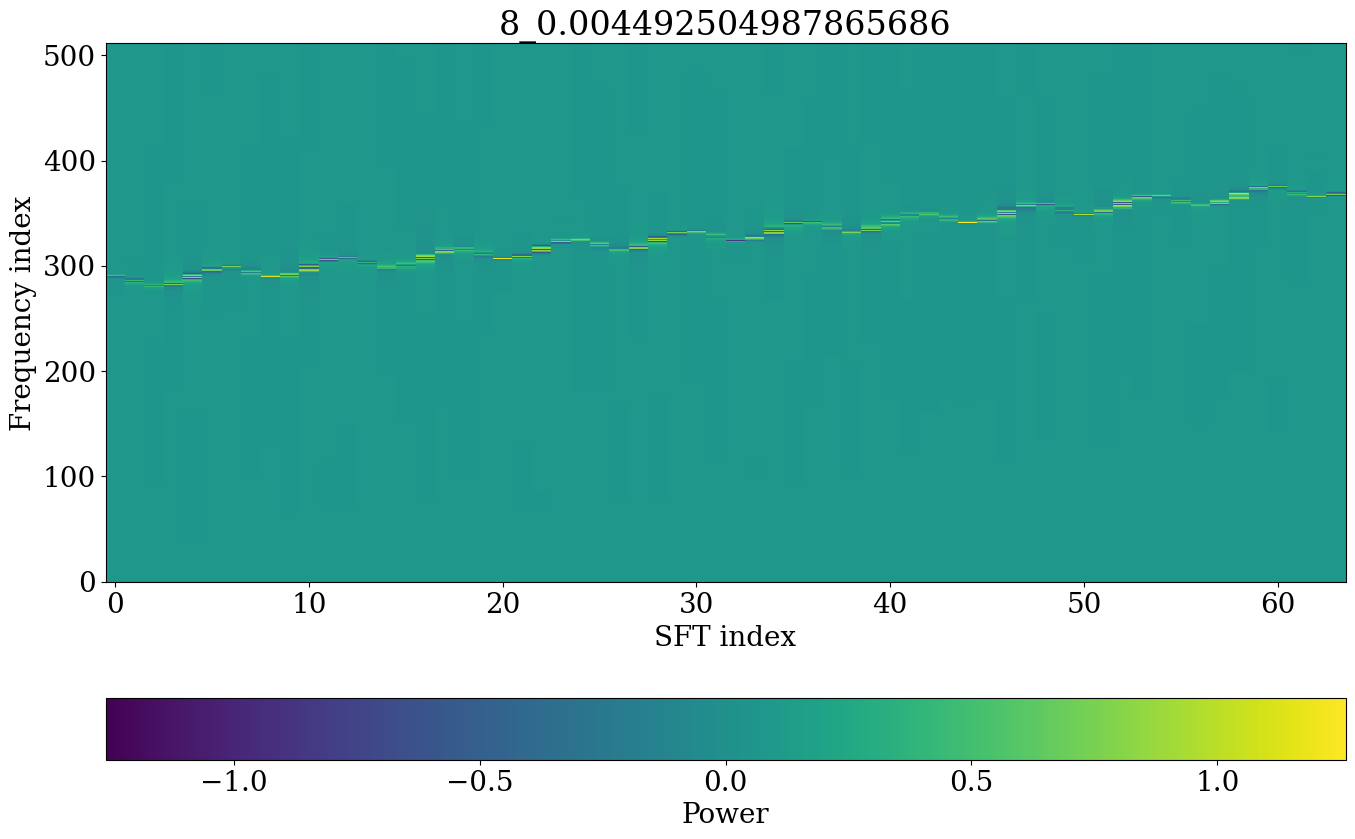

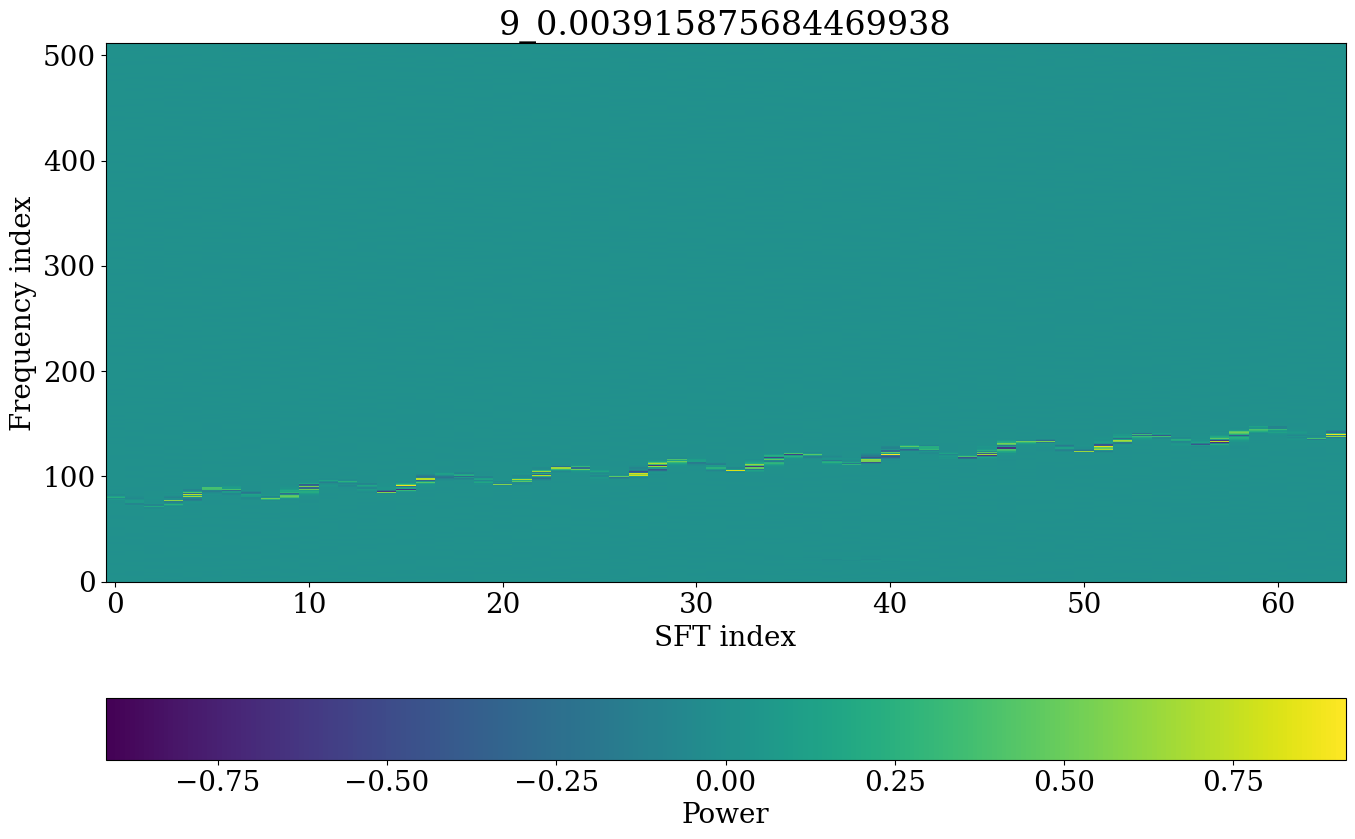

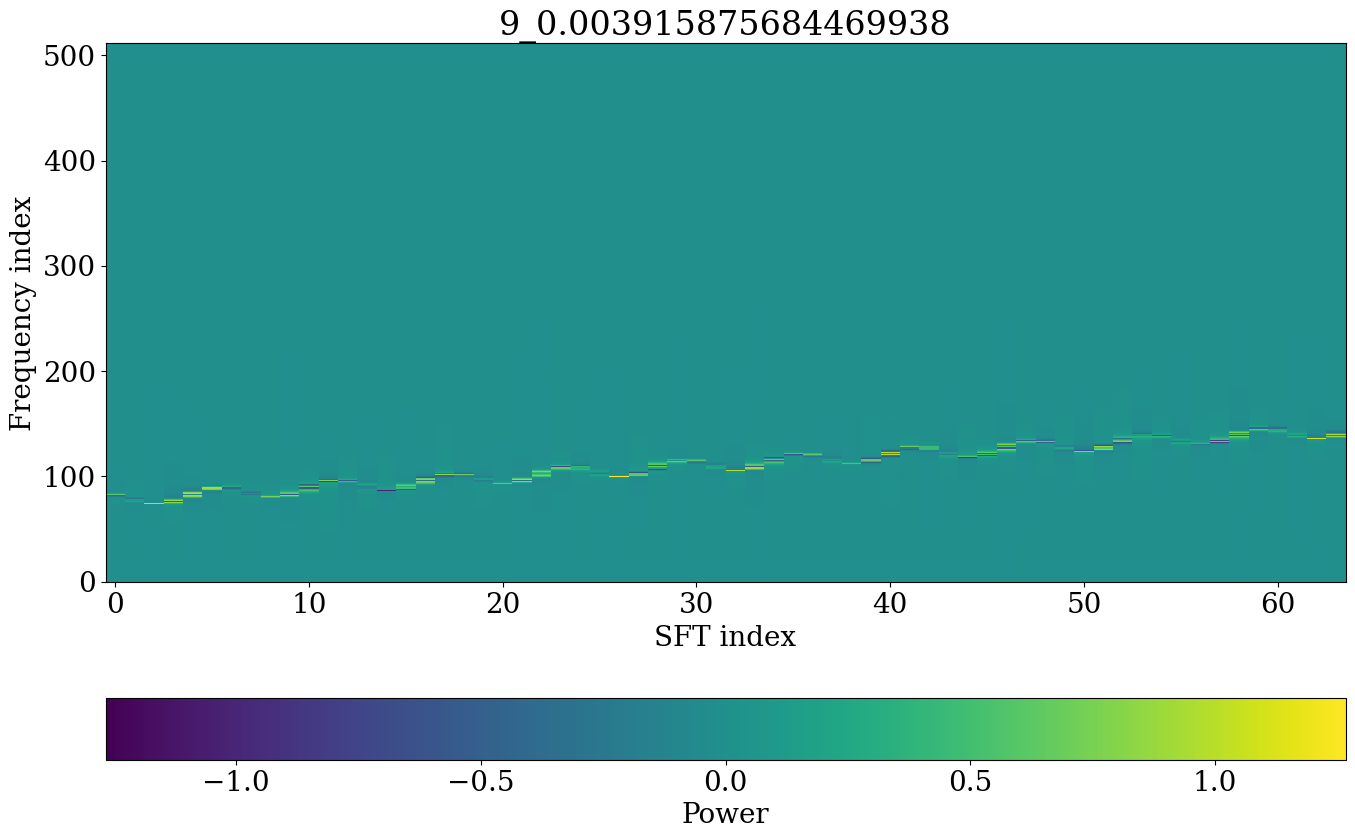

In [11]:
timestamps = np.arange(0, size[1])
frequency = np.arange(0, size[0])

indices = np.where(labels == 20)[0]
stat = results_dict[20]
for i, idx in enumerate(indices[:10]):
    title = '{}_{}'.format(i, stat[i])
    #fig, ax = plot_spectrograms(title, timestamps, frequency, inputs[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_input_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_input_{}.png'.format(version))
    #fig, ax = plot_spectrograms(title, timestamps, frequency, predictions[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_pred_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_pred_{}.png'.format(version))
    if (stat[i] - x_pfa)>0:
        fig, ax = plot_spectrograms(title, timestamps, frequency, predictions[idx].transpose(1, 2, 0))
        #fig, ax = plot_spectrograms(title, timestamps, frequency, inputs[idx].transpose(1, 2, 0))
        fig, ax = plot_spectrograms(title, timestamps, frequency, ground_truth[idx].transpose(1, 2, 0))
    #fig.savefig('./plots/D14_target_{}.pdf'.format(version))
    #fig.savefig('./plots/D14_target_{}.png'.format(version))

In [12]:
depth = []
pdet = []
mask_dict = {}
for key in results_dict.keys():
    #if key != np.inf:
    mask = np.zeros(results_dict[key].size, dtype=bool)
    data = results_dict[key]
        #print((data>x_pfa[j]).shape)
    mask = (data>x_pfa)
    mask_dict[key] = mask
    if key != np.inf:
        depth.append( int(key))
        pdet.append( mask.sum()/data.size )

depth = np.array(depth)
pdet = np.array(pdet)

In [13]:
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy import stats
from PIL import Image
# Matplotlib configuration for consistent, readable plots
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 20
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings

class fitSigmoid:    
    def __init__(self, nInj=100):
        self.nInj = nInj         # number of injections per point

    def sigmoid(self, x, k, x0):
        return 1./(1.+np.exp(-k*(x-x0))) 

    def inv_sigmoid(self, y, k, x0):
        return -np.log(1./y-1.) /k +x0        

    def transfromX(self, d):
        return d/self.dmax *2 - 1 
    
    def transfromD(self, x):
        return (x+1)/2*self.dmax 
    
    def binomialError(self, y, n):
        err =  np.sqrt(y*(1.-y)/n)
        err[err==0] = 1./n
        return err

    def d_fromPercentile(self, per=0.9):    
        x = self.inv_sigmoid(per, *self.popt)
        d = self.transfromD(x)
        a, b = self.popt.T
        dxda =  -1.0/a**2 * np.log(per/(1-per))
        dxdb = 1.0
        dx = np.sqrt(self.pcov[0,0]*dxda**2 + self.pcov[1,1]*dxdb**2 + 2*self.pcov[0,1]*dxda*dxdb)

        return d, dx

    def fit(self, d, p):        
        self.dmax = np.max(d)
        err = self.binomialError(p, self.nInj)
        x = self.transfromX(d)
        self.popt, self.pcov = curve_fit(self.sigmoid, x, p, p0=[0,100], sigma=err) 
        return 0
    
    def plot(self, cosi, d_list, p, savePath='./sigmoid.pdf'):
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
        
        
        d_low, _ = self.d_fromPercentile(per=0.001)
        d_high, _ = self.d_fromPercentile(per=0.999)
        d_low, d_high = min(d_list[0], d_low), max(d_list[-1],d_high)
        d_arr = np.linspace(d_low, d_high, 100)
        x_arr = self.transfromX(d_arr)
        
        p_inter = self.sigmoid(x_arr, *self.popt)
        ax.plot(d_arr, p_inter, color=colors[0], label='fit')
                 
        ax.scatter(d_list, p, color='black')
        err = self.binomialError(p, self.nInj)
        ax.errorbar(d_list, p, yerr=err, fmt='', color='k', ls='none')
               
        d90, dx = self.d_fromPercentile(per=0.9)
        dx = dx /2 * self.dmax
        p90 = 0.9
        x_highlighting = [0, d90, d90]
        y_highlighting = [p90, p90, -1]

        if cosi is None:
            plt.plot(x_highlighting, y_highlighting, color='r', label=r'$\mathcal{D}^{90\%}=$'+'{:.1f}'.format(d90)+r'$\pm$'+'{:.1f}'.format(np.abs(dx)))
        else:
            plt.plot(x_highlighting, y_highlighting, color='r', label=r'$\mathcal{D}^{90\%}=$'+'{:.1f}'.format(d90)+r'$\pm$'+'{:.1f}'.format(np.abs(dx))+r'$\; (\cos \iota =$'+str(cosi)+')')

        ax.legend()
        ax.set_ylim(-0.05, 1.05)
        #ax.set_xlim(0.9*min(min(d_list), d_arr[0]), 1.05*min(max(d_list), max(d_arr)))       
        plt.xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
        ax.set_ylabel(r'$p_{\mathrm{det}}$')
        #plt.legend(loc=3)
        ax.set_xlim(0.9*min(min(d_list), d_arr[0]), 1.0*40)       
        plt.grid(alpha=1, which='major')
        plt.grid(alpha=0.3, which='minor')
        plt.minorticks_on() 
        #fig.savefig(savePath)
        return fig
    

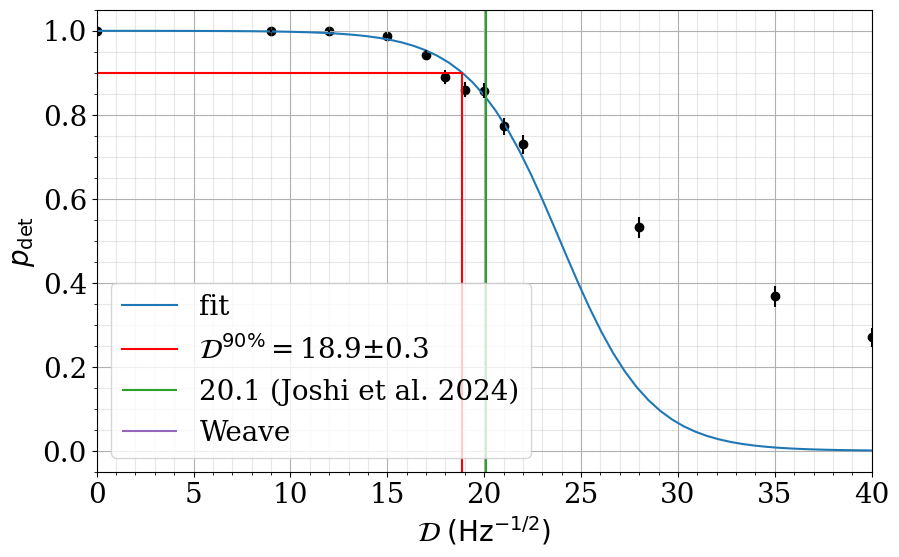

In [17]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
fit = fitSigmoid(400)
fit.fit(depth[:-5], pdet[:-5])
fig = fit.plot(None, depth, pdet)
depth_joshi = 20.1
plt.vlines(x=depth_joshi, ymin=-1,ymax=2, color=colors[2], label='{} (Joshi et al. 2024)'.format(depth_joshi))
depth_weave = 41.5
plt.vlines(x=depth_weave, ymin=-1,ymax=2, color=colors[4], label='Weave')

plt.legend()
#plt.savefig('./plots/pdet_{}_3+1day_gaps.pdf'.format(version))
#plt.savefig('./plots/pdet_{}.pdf'.format(version))
#plt.savefig('./plots/pdet_{}.png'.format(version))
plt.show()

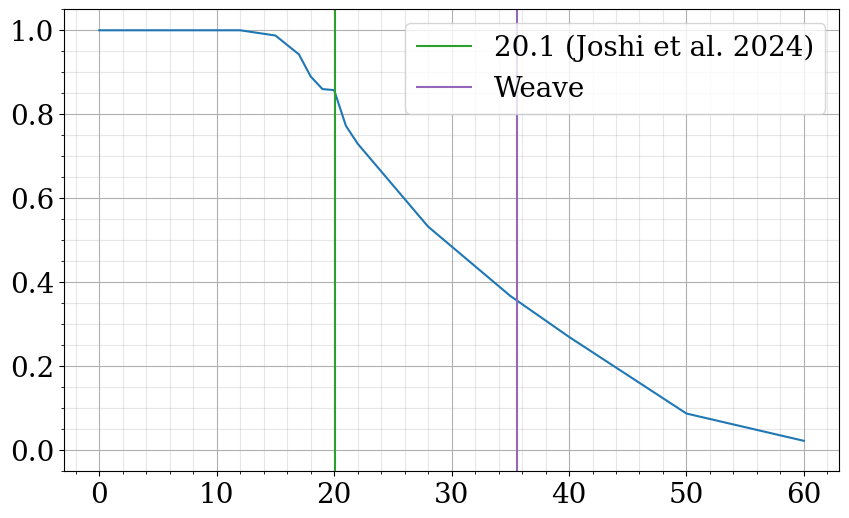

In [26]:
plt.subplots(figsize=(10, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
plt.plot(depth, pdet)
depth_joshi = 20.1
plt.vlines(x=depth_joshi, ymin=-1,ymax=2, color=colors[2], label='{} (Joshi et al. 2024)'.format(depth_joshi))
depth_weave = 35.6
plt.vlines(x=depth_weave, ymin=-1,ymax=2, color=colors[4], label='Weave')
plt.grid(alpha=1, which='major')
plt.grid(alpha=0.3, which='minor')
plt.minorticks_on() 
plt.ylim(-0.05, 1.05)
plt.legend()
#plt.savefig('./plots/pdet_{}_3+1day_gaps.pdf'.format(version))
#plt.savefig('./plots/pdet_{}.pdf'.format(version))
#plt.savefig('./plots/pdet_{}.png'.format(version))
plt.show()

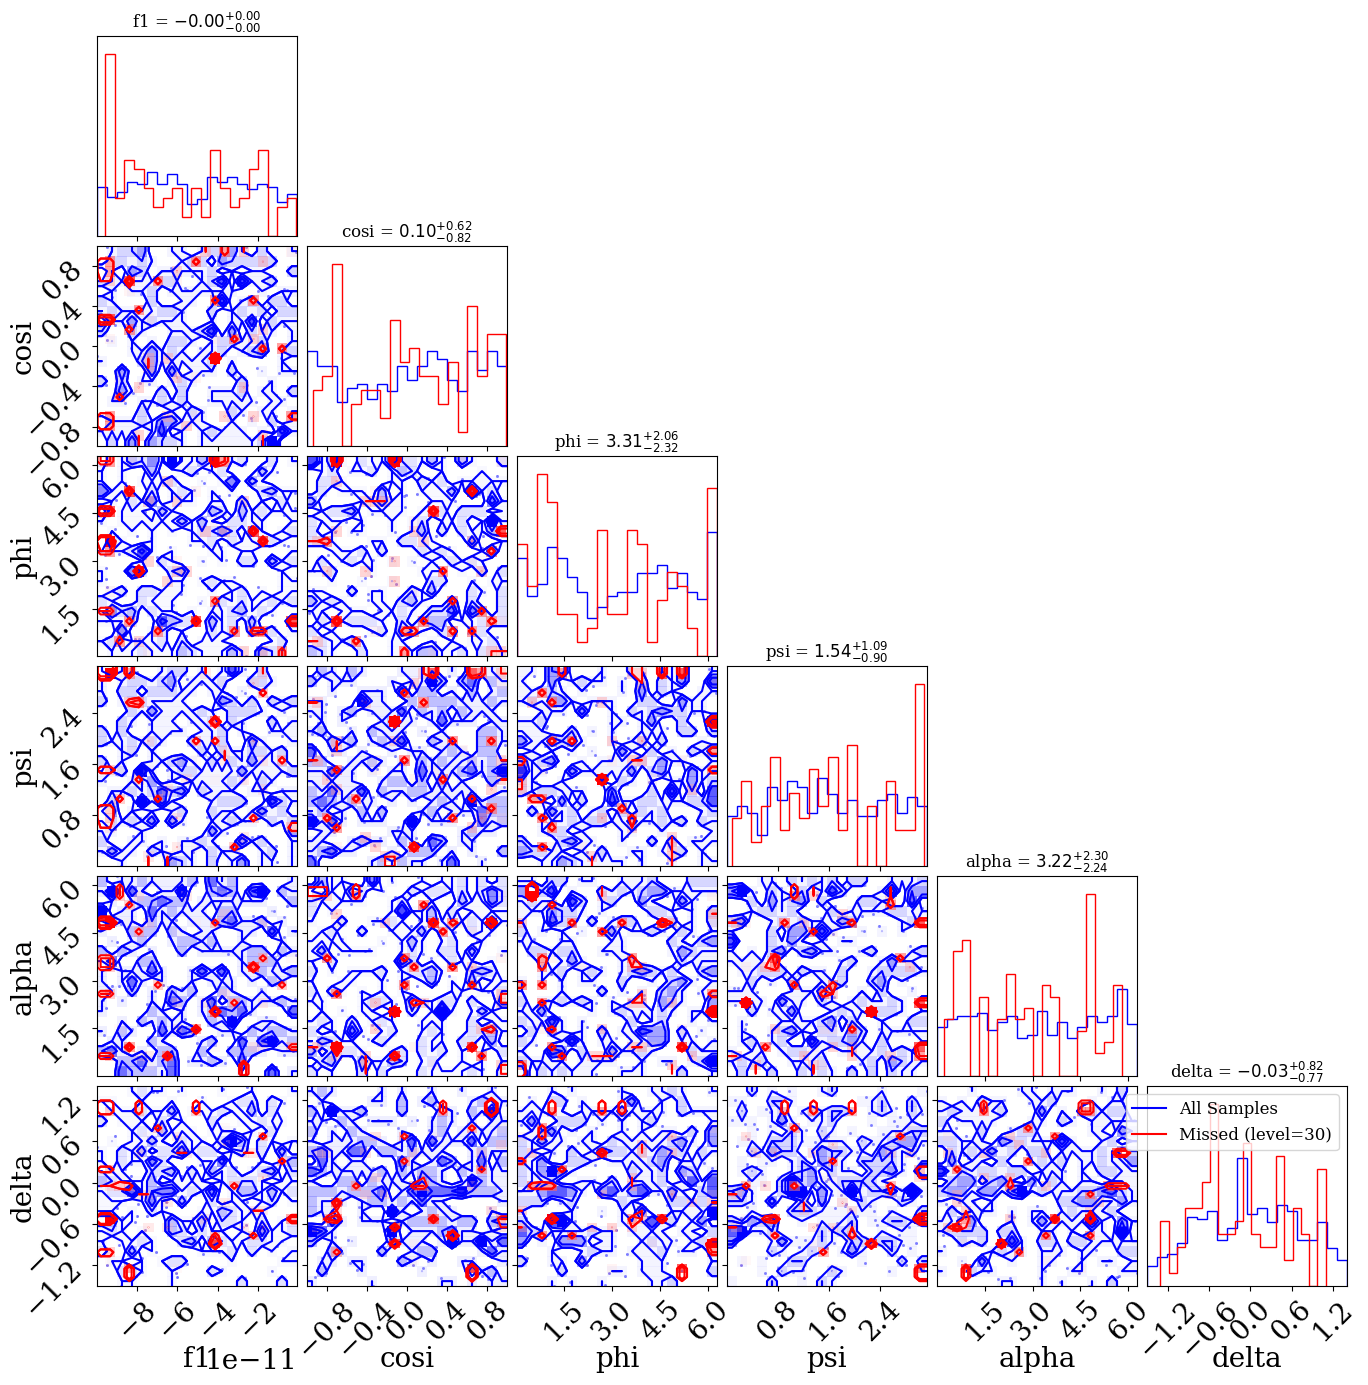

In [38]:
from corner import corner 

params = data['params'][:, :-1]  # All parameters except the last one
param_names = ['f1', 'cosi', 'phi', 'psi', 'alpha', 'delta']
# Identify indices for level=30 and missed signals
level_30_indices = np.where(labels == 22)[0]  # Indices where label is 30
missed_indices = level_30_indices[~mask_dict[np.float(22)]] -3600 # Missed signals (mask_dict[30] == False)

# Parameters for all samples and missed signals
all_params = params  # Shape: (n_samples, n_params)
missed_params = params[missed_indices]  # Parameters of missed signals at level=30

# Create the corner plot
figure = corner(
    all_params,
    labels=param_names,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    color='blue',
    alpha=0.5,
    hist_kwargs={'density': True}
)

# Overlay missed signals at level=30
corner(
    missed_params,
    fig=figure,
    color='red',
    alpha=0.8,
    labels=param_names,
    hist_kwargs={'density': True, 'label': 'Missed (level=30)'}
)

# Add legend to distinguish missed signals
plt.legend(handles=[
    plt.Line2D([0], [0], color='blue', label='All Samples'),
    plt.Line2D([0], [0], color='red', label='Missed (level=30)')
], fontsize=12, loc='upper right')

plt.show()

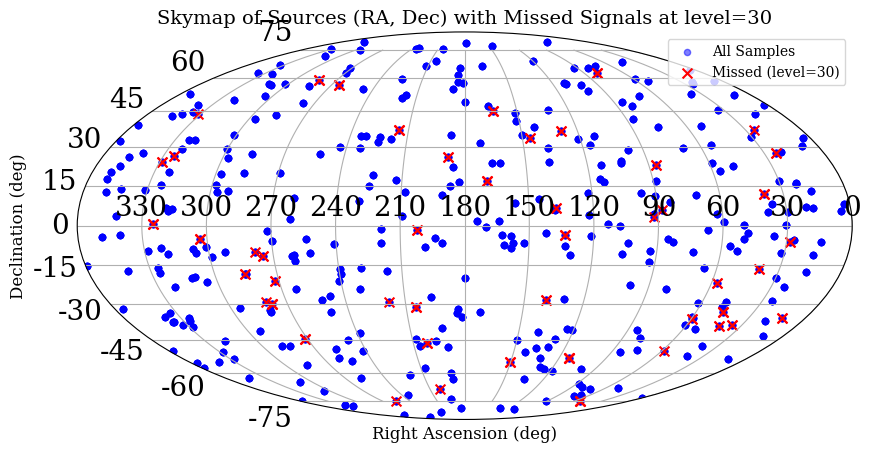

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# Extract RA (alpha) and Dec (delta) from data['params'][:, :-1]
# Assuming alpha is column 0 (in radians) and delta is column 1 (in degrees)
alpha_rad = data['params'][:, -3]  # RA in radians (0 to 2π)
delta = data['params'][:, -2]  # Dec in degrees (-90 to 90)

# Convert alpha from radians to degrees (0 to 360)
alpha_deg = np.degrees(alpha_rad)

# Identify indices for level=30 and missed signals
level_30_indices = np.where(labels == 22)[0]  # Indices where label is 30
missed_indices = level_30_indices[~mask_dict[22]] -3600  # Missed signals (mask_dict[30] == False)

# Convert RA to radians for Mollweide projection (and reverse for astronomical convention)
ra_plot_rad = np.radians(180 - alpha_deg)  # RA in degrees (0 to 360) -> radians, mirrored
dec_plot_rad = delta  # Dec in degrees -> radians

# RA and Dec for missed signals
ra_missed = ra_plot_rad[missed_indices]
dec_missed = dec_plot_rad[missed_indices]

# Create the skymap
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Plot all samples
ax.scatter(ra_plot_rad, dec_plot_rad, c='blue', s=20, alpha=0.5, label='All Samples')

# Plot missed signals at level=30
ax.scatter(ra_missed, dec_missed, c='red', s=50, marker='x', label='Missed (level=30)')

# Customize the plot
ax.set_xlabel('Right Ascension (deg)', fontsize=12)
ax.set_ylabel('Declination (deg)', fontsize=12)
ax.grid(True)

# Set RA ticks (in degrees, reversed for astronomical convention)
ra_ticks_deg = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210, 180])
ra_ticks_rad = np.radians(180 - ra_ticks_deg)
ax.set_xticks(ra_ticks_rad)
ax.set_xticklabels([f'{t:.0f}' for t in ra_ticks_deg])

# Set Dec ticks
dec_ticks_deg = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75])
dec_ticks_rad = np.radians(dec_ticks_deg)
ax.set_yticks(dec_ticks_rad)
ax.set_yticklabels([f'{t:.0f}' for t in dec_ticks_deg])

# Add legend
plt.legend(loc='upper right', fontsize=10)

# Title
plt.title('Skymap of Sources (RA, Dec) with Missed Signals at level=30', fontsize=14)

plt.show()